##動機和分析目的

台積電是台灣半導體產業的代表企業，近年因股價波動、赴美投資、國際擴廠與地緣政治等議題，經常成為網路討論焦點。因此本研究希望透過 PTT 文章分析，了解大眾在討論台積電時關注的核心議題，並觀察社群對企業形象、產業發展、投資信心與科技業職場的看法。  

本分析目的包括：
1. 整理台積電相關討論的熱門詞彙與聲量變化
2. 分析正負向情緒趨勢
3. 透過分類模型與語意相似度，了解不同文章類型與主題之間的關聯
4. 辨識主要討論主題

##資料集描述

資料來自 PTT 的 Stock 與 Tech_Job 兩個看板，蒐集期間為 2024/05/19 至 2026/05/19，篩選條件為文章標題或內文中包含「台積電」的文章。

##10 分鐘內的YT報告影片連結
https://youtu.be/1dBTq9YEFOk

In [ ]:
import pandas as pd
import jieba
import jieba.posseg as pseg
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import requests
from ckiptagger import data_utils, construct_dictionary, WS, POS, NER
import random

In [ ]:
FONT_PATH = "font.ttf"  # 如果文字雲中文亂碼，請放入中文字型檔，或改成自己的字型路徑

# 圖表中文設定：不同系統字型名稱可能不同，可自行調整
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Microsoft JhengHei', 'PingFang TC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 讀取檔案
df = pd.read_csv('./ptt_tech_job_20240519_20260519_full.csv')
clear_df = df.copy() # 複製一份資料進行清洗，保留原始資料以供對照

# 定義並去除分析時用不到的系統與詮釋資料欄位
drop_cols = ['system_id', 'artCatagory', 'artUrl', 'artPoster', 'insertedDate','artComment','dataSource']
clear_df.drop(drop_cols, axis=1, inplace=True, errors='ignore')

# 移除內文 (artContent) 為空值的資料行
clear_df.dropna(subset=['artContent'], inplace=True)
clear_df.head()

,artTitle,artDate,artContent
0,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-16 14:12:24,我覺得台灣要拋棄一個思想\n\n就是儒家邪教的「萬般皆下品 惟有讀書高」\n\n很多賺錢的行...
1,[新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-15 06:38:27,作者: peterlin495 (專業果粉O'_'O) 看板: Gossiping\n標題:...
2,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2026-05-15 05:44:42,搭版問:\n\n今年初去了一批外包商的建廠人員\n\n招八晚五周休二日月入稅後5000鎂的\...
3,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2026-05-13 10:33:30,※ 引述《kudsaimoe (62632)》之銘言：\n: 吃原文 其實沒講到點上 就算全...
4,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2026-05-13 05:48:50,吃原文 其實沒講到點上 就算全部吃外食 都叫uber能存的錢肯定還是比台灣多 外食自己隨\n...


清理網址、特殊符號、PTT 常見雜訊。將文章切割成短句。

In [ ]:
def clean_ptt_text(text):
    """清理 PTT 文章中常見的雜訊 (網址、簽名檔、引言等)"""
    text = str(text)

    # 1. 移除網址 (你原本的寫法很好)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 2. 移除 PTT 常見結尾資訊 (發信站、文章網址、編輯記錄)
    # 只要是 "※" 開頭且後面跟著這三個關鍵字，整行連同後面的內容都砍掉
    text = re.sub(r'※ (發信站|文章網址|編輯).*', '', text)

    # 3. 移除回文引述
    text = re.sub(r'引述《.*》之銘言', '', text)

    # 4. 移除標題標籤，例如 [新聞]、[爆卦]
    text = re.sub(r'\[.*?\]', '', text)

    # 5. 移除回文時常見的引言符號 (PTT 每行引言常以 : 或 > 開頭)
    text = re.sub(r'^[>:]\s*', '', text, flags=re.MULTILINE)

    # 6. 移除純英文和數字 (依你原本的邏輯保留)
    text = re.sub(r'[a-zA-Z0-9]+', '', text)
        # 7. 清除常見的無意義連續符號，例如 --, //, ==, ~~
    text = re.sub(r'[-/=_~]{2,}', '', text)

    # 8. 換行轉句號
    text = re.sub(r'\n+', '。', text)

    return text

# 將清理函式套用到內文欄位
clear_df['sentence'] = clear_df['artContent'].apply(clean_ptt_text)

# 在斷句前，先將目前的 index 存成 'doc' 欄位，這樣斷句後編號才會留著
clear_df['doc'] = clear_df.index
# 斷句：利用標點符號將整篇文章切分成一句一句的短句
clear_df['sentence'] = clear_df['sentence'].str.split(r"[,，。！!？?]+")
# explode 會將串列中的句子拆解成多列，重置索引
sent_df = clear_df.explode('sentence').reset_index(drop=True)
# 濾除只有 1 個字或全空的無效短句
sent_df = sent_df[sent_df["sentence"].str.len() > 1]

print("\n=== 文字清理與斷句完成 ===")
print(f"目前總共切出了 {len(sent_df)} 句短句準備進行斷詞！")

sent_df.head()


=== 文字清理與斷句完成 ===
目前總共切出了 183969 句短句準備進行斷詞！


,artTitle,artDate,artContent,sentence,doc
0,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-16 14:12:24,我覺得台灣要拋棄一個思想\n\n就是儒家邪教的「萬般皆下品 惟有讀書高」\n\n很多賺錢的行...,我覺得台灣要拋棄一個思想,0
1,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-16 14:12:24,我覺得台灣要拋棄一個思想\n\n就是儒家邪教的「萬般皆下品 惟有讀書高」\n\n很多賺錢的行...,就是儒家邪教的「萬般皆下品 惟有讀書高」,0
2,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-16 14:12:24,我覺得台灣要拋棄一個思想\n\n就是儒家邪教的「萬般皆下品 惟有讀書高」\n\n很多賺錢的行...,很多賺錢的行業 或是知識 並不存在於書本上,0
3,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-16 14:12:24,我覺得台灣要拋棄一個思想\n\n就是儒家邪教的「萬般皆下品 惟有讀書高」\n\n很多賺錢的行...,以現今知識爆炸的年代,0
4,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-16 14:12:24,我覺得台灣要拋棄一個思想\n\n就是儒家邪教的「萬般皆下品 惟有讀書高」\n\n很多賺錢的行...,有些書 甚至是精神毒藥,0


處理停用字、進行斷詞

In [ ]:
# 設定繁體中文字典
jieba.set_dictionary('./dict/dict.txt')

# 讀取停用字清單
with open('./dict/stopwords.txt', encoding="utf-8") as f:
    stopWords = [line.strip() for line in f.readlines()]

# 定義斷詞邏輯：過濾停用字與長度小於 2 的詞
def getToken(row):
    seg_list = jieba.lcut(row)
    return [w for w in seg_list if w not in stopWords and len(w.strip()) > 1]

# 執行斷詞並將結果展開成長表格 (word_df)
word_df = sent_df.assign(word = sent_df['sentence'].apply(getToken)).explode('word')
word_df = word_df.dropna(subset=['word'])

# 檢查產出的總詞數與前幾筆資料
print(f"目前總詞數：{len(word_df)}")
word_df.head()

Building prefix dict from d:\media\final\社媒\社媒\dict\dict.txt ...
Loading model from cache C:\Users\程善妮\AppData\Local\Temp\jieba.udcc1bc3a8fd426ccc65b6332c9c13a12.cache
Loading model cost 0.354 seconds.
Prefix dict has been built successfully.


目前總詞數：642827


,artTitle,artDate,artContent,sentence,doc,word
0,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-16 14:12:24,我覺得台灣要拋棄一個思想\n\n就是儒家邪教的「萬般皆下品 惟有讀書高」\n\n很多賺錢的行...,我覺得台灣要拋棄一個思想,0,台灣
0,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-16 14:12:24,我覺得台灣要拋棄一個思想\n\n就是儒家邪教的「萬般皆下品 惟有讀書高」\n\n很多賺錢的行...,我覺得台灣要拋棄一個思想,0,拋棄
0,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-16 14:12:24,我覺得台灣要拋棄一個思想\n\n就是儒家邪教的「萬般皆下品 惟有讀書高」\n\n很多賺錢的行...,我覺得台灣要拋棄一個思想,0,思想
1,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-16 14:12:24,我覺得台灣要拋棄一個思想\n\n就是儒家邪教的「萬般皆下品 惟有讀書高」\n\n很多賺錢的行...,就是儒家邪教的「萬般皆下品 惟有讀書高」,0,儒家
1,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-16 14:12:24,我覺得台灣要拋棄一個思想\n\n就是儒家邪教的「萬般皆下品 惟有讀書高」\n\n很多賺錢的行...,就是儒家邪教的「萬般皆下品 惟有讀書高」,0,邪教


根據清理結果，新增自己的停用字

In [ ]:
# 讀取停用字檔
try:
    with open('./dict/stopwords.txt', 'r', encoding='utf-8') as f:
        stopwords = set([line.strip() for line in f])
except FileNotFoundError:
    stopwords = set()

if 'stopWords' not in locals():
    stopWords = list(stopwords)

# 更新手動停用字名單
stopwords_manual = {"-----", "----", "連結", "嘖嘖", "醒醒", "裝睡", "衛生紙", "乳摸", "高潮", "新聞", "內文", "備註", "刪除", "完整", "轉載", "編輯", "張貼", "署名", "文章", "標題", "報導", "八卦", "看板", "作者", "時間", "來源", "內容", "媒體", "情況", "問題", "如題", "原因", "網址", "發信", "實業", "cc", "ptt", "gossiping", "www", "com", "https", "http", "share", "url", "index", "html", "bbs", "status","表示", "行動", "國家", "當作", "出現", "晚間", "政府","目前","請放", "最後", "違者", "未滿", "繁體", "中文字", "水桶", "一天", "以天", "單位",'網友', '點擊','.%'}
stopWords.extend(list(stopwords_manual))

stopWords = list(set(stopWords))

# 執行過濾 (將過濾後的結果存回 word_df)
word_df = word_df[~word_df['word'].isin(stopWords)]

##分析過程與結果解釋

### 1. 詞頻分析

列出高頻詞彙與隨機抽取詞

In [ ]:
print("=== 🧹 去除停用字後的 TOP 20 關鍵字 ===")
clean_top_words = word_df['word'].value_counts().head(20)
print(clean_top_words)

# 觀察方法 B：隨機抽樣看幾筆資料的長相
print("\n=== 🎲 word_df 隨機抽樣 5 筆 ===")
# 使用 sample() 而不是 head()，可以更客觀地看到分散在各處的詞彙
print(word_df[['doc', 'word']].sample(5))

=== 🧹 去除停用字後的 TOP 20 關鍵字 ===
word
台積電    21497
美國      7872
台灣      5382
公司      4692
原文      4239
晶片      4158
交易      4074
投資      3434
川普      3106
製程      3077
奈米      2881
半導體     2748
先進      2535
技術      2471
英特爾     2117
市場      2093
記者      2040
關稅      1875
產業      1862
發布      1686
Name: count, dtype: int64

=== 🎲 word_df 隨機抽樣 5 筆 ===
         doc word
150284  2359   布建
117873  1822  受惠國
6853     100  台積電
113037  1746   川普
45522    740   大單


畫出 Top 10 熱門詞橫向長條圖，以及 PTT 討論關鍵字文字雲。
可看到由於台積電增加赴美投資，因此與美國相關的詞彙許多。

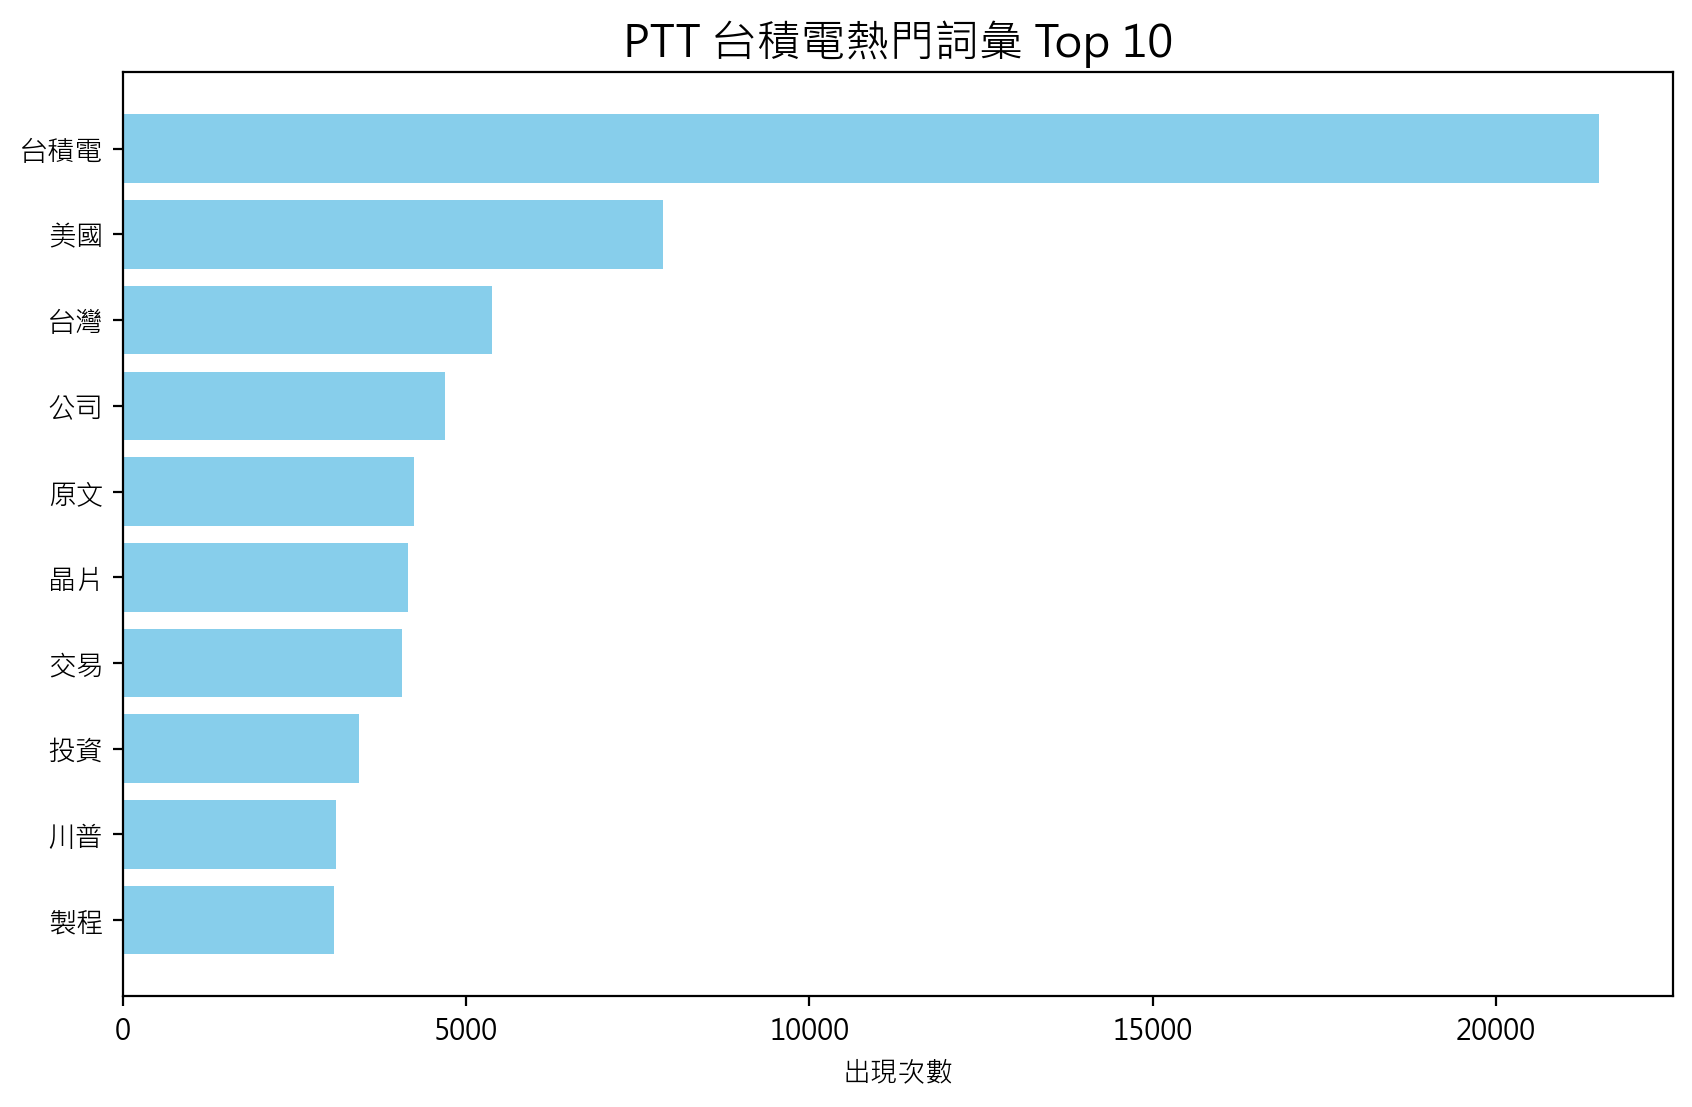

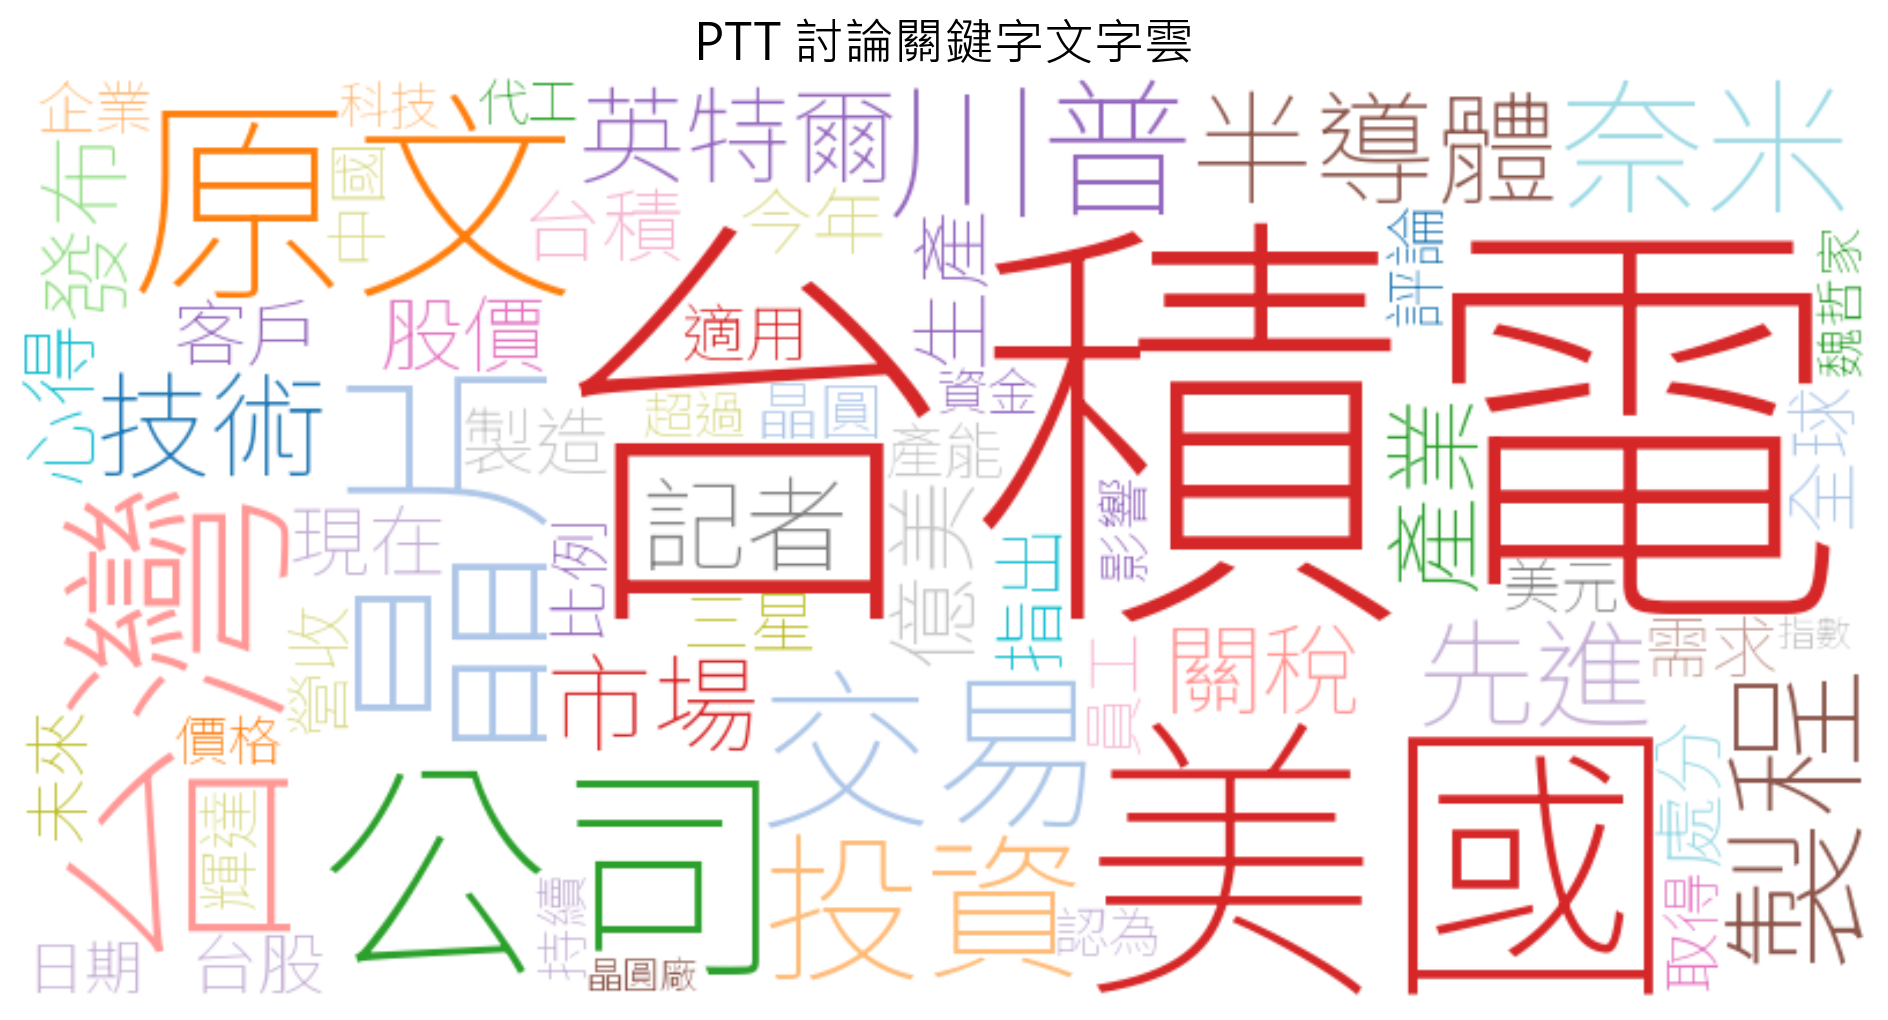


--- 檢查前 20 名高頻詞 ---
   word  count
0   台積電  21497
1    美國   7872
2    台灣   5382
3    公司   4692
4    原文   4239
5    晶片   4158
6    交易   4074
7    投資   3434
8    川普   3106
9    製程   3077
10   奈米   2881
11  半導體   2748
12   先進   2535
13   技術   2471
14  英特爾   2117
15   市場   2093
16   記者   2040
17   關稅   1875
18   產業   1862
19   發布   1686


In [ ]:
freq_df_nostop = word_df['word'].value_counts().reset_index()
freq_df_nostop.columns = ['word', 'count']

freq_dict = freq_df_nostop.set_index('word').to_dict()['count']

# 繪製長條圖
top_10_words = freq_df_nostop.head(10)
plt.figure(figsize=(10, 6), dpi=200)
plt.barh(top_10_words['word'], top_10_words['count'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("PTT 台積電熱門詞彙 Top 10", fontsize=16)
plt.xlabel("出現次數")
plt.show()
# 繪製文字雲
wordcloud = WordCloud(
    background_color='white',
    width=800,
    height=400,
    font_path=FONT_PATH,
    max_words=60,
    colormap='tab20'
)
wordcloud.generate_from_frequencies(freq_dict)
plt.figure(figsize=(12, 6), dpi=200)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("PTT 討論關鍵字文字雲", fontsize=18)
plt.show()

# 印出前20名檢查
print("\n--- 檢查前 20 名高頻詞 ---")
print(freq_df_nostop.head(20))

畫出「PTT 台積電議題討論聲量趨勢」每日折線圖，可觀察到 2025/3/4  的文章數量突然變多。

文章數量最高的日子：
artDate
2025-03-04    75
Freq: D, dtype: int64


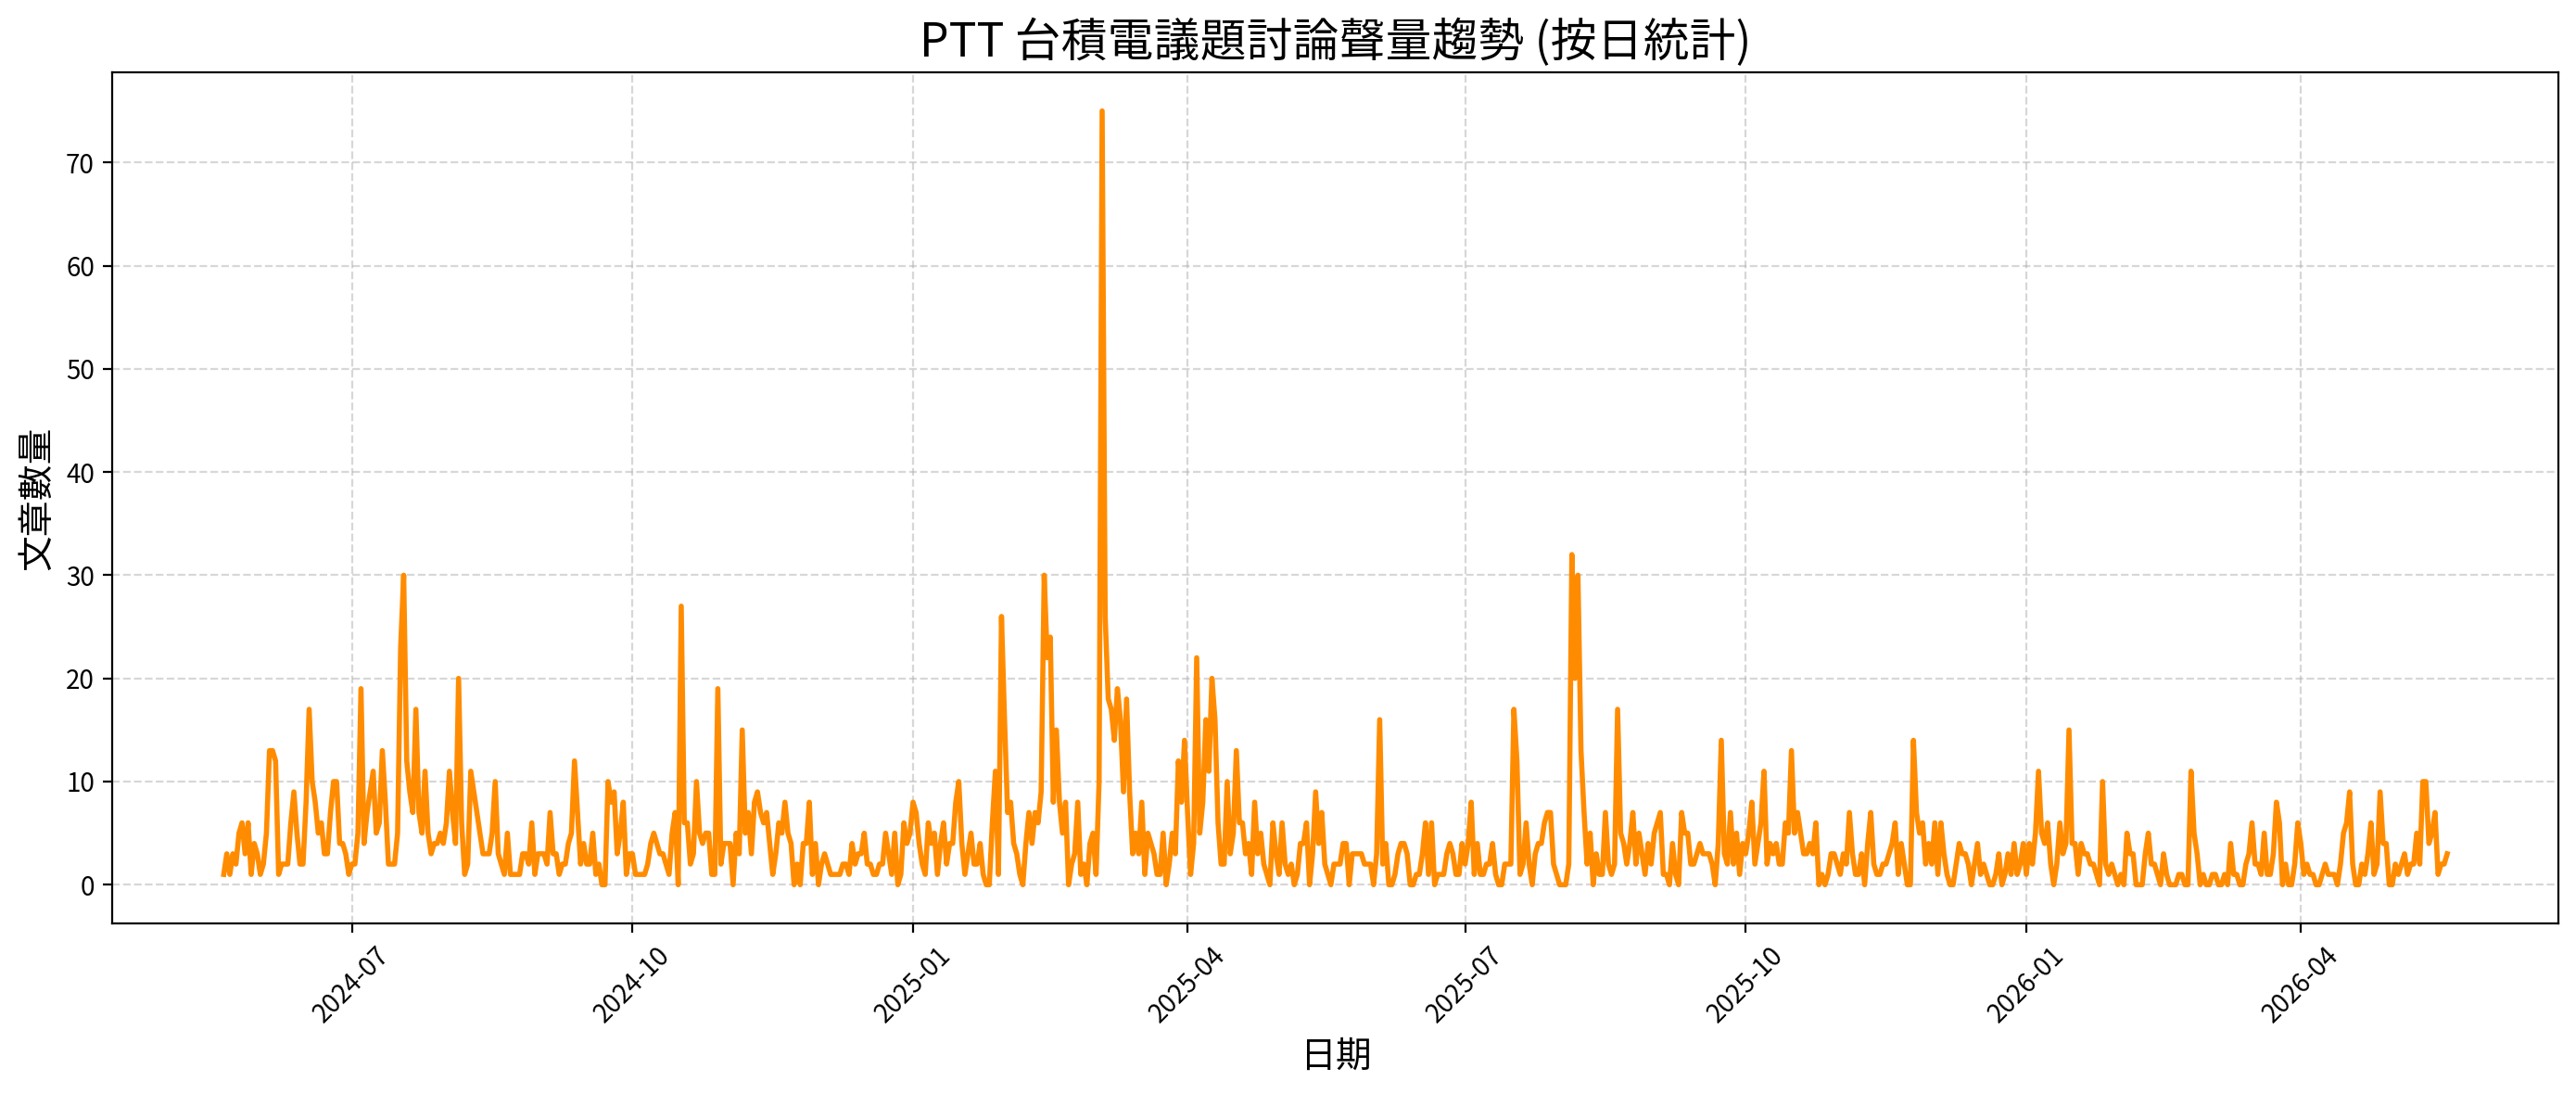

In [ ]:
df['artDate'] = pd.to_datetime(df['artDate'], errors='coerce')

# 依照天統計
daily_counts = df.resample('D', on='artDate').size()

# 找出文章數量最高的日子
max_count = daily_counts.max()
max_days = daily_counts[daily_counts == max_count]

print("文章數量最高的日子：")
print(max_days)

plt.figure(figsize=(14, 6), dpi=200)

plt.plot(
    daily_counts.index,
    daily_counts.values,
    color='darkorange',
    linewidth=2
)

plt.title("PTT 台積電議題討論聲量趨勢 (按日統計)", fontsize=18)
plt.xlabel("日期", fontsize=14)
plt.ylabel("文章數量", fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

列出單日文章數最高日期的所有文章，可發現 2025/3/4 當天由於台積電在白宮宣布赴美投資，因此引起相當多的討論

In [ ]:
# 顯示設定
pd.set_option('display.max_rows', None)        # 顯示所有列
pd.set_option('display.max_colwidth', None)    # 欄位文字不截斷
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# 列出最高討論日的文章標題
max_day_articles = df[
    df['artDate'].dt.floor('D').isin(max_days.index)
][['artDate', 'artTitle']].sort_values('artDate')

# 讓 artTitle 自動換行顯示
display(
    max_day_articles.style.set_properties(
        subset=['artTitle'],
        **{
            'white-space': 'normal',
            'text-align': 'left'
        }
    )
)

,artDate,artTitle
371,2025-03-04 01:27:25,[新聞] 台積電未來4年在美投資千億元「今天下午
2045,2025-03-04 02:35:23,[新聞] 關稅緊張局勢加劇 台積電ADR下殺3%
2044,2025-03-04 04:34:08,Re: [新聞] 台積電赴美投資 經長：爭取研發中心留台
2043,2025-03-04 05:12:07,[標的] 2330 台積電多
2042,2025-03-04 05:41:05,Re: [標的] 2330 台積電多
2041,2025-03-04 05:57:02,[請益] 台積電去美國投資是利多嗎
2040,2025-03-04 06:41:35,[請益] 魏哲家：台積電變美積電 門都沒有
2039,2025-03-04 06:53:36,Re: [請益] 台積電去美國投資是利多嗎
2038,2025-03-04 07:00:51,Re: [請益] 台積電去美國投資是利多嗎
2037,2025-03-04 07:02:05,Re: [請益] 魏哲家：台積電變美積電 門都沒有


### 2. 情緒分析

#### (1) LIWC

使用 LIWC 進行情緒分析

In [ ]:
def load_liwc(file_path):
    with open(file_path, 'r', encoding='utf-8-sig') as f:
        content = f.read()
        words = [w.strip() for w in content.split(',') if w.strip()]
    return set(words)

#載入
pos_words = load_liwc('./dict/liwc/positive.txt')
neg_words = load_liwc('./dict/liwc/negative.txt')

#建立對照表
pos_df = pd.DataFrame({'word': list(pos_words), 'sentiment_label': 1})
neg_df = pd.DataFrame({'word': list(neg_words), 'sentiment_label': -1})
liwc_full_dict = pd.concat([pos_df, neg_df], ignore_index=True)

In [ ]:
word_df['word'] = word_df['word'].astype(str).str.strip()
liwc_full_dict['word'] = liwc_full_dict['word'].astype(str).str.strip()
#merge
ptt_liwc_df = pd.merge(
    word_df[['artTitle', 'artDate', 'artContent', 'sentence', 'word']],
    liwc_full_dict,
    on='word',
    how="left"
)

#處理未對應到的詞
ptt_liwc_df['sentiment_label'] = ptt_liwc_df['sentiment_label'].fillna(0)
print(ptt_liwc_df[ptt_liwc_df['sentiment_label'] != 0][['word', 'sentiment_label']].head())

    word  sentiment_label
1     拋棄             -1.0
75    不錯              1.0
76    成就              1.0
109   傷悲             -1.0
166   福利              1.0


對每篇文章計算情緒分數，並算出每日的平均分數

In [ ]:
# 計算每篇文章的總情緒分數 (加總該文章所有詞的標籤值)
article_sentiment = ptt_liwc_df.groupby(['artTitle', 'artDate'])['sentiment_label'].sum().reset_index()

# 重新命名欄位以便識別
article_sentiment.rename(columns={'sentiment_label': 'article_score'}, inplace=True)

article_sentiment['artDate'] = pd.to_datetime(article_sentiment['artDate'])

# 計算每日平均情緒
daily_sentiment = article_sentiment.resample('D', on='artDate')['article_score'].mean()
daily_sentiment

artDate
2024-05-20    5.000000
2024-05-21   -5.333333
2024-05-22   -2.000000
2024-05-23    2.000000
2024-05-24    0.500000
                ...   
2026-05-15    4.571429
2026-05-16    0.000000
2026-05-17   -2.500000
2026-05-18   -2.000000
2026-05-19    3.666667
Freq: D, Name: article_score, Length: 730, dtype: float64

畫出 2025/03 的每日情緒走勢圖，可發現多數的情況都是正向情緒。
    
補充情緒分數低分析：  
*   20250314的其中一篇是轉載事實查核中心澄清沒有「張忠謀批國民黨政府大賣台積電持股」的情況，另一篇則是談論台積電利空，八大行庫護盤的事情。這兩篇的文章的內容都含有許多負面用詞，因此導致分數較低。
*   20250318則是因為該文章談論三星這幾年的經營危機導致情緒分數低


    



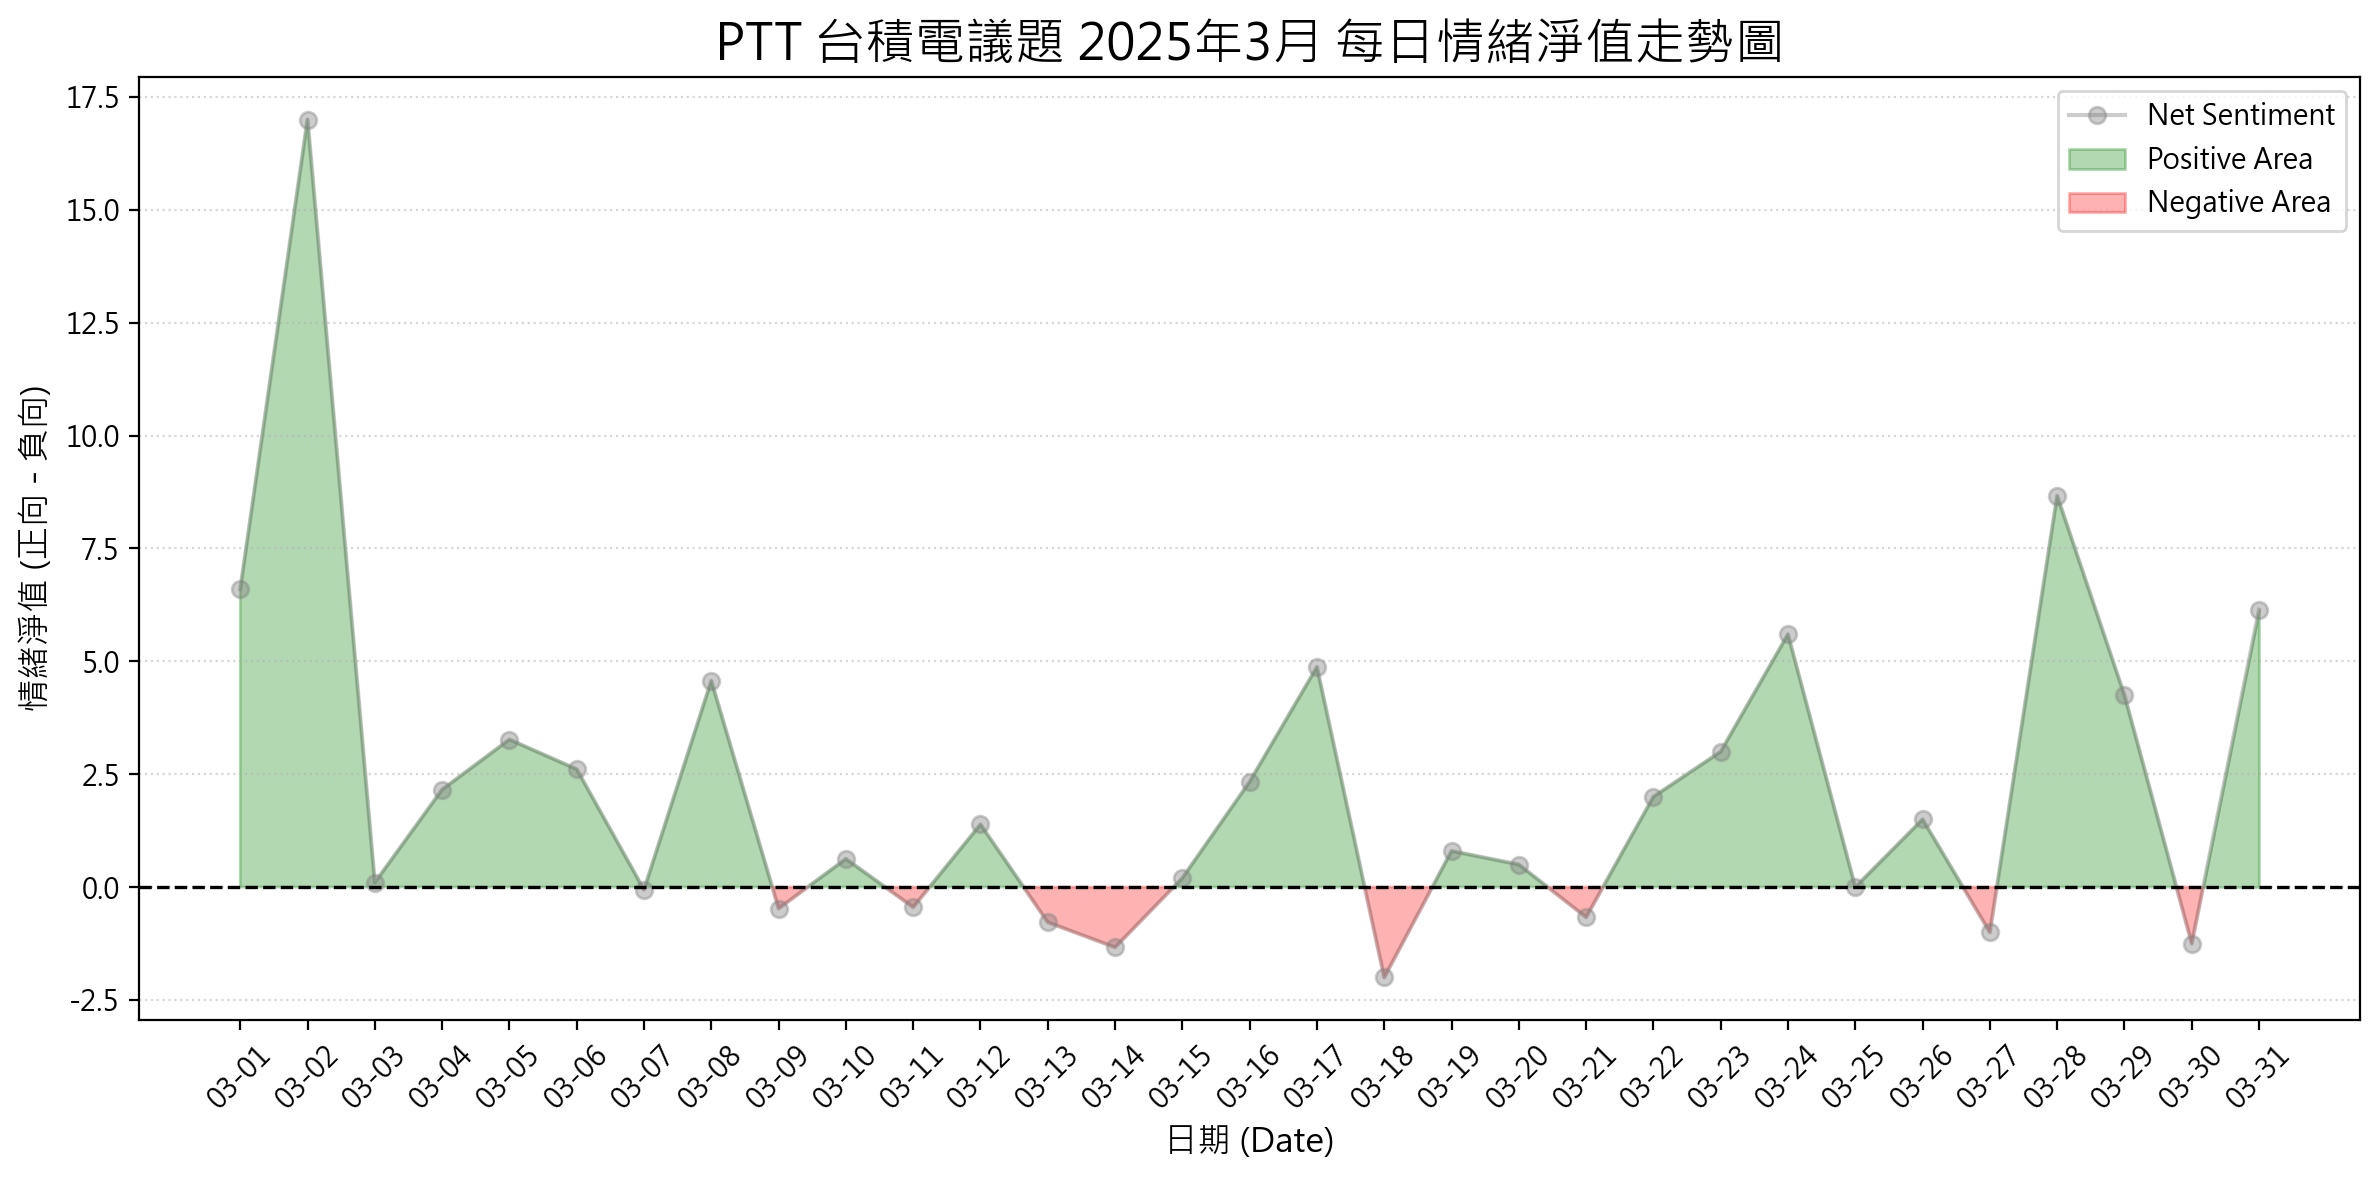

In [ ]:
# 確保 index 是 datetime
daily_sentiment.index = pd.to_datetime(daily_sentiment.index)

# 只取 2025/03
plot_data = daily_sentiment[
    (daily_sentiment.index.year == 2025) &
    (daily_sentiment.index.month == 3)
].fillna(0)

plt.figure(figsize=(12, 6), dpi=200)

plt.plot(
    plot_data.index,
    plot_data.values,
    marker='o',
    linestyle='-',
    color='gray',
    alpha=0.4,
    label='Net Sentiment'
)

plt.fill_between(
    plot_data.index,
    0,
    plot_data.values,
    where=(plot_data.values >= 0),
    color='green',
    alpha=0.3,
    interpolate=True,
    label='Positive Area'
)

plt.fill_between(
    plot_data.index,
    0,
    plot_data.values,
    where=(plot_data.values < 0),
    color='red',
    alpha=0.3,
    interpolate=True,
    label='Negative Area'
)

plt.axhline(0, color='black', linewidth=1.2, linestyle='--')

plt.title("PTT 台積電議題 2025年3月 每日情緒淨值走勢圖", fontsize=18)
plt.xlabel("日期 (Date)", fontsize=12)
plt.ylabel("情緒淨值 (正向 - 負向)", fontsize=12)

plt.xticks(
    plot_data.index,
    [d.strftime('%m-%d') for d in plot_data.index],
    rotation=45
)

plt.grid(True, axis='y', linestyle=':', alpha=0.5)

plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

其中 0302 的情緒分數非常高，為了觀察是甚麼原因造成，列出影響分數的詞彙。  
這天的文章標題是 **”[情報] Intel 18A已準備就緒，官方宣稱領先台積”** 以及 **”[新聞] 不用台積電救了？前CEO籲英特爾迎回季辛格”**。  
其中該日的情緒分數都是由第二篇文章提供。該文章引述intel前CEO 提到季辛格為 intel 帶來的貢獻並批評當時 intel 做的一系列商業決定。然而實際上文章內容大多是批評，因此可以觀察到 LIWC 在判斷文章情緒時，仍有一定挑戰。

In [ ]:
ptt_liwc_df['artDate'] = pd.to_datetime(ptt_liwc_df['artDate'])
target_date = '2025-03-02'

day_df = ptt_liwc_df[
    ptt_liwc_df['artDate'].dt.date == pd.to_datetime(target_date).date()
].copy()

day_sent_words = day_df[day_df['sentiment_label'] != 0].copy()

# 查看每個詞的貢獻
word_contrib = (
    day_sent_words
    .groupby(['word', 'sentiment_label'])
    .size()
    .reset_index(name='count')
)

word_contrib['contribution'] = (
    word_contrib['count'] * word_contrib['sentiment_label']
)

top_positive = word_contrib.sort_values(
    'contribution', ascending=False
)

top_positive

,word,sentiment_label,count,contribution
3,出色,1.0,3,3.0
20,贊成,1.0,2,2.0
12,成就,1.0,2,2.0
2,公平,1.0,1,1.0
4,協助,1.0,1,1.0
1,信任,1.0,1,1.0
0,保證,1.0,1,1.0
16,稱讚,1.0,1,1.0
6,好處,1.0,1,1.0
13,支持,1.0,1,1.0


畫出正負情緒聲量折線圖，可發現多數日子中，正向詞的出現次數都比負向詞還多

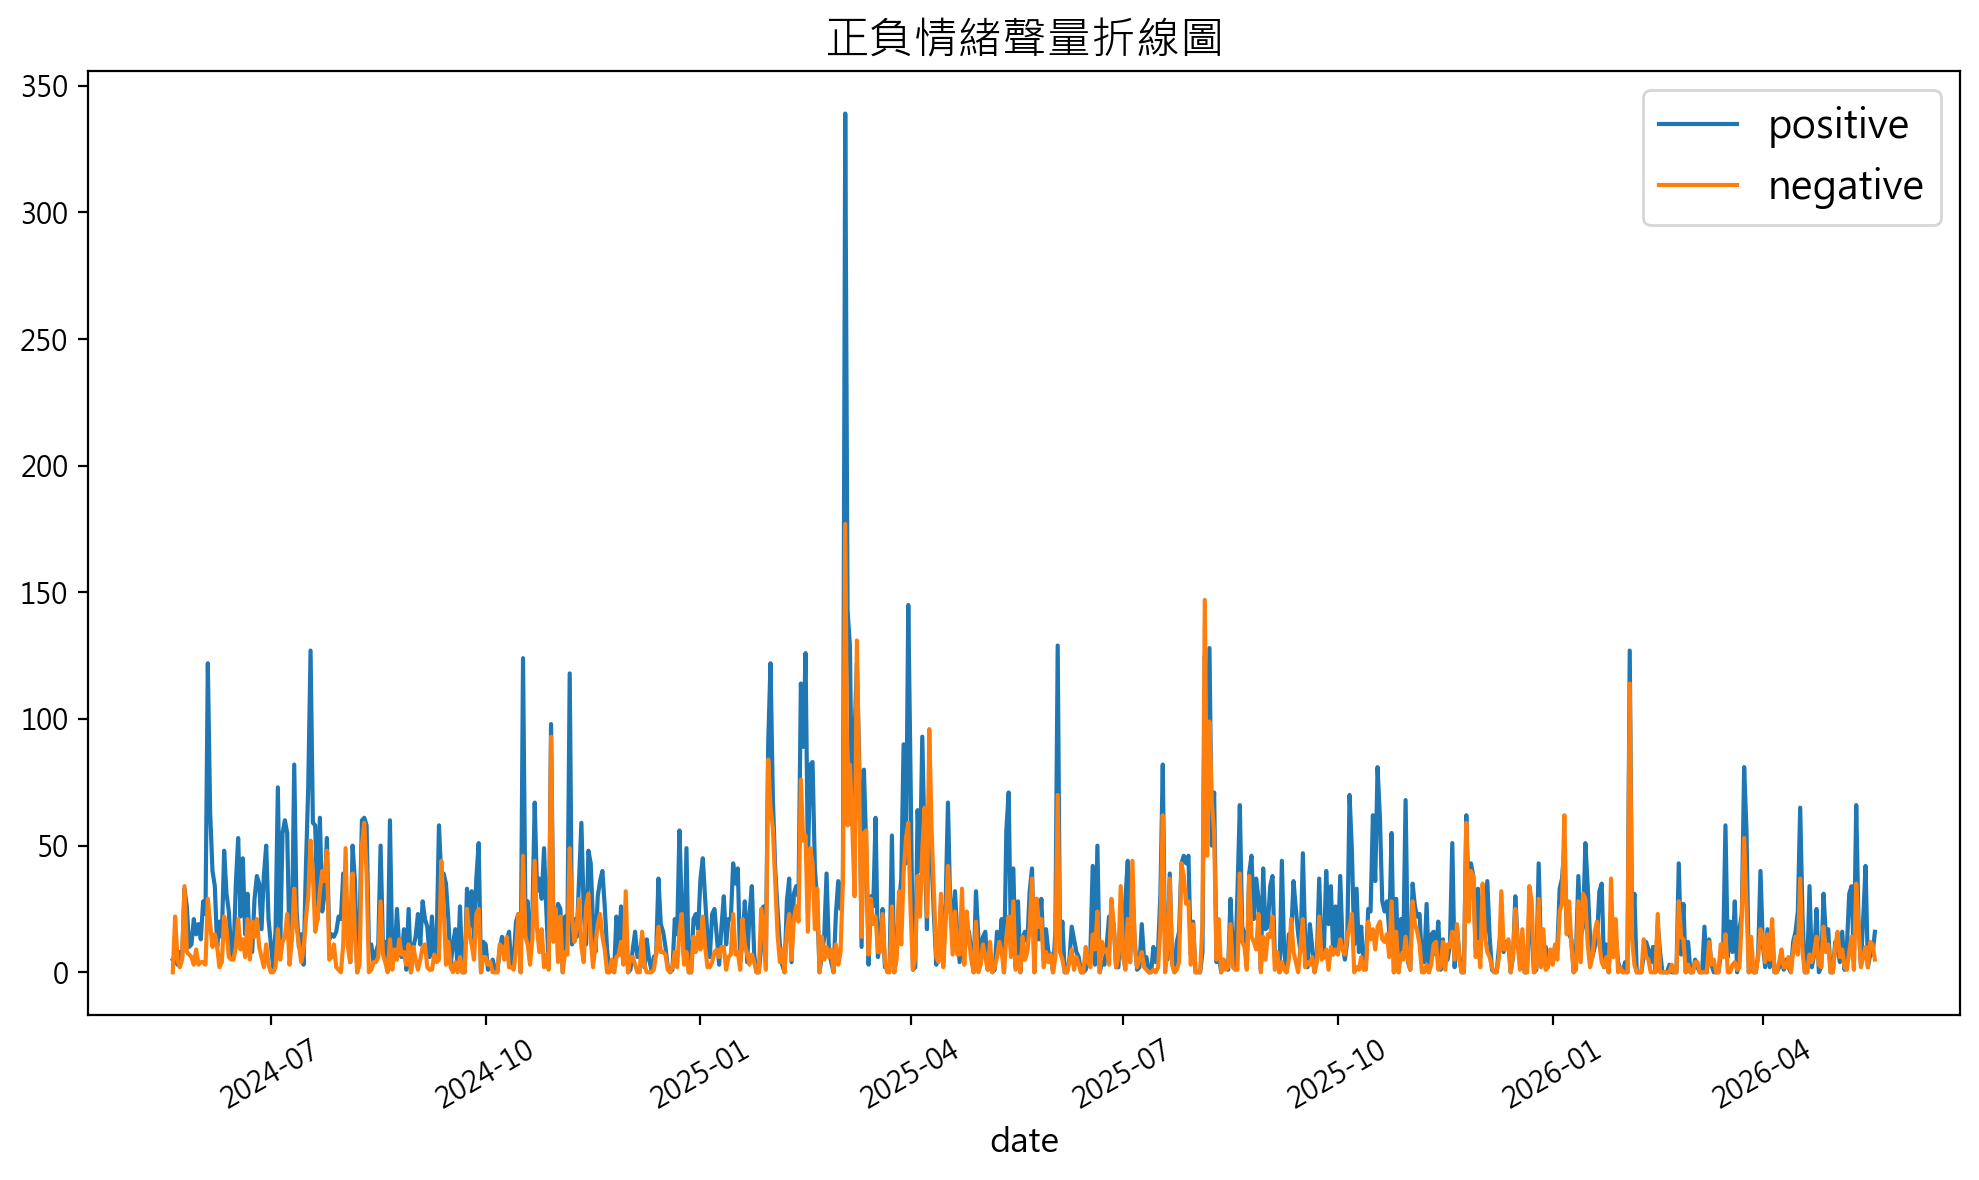

In [ ]:
# 計算每天的正向與負向詞頻
df_plot = ptt_liwc_df.copy()
df_plot['artDate'] = pd.to_datetime(df_plot['artDate'])

# 建立暫時的欄位來統計次數
df_plot['pos_hits'] = (df_plot['sentiment_label'] > 0).astype(int)
df_plot['neg_hits'] = (df_plot['sentiment_label'] < 0).astype(int)

# 日期聚合
daily_trend = df_plot.resample('D', on='artDate')[['pos_hits', 'neg_hits']].sum()


plt.figure(figsize=(10, 6), dpi=200)


plt.plot(daily_trend.index, daily_trend['pos_hits'], label='positive', color='#1f77b4', linewidth=1.5)


plt.plot(daily_trend.index, daily_trend['neg_hits'], label='negative', color='#ff7f0e', linewidth=1.5)


plt.title("正負情緒聲量折線圖",  fontsize=16)
plt.xlabel("date", fontsize=12)

plt.legend(prop={'size': 14})

plt.xticks(rotation=30)
plt.grid(False)
plt.tight_layout()

plt.show()

劃出正向詞與負向詞出現次數的 Top 15，畫成左右並排長條圖

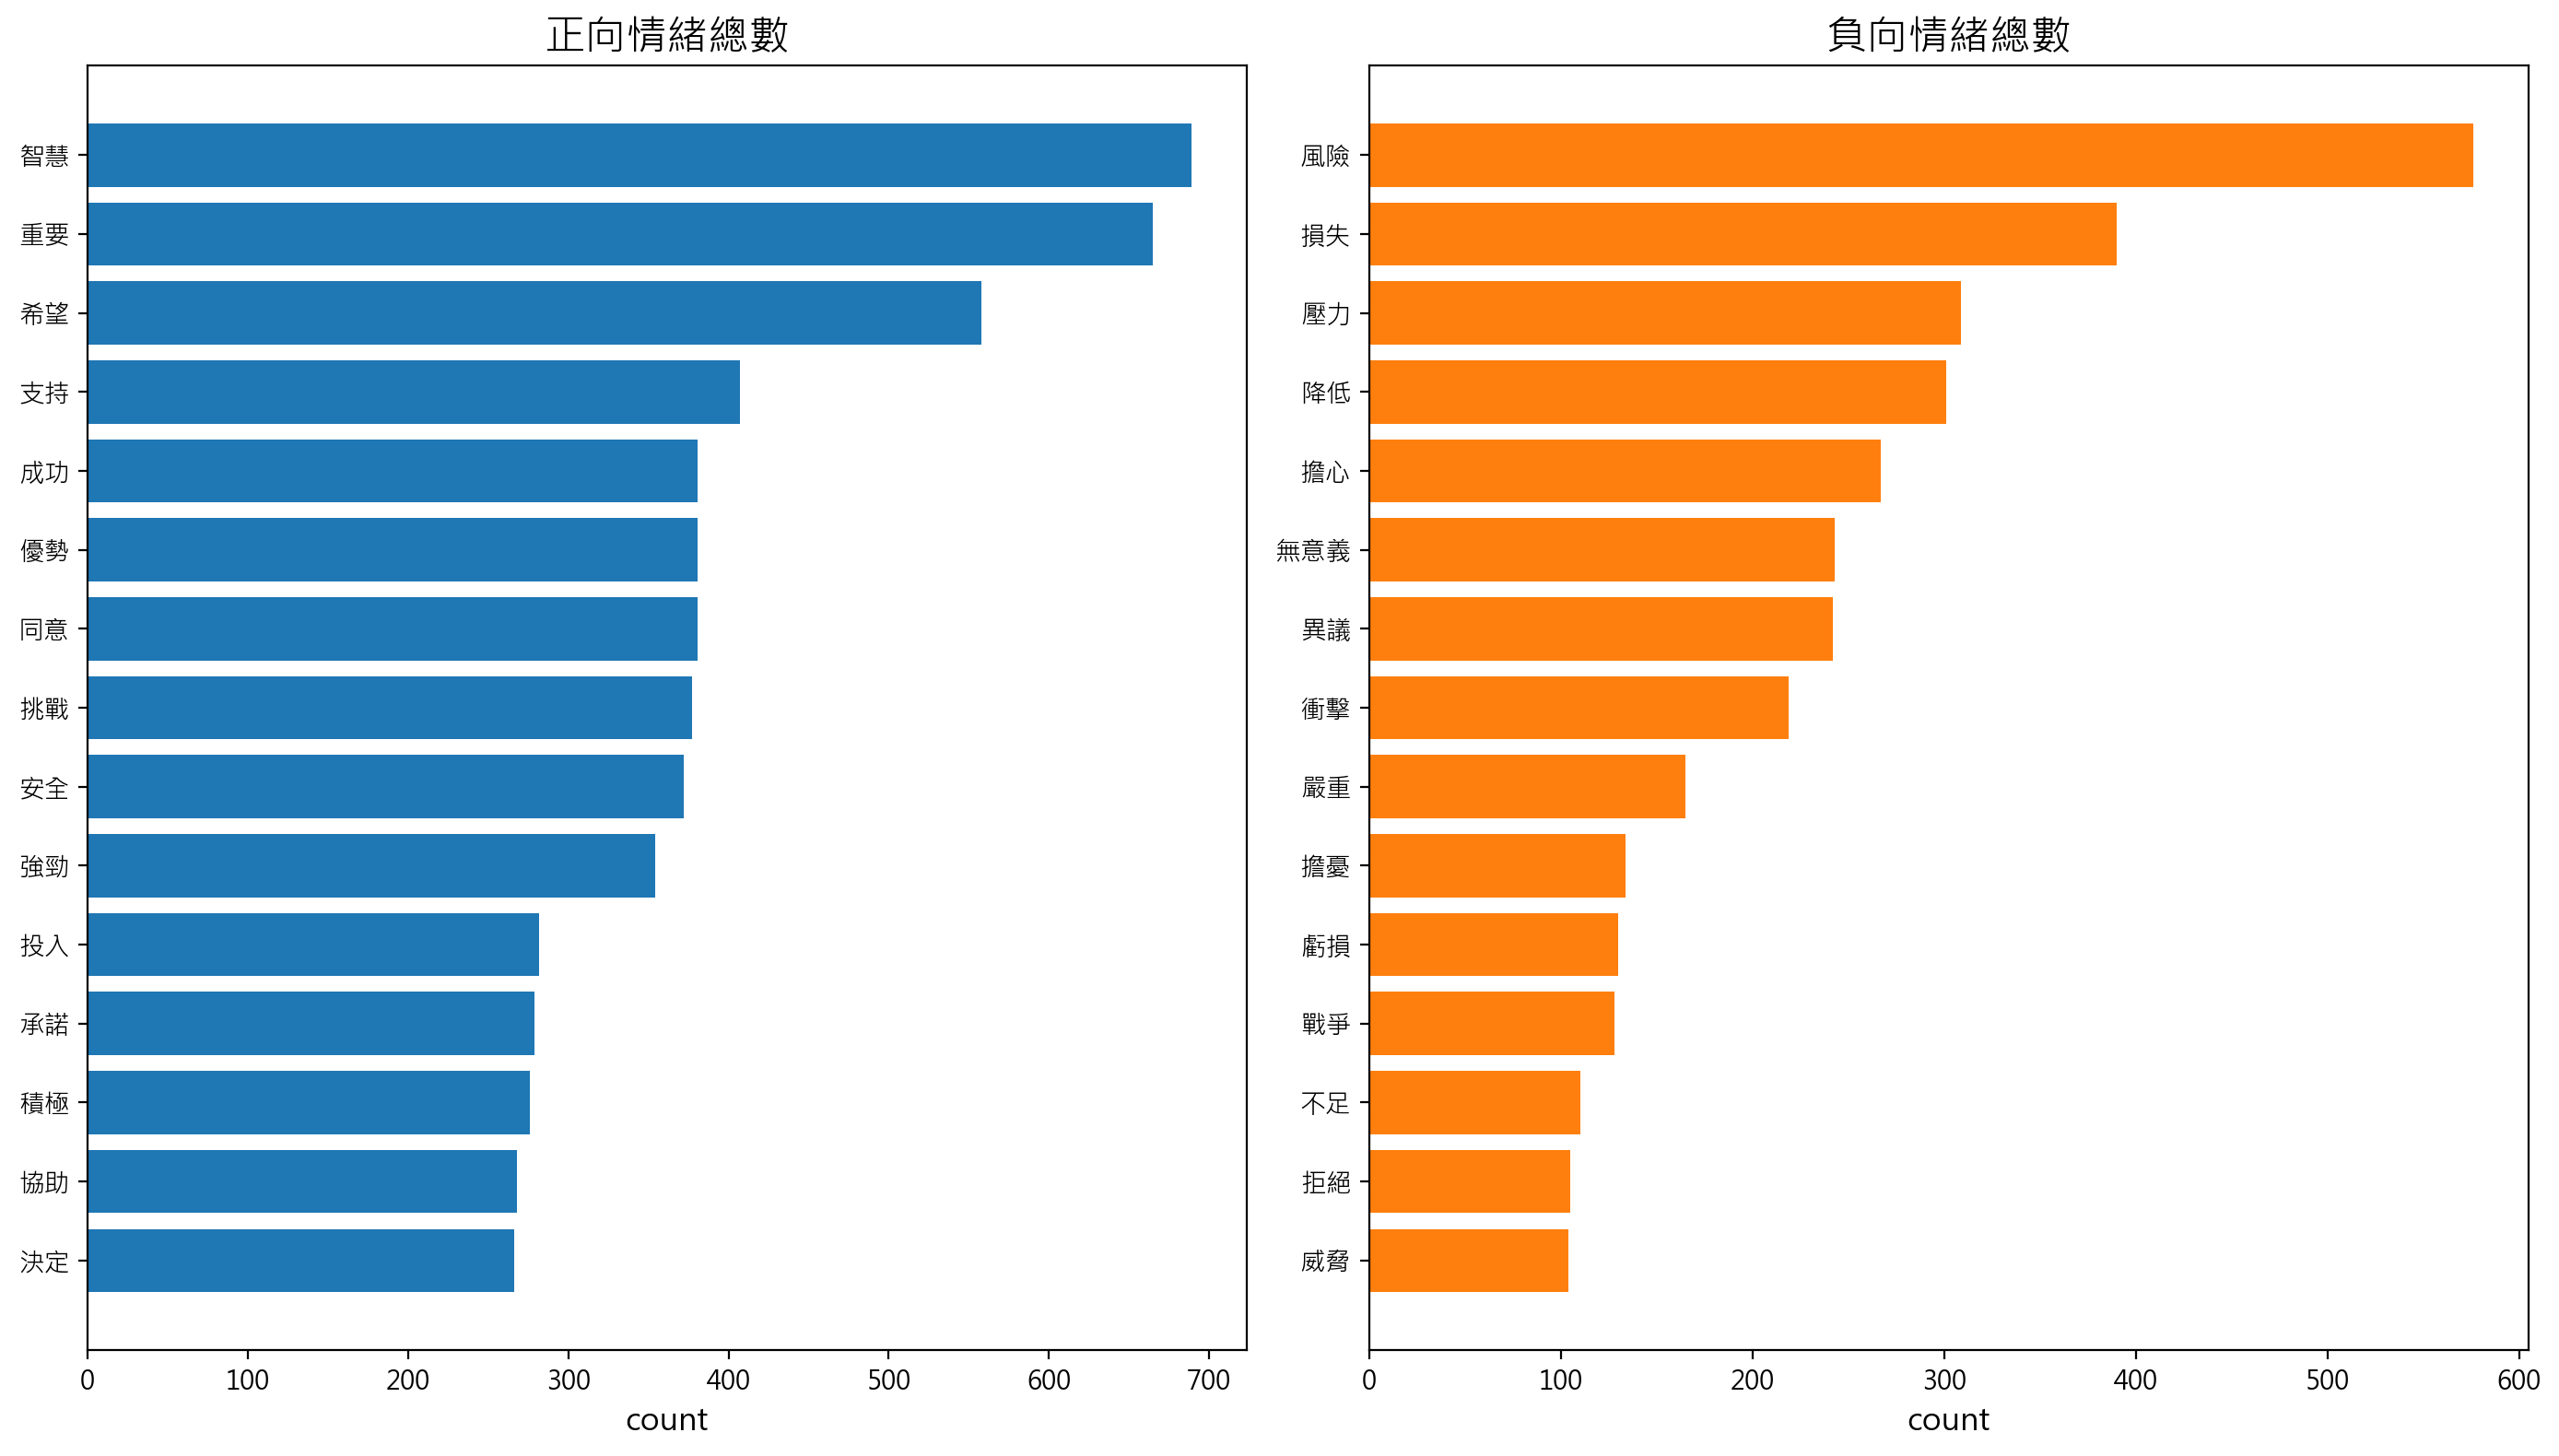

In [ ]:
#篩選正向與負向詞彙，並排除標籤為 0 的中立詞
pos_data = ptt_liwc_df[ptt_liwc_df['sentiment_label'] > 0]
neg_data = ptt_liwc_df[ptt_liwc_df['sentiment_label'] < 0]

#統計詞頻
top_pos = pos_data['word'].value_counts().head(15).reset_index()
top_pos.columns = ['word', 'count']

top_neg = neg_data['word'].value_counts().head(15).reset_index()
top_neg.columns = ['word', 'count']

fig, ax = plt.subplots(1, 2, figsize=(14, 8), dpi=200)

ax[0].barh(top_pos['word'], top_pos['count'], color='#1f77b4')
ax[0].set_title('正向情緒總數', fontsize=16)
ax[0].invert_yaxis()
ax[0].set_xlabel('count', fontsize=12)



ax[1].barh(top_neg['word'], top_neg['count'], color='#ff7f0e') # 橘色
ax[1].set_title('負向情緒總數',  fontsize=16)
ax[1].invert_yaxis()
ax[1].set_xlabel('count', fontsize=12)

plt.tight_layout()
plt.show()

#### (2) chinese_sentiment 情感分析



使用 Huggingface fine-tuned 中文情感模型 `techthiyanes/chinese_sentiment`，
對每篇文章進行情感評分（1＝最負面 → 5＝最正面），
再結合時間軸觀察台積電輿情趨勢。

In [ ]:
import sys
import torch
import transformers

print("Python 路徑：", sys.executable)
print("Torch 版本：", torch.__version__)
print("Transformers 版本：", transformers.__version__)

Python 路徑： d:\media\.venv\Scripts\python.exe
Torch 版本： 2.11.0+cpu
Transformers 版本： 5.12.0


In [ ]:
# 載入情感分析模型
sentiment_model = hf_pipeline(
    'sentiment-analysis',
    model='techthiyanes/chinese_sentiment',
    truncation=True,
    max_length=512
)

# 標籤對照
label_map = {
    'star 1': 1, 'star 2': 2, 'star 3': 3,
    'star 4': 4, 'star 5': 5
}

print("情感模型載入完成")
# 小測試
test_texts = ['台積電薪資福利非常好', '工作壓力太大想離職', '這季財報普通']
for t in test_texts:
    r = sentiment_model(t)[0]
    print(f"  {t}  →  label={r['label']!r}  (score={r['score']:.3f})")

INFO:httpx:HTTP Request: HEAD https://huggingface.co/techthiyanes/chinese_sentiment/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/techthiyanes/chinese_sentiment/215de6a818f1fbd430e8a1d45b7a4681c0936102/config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/techthiyanes/chinese_sentiment/resolve/main/model.safetensors "HTTP/1.1 404 Not Found"


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/techthiyanes/chinese_sentiment "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/techthiyanes/chinese_sentiment/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/techthiyanes/chinese_sentiment/commits/main "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/techthiyanes/chinese_sentiment/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/techthiyanes/chinese_sentiment/discussions?p=0 "HTTP/1.1 200 OK"
d:\media\.venv\Lib\site-packages\transformers\models\bert\tokenization_bert.py:104: DeprecationWarning:

Deprecated in 0.9.0: WordPiece.__init__ will not create from files anymore, try `WordPiece.from_file` instead

INFO:httpx:HTTP Request: HEAD https://huggingface.co/techthiyanes/chinese_sentiment/r

情感模型載入完成


INFO:httpx:HTTP Request: HEAD https://huggingface.co/techthiyanes/chinese_sentiment/resolve/refs%2Fpr%2F3/model.safetensors "HTTP/1.1 302 Found"


  台積電薪資福利非常好  →  label='star 5'  (score=0.500)
  工作壓力太大想離職  →  label='star 1'  (score=0.340)
  這季財報普通  →  label='star 3'  (score=0.390)


對所有文章進行情感分析

In [ ]:
def get_sentiment(text):
    try:
        result = sentiment_model(text[:512])[0]
        score = label_map.get(result['label'])
        # 如果還是找不到 key
        if score is None:
            print(f"[警告] 未知 label: {result['label']!r}，文字片段: {text[:30]!r}")
            return 3, 0.0
        return score, result['score']
    except Exception as e:
        print(f"[例外] {e}，文字片段: {text[:30]!r}")
        return 3, 0.0

print(f"開始對 {len(article_corpus)} 篇文章進行情感分析，請稍候...")
results = article_corpus['full_text'].apply(get_sentiment)
article_corpus['sentiment_score'] = results.apply(lambda x: x[0])
article_corpus['sentiment_conf']  = results.apply(lambda x: x[1])

print("情感分析完成！")
print(article_corpus['sentiment_score'].value_counts().sort_index())

開始對 3166 篇文章進行情感分析，請稍候...
情感分析完成！
sentiment_score
1      80
2      21
3     117
4     139
5    2809
Name: count, dtype: int64


畫成長條圖後，能明顯發現正面情緒的數量遠遠大過其他情緒。但由於情感分數高度集中於 5 分，可能是模型能力有限或資料存在問題。另外 PTT 文章與股市、科技業新聞常包含反諷、模板文字與長篇討論，而程式僅取前 512 字進行判斷，可能導致模型未能完整捕捉文章情緒。


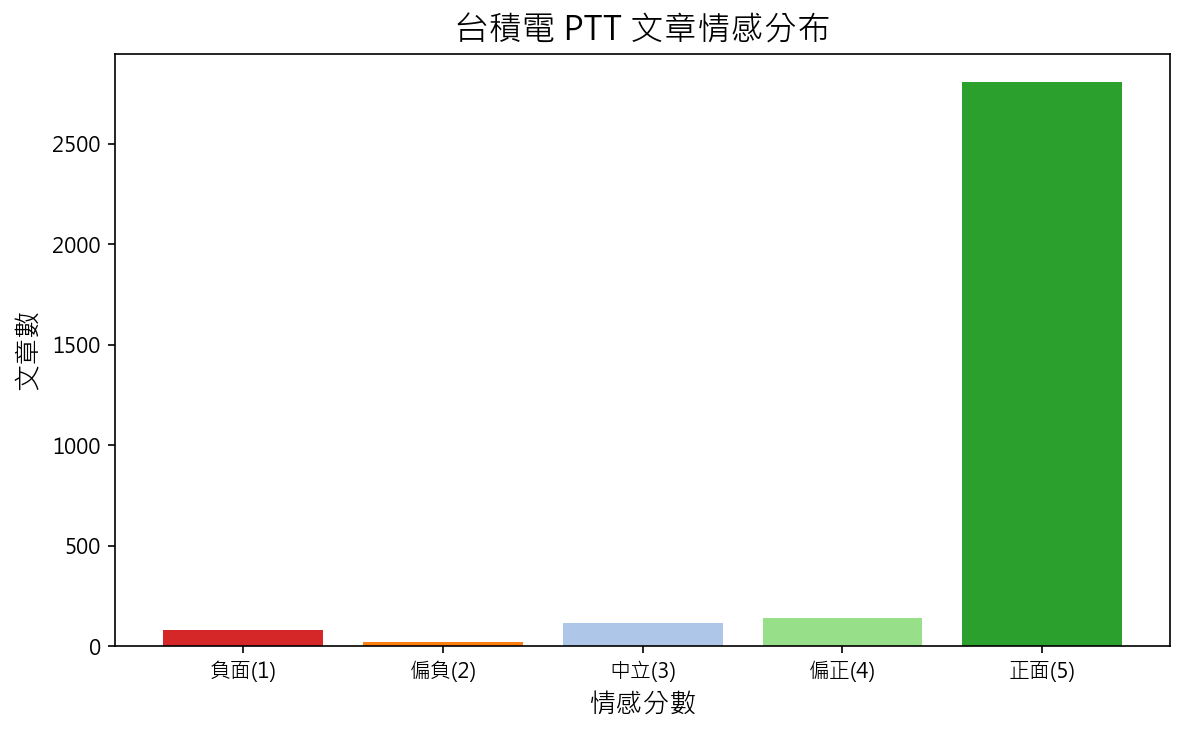

In [ ]:
# 情感分布長條圖
score_labels = {1: '負面(1)', 2: '偏負(2)', 3: '中立(3)', 4: '偏正(4)', 5: '正面(5)'}
counts = article_corpus['sentiment_score'].value_counts().sort_index()

plt.figure(figsize=(8, 5), dpi=150)
colors = ['#d62728', '#ff7f0e', '#aec7e8', '#98df8a', '#2ca02c']
plt.bar([score_labels[i] for i in counts.index], counts.values, color=colors)
plt.title('台積電 PTT 文章情感分布', fontsize=16)
plt.xlabel('情感分數', fontsize=13)
plt.ylabel('文章數', fontsize=13)
plt.tight_layout()
plt.show()

在此圖片中以月份計算平均情感分數與文章數，台積電相關 PTT 文章的平均情感分數長期維持在 4.5 以上，顯示整體情緒都偏正向。


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


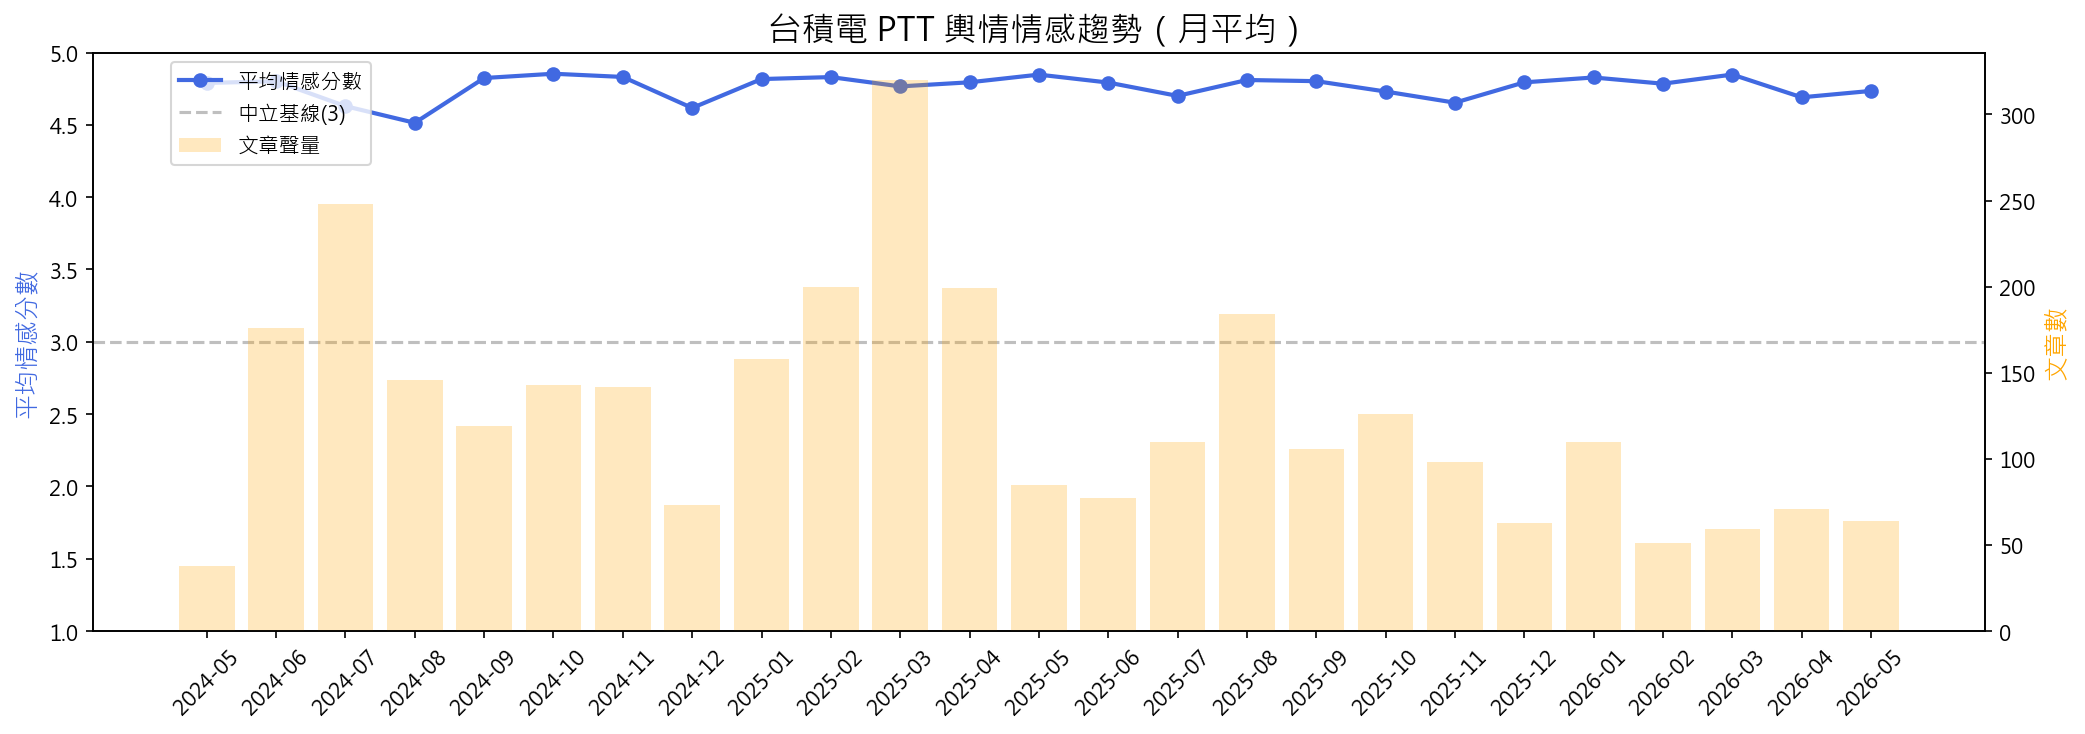

In [ ]:
# 情感時間趨勢（月平均情感分數)
sentiment_trend = article_corpus.copy()
sentiment_trend['artDate'] = pd.to_datetime(df['artDate'], errors='coerce').values

# 以月為單位計算平均情感
sentiment_trend['month'] = sentiment_trend['artDate'].dt.to_period('M')
monthly_sentiment = sentiment_trend.groupby('month')['sentiment_score'].agg(['mean', 'count']).reset_index()
monthly_sentiment['month_str'] = monthly_sentiment['month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5), dpi=150)

# 平均情感（左軸）
ax1.plot(monthly_sentiment['month_str'], monthly_sentiment['mean'],
         color='royalblue', marker='o', linewidth=2, label='平均情感分數')
ax1.axhline(y=3, color='gray', linestyle='--', alpha=0.5, label='中立基線(3)')
ax1.set_ylabel('平均情感分數', color='royalblue', fontsize=12)
ax1.set_ylim(1, 5)
ax1.tick_params(axis='x', rotation=45)

# 聲量（右軸）
ax2 = ax1.twinx()
ax2.bar(monthly_sentiment['month_str'], monthly_sentiment['count'],
        alpha=0.25, color='orange', label='文章聲量')
ax2.set_ylabel('文章數', color='orange', fontsize=12)

plt.title('台積電 PTT 輿情情感趨勢（月平均）', fontsize=16)
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.92), fontsize=10)
plt.tight_layout()
plt.show()

### 3. 熱門詞彙分析

#### (1) CKIP 詞性與熱門實體分析

載入 CKIP  套件

In [ ]:
os.makedirs("./ckip_model", exist_ok=True)

data_utils.download_data_gdown("./ckip_model")

Downloading...
From (original): https://drive.google.com/uc?id=1efHsY16pxK0lBD2gYCgCTnv1Swstq771
From (redirected): https://drive.google.com/uc?id=1efHsY16pxK0lBD2gYCgCTnv1Swstq771&confirm=t&uuid=a377d6e3-b586-422b-ad2a-ec6b143ee96a
To: d:\media\final\社媒\社媒\ckip_model\data.zip
100%|██████████| 1.88G/1.88G [09:02<00:00, 3.46MB/s]


In [ ]:
ws = WS("./ckip_model/data")
pos = POS("./ckip_model/data")
ner = NER("./ckip_model/data")

d:\media\.venv\Lib\site-packages\ckiptagger\model_ws.py:106: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
d:\media\.venv\Lib\site-packages\ckiptagger\model_pos.py:56: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)
d:\media\.venv\Lib\site-packages\ckiptagger\model_ner.py:57: UserWarning: `tf.nn.rnn_cell.LSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  cell = tf.compat.v1.nn.rnn_cell.LSTMCell(hidden_d, name=name)


進行斷詞，並列出詞性統計表

In [ ]:
test_sentences = sent_df['sentence'].tolist()

#斷詞
word_list = ws(test_sentences)

#標註詞性
pos_list = pos(word_list)

pos_data = []
for i, (words, tags) in enumerate(zip(word_list, pos_list)):
    for word, tag in zip(words, tags):
        pos_data.append({
            'Sentence_ID': i,
            'Word': word,
            'POS': tag
        })

# 轉換成 DataFrame
df_pos = pd.DataFrame(pos_data)

# 顯示前 10 筆結果
df_pos.head(10)
pos_filter = df_pos[~df_pos.POS.isin(['COMMACATEGORY', 'PARENTHESISCATEGORY', 'PERIODCATEGORY', 'COLONCATEGORY'])]

pos_count = pos_filter.groupby(['POS'])['POS'].count().reset_index(name='count').sort_values(['count'], ascending=False).head(12)
pos_count

,POS,count
19,Na,251395
5,D,99111
41,VC,87108
21,Nc,60712
47,VH,58459
20,Nb,55573
33,P,46271
7,DE,41118
44,VE,31393
29,Nf,30104


畫成圓餅圖，名詞比例明顯高於形容詞，顯示這兩個版較常圍繞具體對象與資訊，而直接形容式的情緒評價相對較少。推測若是尋找心情抒發較多的板，可能形容詞的比例會變高。

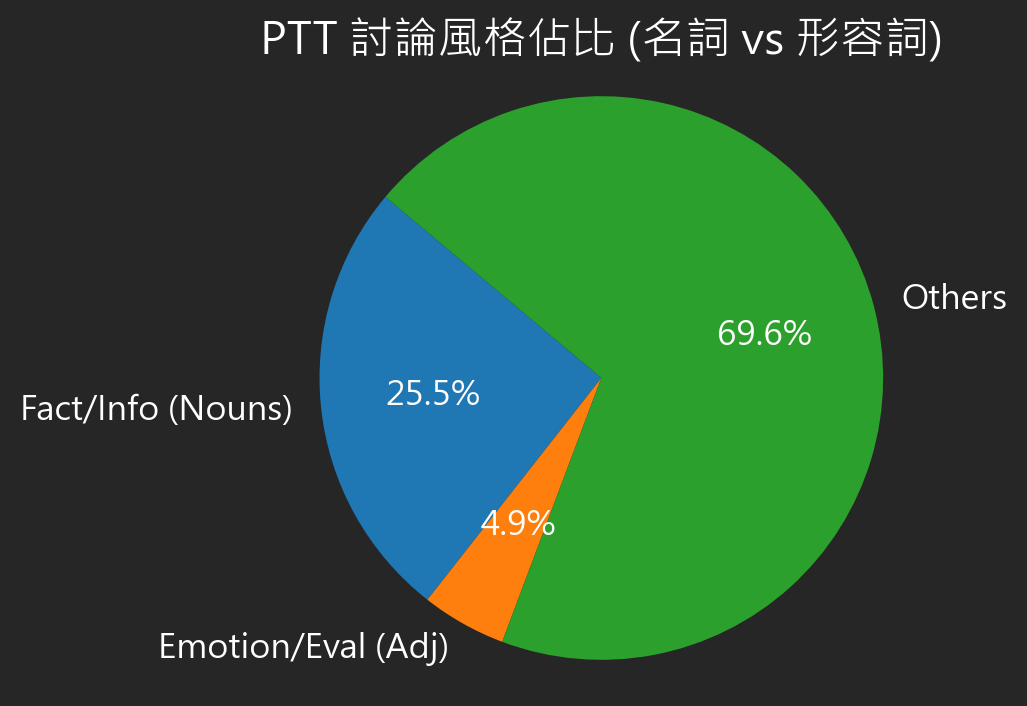

In [ ]:
noun_count = df_pos[df_pos['POS'].isin(['Na', 'Nb'])].shape[0]
adj_count = df_pos[df_pos['POS'] == 'VH'].shape[0]
other_count = df_pos.shape[0] - noun_count - adj_count


labels = ['Fact/Info (Nouns)', 'Emotion/Eval (Adj)', 'Others']
sizes = [noun_count, adj_count, other_count]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
plt.figure(figsize=(4, 4), dpi=200, facecolor='#262626')

patches, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    textprops={'color': 'white', 'fontsize': 12}
)

plt.title("PTT 討論風格佔比 (名詞 vs 形容詞)", fontsize=16, color='white')
plt.axis('equal')
plt.show()

執行 CKIP NER，並抽出 10 個名詞

In [ ]:
ner_list = ner(word_list, pos_list)
#把所有實體攤平成一個清單
all_entities = [entity for entity_set in ner_list for entity in entity_set]

# 隨機抽出 10 個
num_to_sample = min(10, len(all_entities))
random_samples = random.sample(all_entities, num_to_sample)

#顯示結果
print(f"--- 從 {len(all_entities)} 個實體中隨機抽出 {num_to_sample} 個 ---")
for entity in random_samples:
    print(f"實體類型: {entity[2]} | 內容: {entity[3]}")

--- 從 110722 個實體中隨機抽出 10 個 ---
實體類型: ORG | 內容: 群創
實體類型: ORG | 內容: 台積電
實體類型: DATE | 內容: 去年
實體類型: GPE | 內容: 美國
實體類型: QUANTITY | 內容: 平方毫米
實體類型: PERSON | 內容: 周筠羚
實體類型: ORG | 內容: 聯電
實體類型: CARDINAL | 內容: 萬
實體類型: ORG | 內容: 台積電
實體類型: GPE | 內容: 亞利桑那州


In [ ]:
ner_data = []
for entities in ner_list:
    for ent in entities:
        ner_data.append({'Type': ent[2], 'Entity': ent[3]})

df_ner = pd.DataFrame(ner_data)

篩選 PERSON、GPE、ORG 三類實體，統計 Top 15 熱點實體，可以發現大多數的熱門詞彙多與台積電國際擴廠相關。

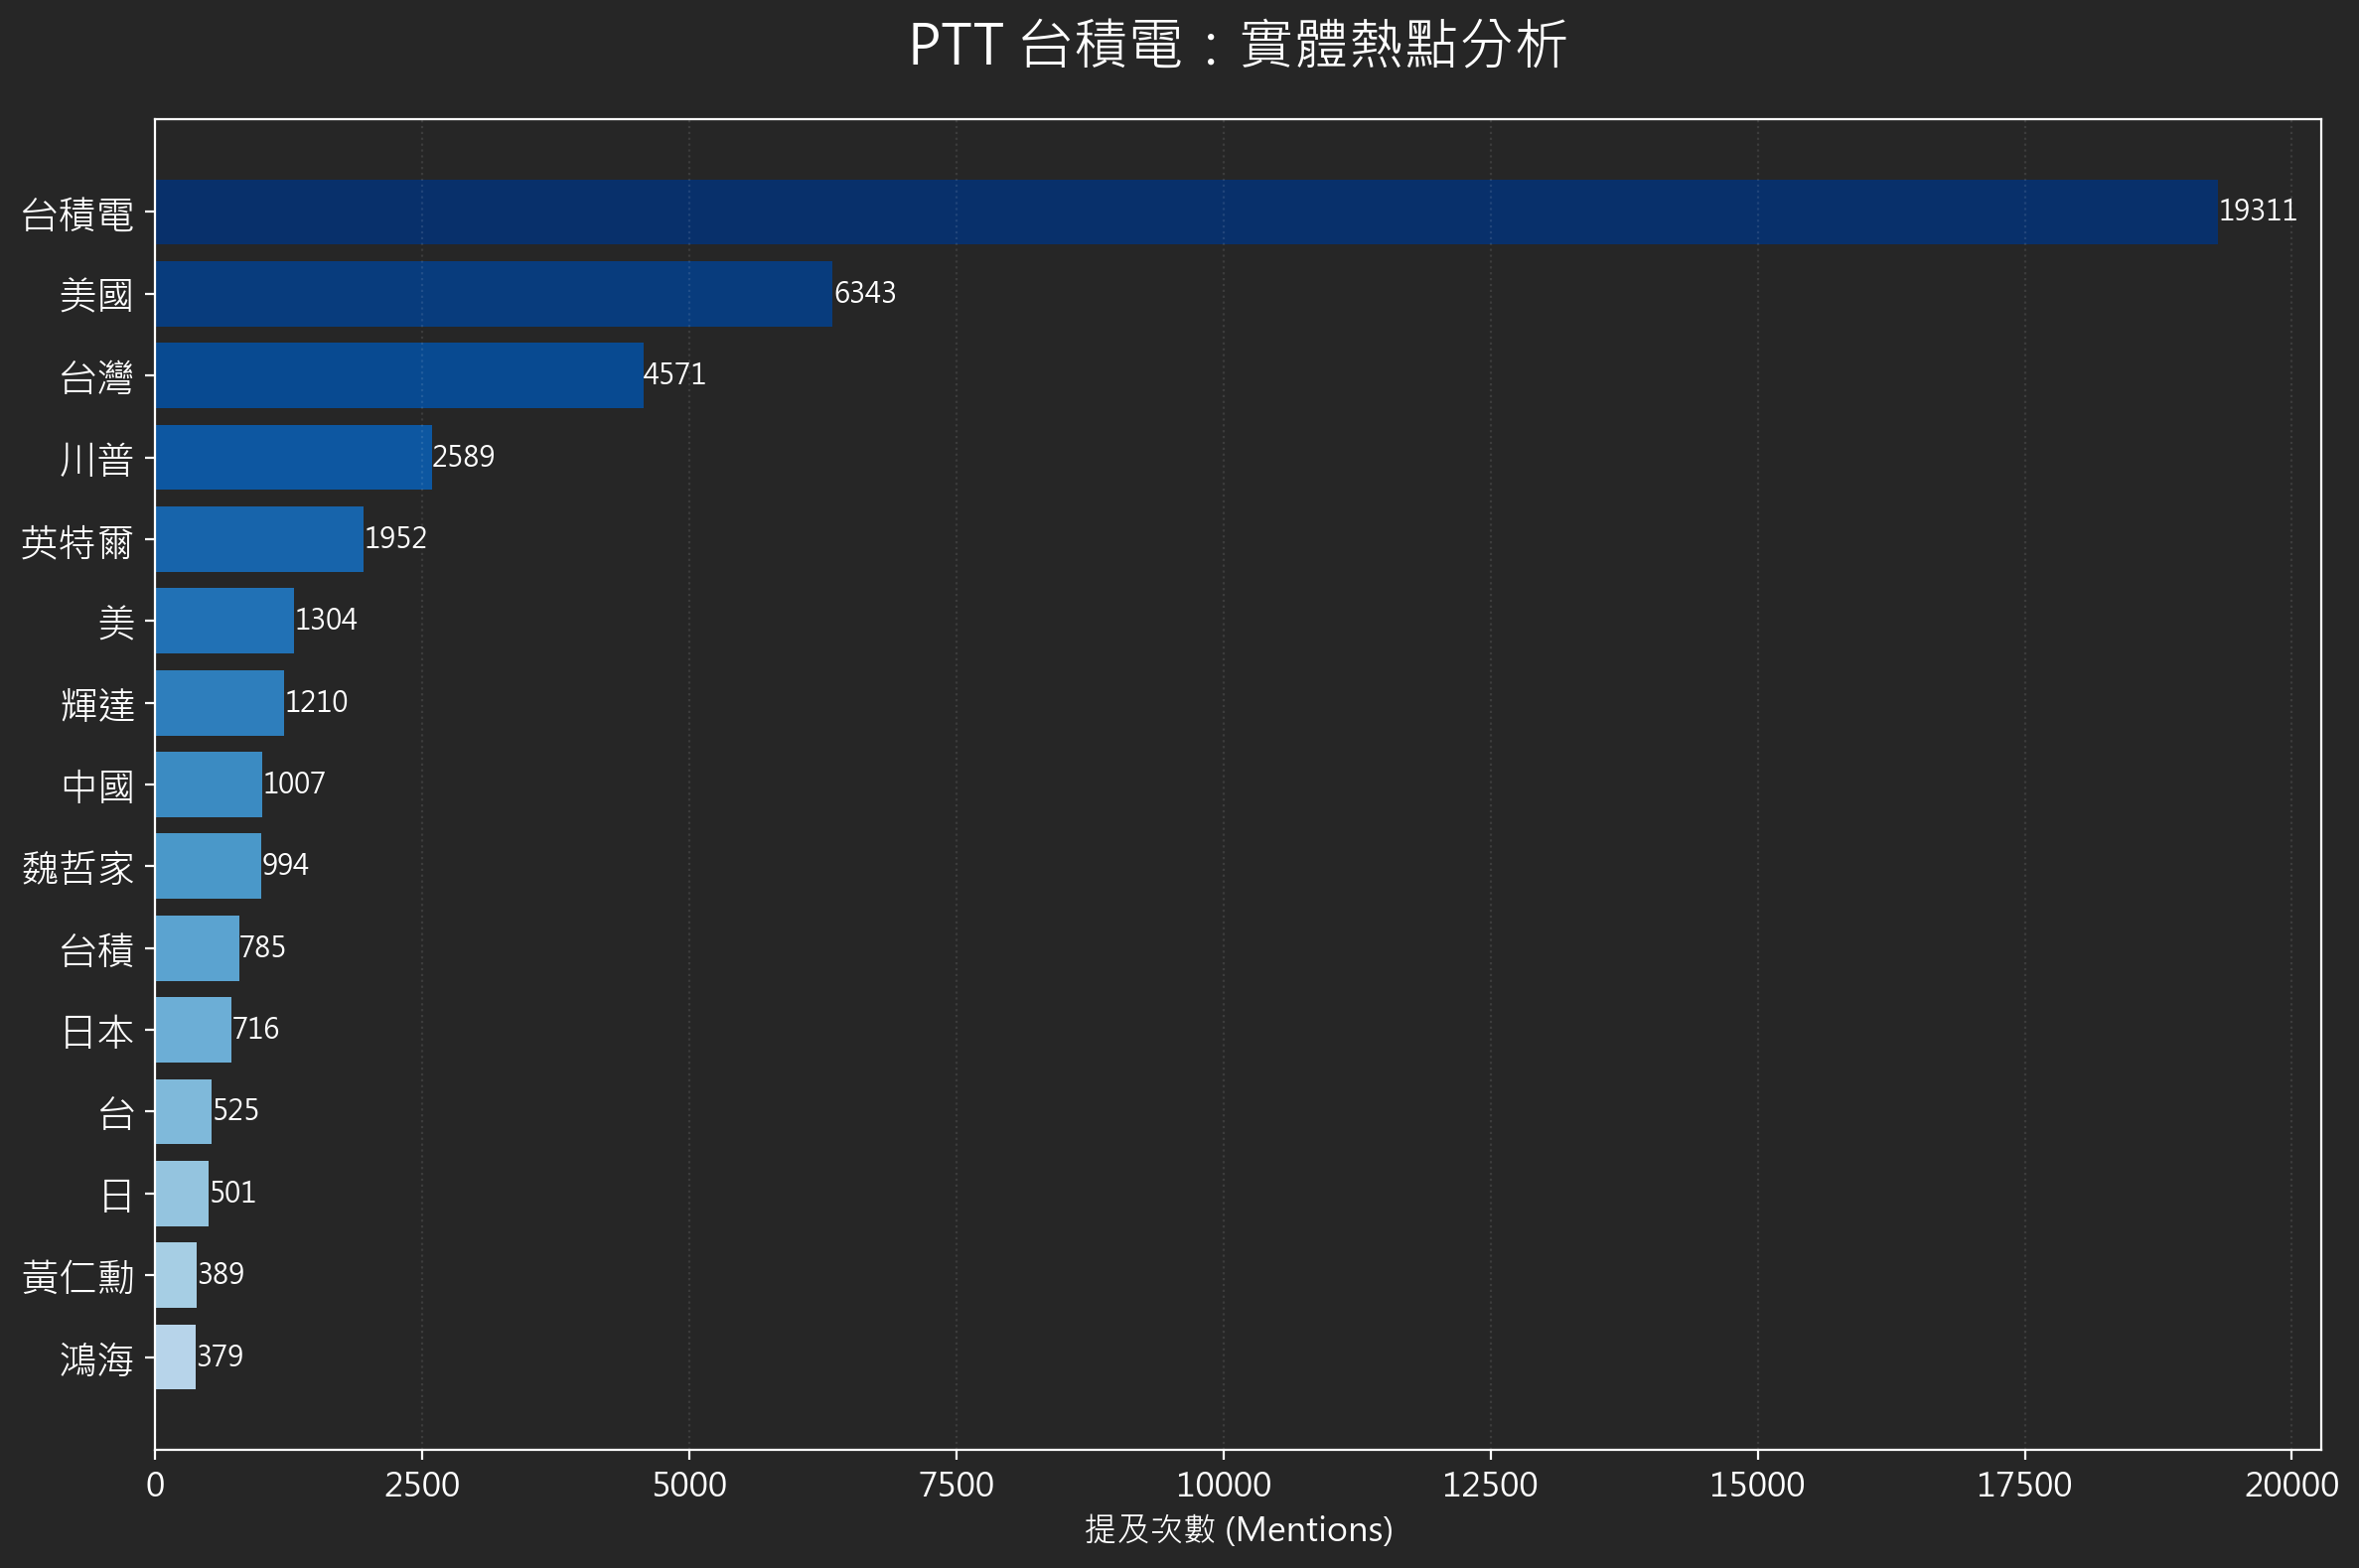

In [ ]:
target_types = ['PERSON', 'GPE', 'ORG']
hotspot_df = df_ner[df_ner['Type'].isin(target_types)].copy()

#統計出現次數 Top 15
top_entities = hotspot_df['Entity'].value_counts().head(15)

plt.figure(figsize=(12, 8), dpi=200, facecolor='#262626')
ax = plt.gca()
ax.set_facecolor('#262626')

colors = plt.cm.Blues_r([i/20 for i in range(15)])
bars = plt.barh(top_entities.index, top_entities.values, color=colors)

plt.title("PTT 台積電：實體熱點分析", fontsize=20, color='white', pad=20)
plt.xlabel("提及次數 (Mentions)", color='white', fontsize=12)
plt.tick_params(colors='white', labelsize=12)

# 反轉 y 軸，讓第 1 名在上面
plt.gca().invert_yaxis()

# 設定中文字體
for label in ax.get_yticklabels():
    label.set_color('white')
    label.set_fontsize(14)
# 顯示數值標籤在長條圖末端
for bar in bars:
    width = bar.get_width()
    plt.text(width + 5, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va='center', color='white', fontsize=10)

# 修正邊框
for spine in ax.spines.values():
    spine.set_color('white')

plt.grid(axis='x', linestyle=':', alpha=0.1, color='white')
plt.tight_layout()
plt.show()

#### (2) TF-IDF 熱門詞彙分析

將詞的資料合併回文章

In [ ]:
# 建立文章層級資料表 article_df
# 確保 word_df 有 doc 欄位
# word_df 目前是一個詞一列，這裡要合併回一篇文章一列
article_words = (
    word_df
    .dropna(subset=['word'])
    .groupby('doc')['word']
    .apply(lambda x: ' '.join(x.astype(str)))
    .reset_index(name='words')
)

base_cols = ['doc']

for col in ['artTitle', 'artDate', 'artContent']:
    if col in sent_df.columns:
        base_cols.append(col)

article_base = sent_df[base_cols].drop_duplicates(subset=['doc'])

article_df = pd.merge(article_base, article_words, on='doc', how='inner')

if 'artDate' in article_df.columns:
    article_df['artDate'] = pd.to_datetime(article_df['artDate'], errors='coerce')
print("文章層級資料筆數：", len(article_df))
article_df.head()

文章層級資料筆數： 3166


,doc,artTitle,artDate,artContent,words
0,0,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-16 14:12:24,我覺得台灣要拋棄一個思想\n\n就是儒家邪教的「萬般皆下品 惟有讀書高」\n\n很多賺錢的行...,台灣 拋棄 思想 儒家 邪教 萬般 下品 惟有 讀書 賺錢 行業 知識 並不 存在 書本 現...
1,1,[新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-15 06:38:27,作者: peterlin495 (專業果粉O'_'O) 看板: Gossiping\n標題:...,專業 果粉 工程師 高職 台積電 工作 年收 蘋果 日報 自由時報 參考 版規 下方 核准 ...
2,2,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2026-05-15 05:44:42,搭版問:\n\n今年初去了一批外包商的建廠人員\n\n招八晚五周休二日月入稅後5000鎂的\...,搭版問 今年 初去 一批 外包商 建廠 人員 招八晚 五周 休二日 月入 稅後鎂 知道 現在...
3,3,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2026-05-13 10:33:30,※ 引述《kudsaimoe (62632)》之銘言：\n: 吃原文 其實沒講到點上 就算全...,原文 講到 外食 能存 肯定 台灣 外食 一餐 週末 奢侈 點鎂 一餐 週算 租房 一點 車...
4,4,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2026-05-13 05:48:50,吃原文 其實沒講到點上 就算全部吃外食 都叫uber能存的錢肯定還是比台灣多 外食自己隨\n...,原文 講到 外食 能存 肯定 台灣 外食 一餐 週末 奢侈 點鎂 一餐 週算 租房 一點 車...


建立 TF-IDF 矩陣

In [ ]:
# TF-IDF 特徵萃取
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    max_features=100,
    token_pattern=r"(?u)\b\w+\b"
)

X_tfidf = tfidf_vectorizer.fit_transform(article_df['words'])

tfidf_words = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf_words
)

print("TF-IDF 矩陣大小：", tfidf_df.shape)
tfidf_df.head()

TF-IDF 矩陣大小： (3166, 100)


,三星,上漲,中國,交易,今天,今年,代工,企業,供應鏈,價格,...,進行,適用,量產,金額,關係,關稅,需求,預期,預計,魏哲家
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.495663,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.577758,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.145005,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.096828,0.000000,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.552625,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


計算計算每個詞的平均 TF-IDF，並找出 Top 20 關鍵字。可看到「美國」、「台灣」、「晶片」、「半導體」、「製程」等詞具有較高權重，基本上圍繞半導體產業、台積電發展，以及國際議題。這裡可以發現”原文”這兩個字的出現頻率不低，是因為在 stock 版的討論文章中，有關於台積電的文章中不少是引述新聞報導，造成此結果。

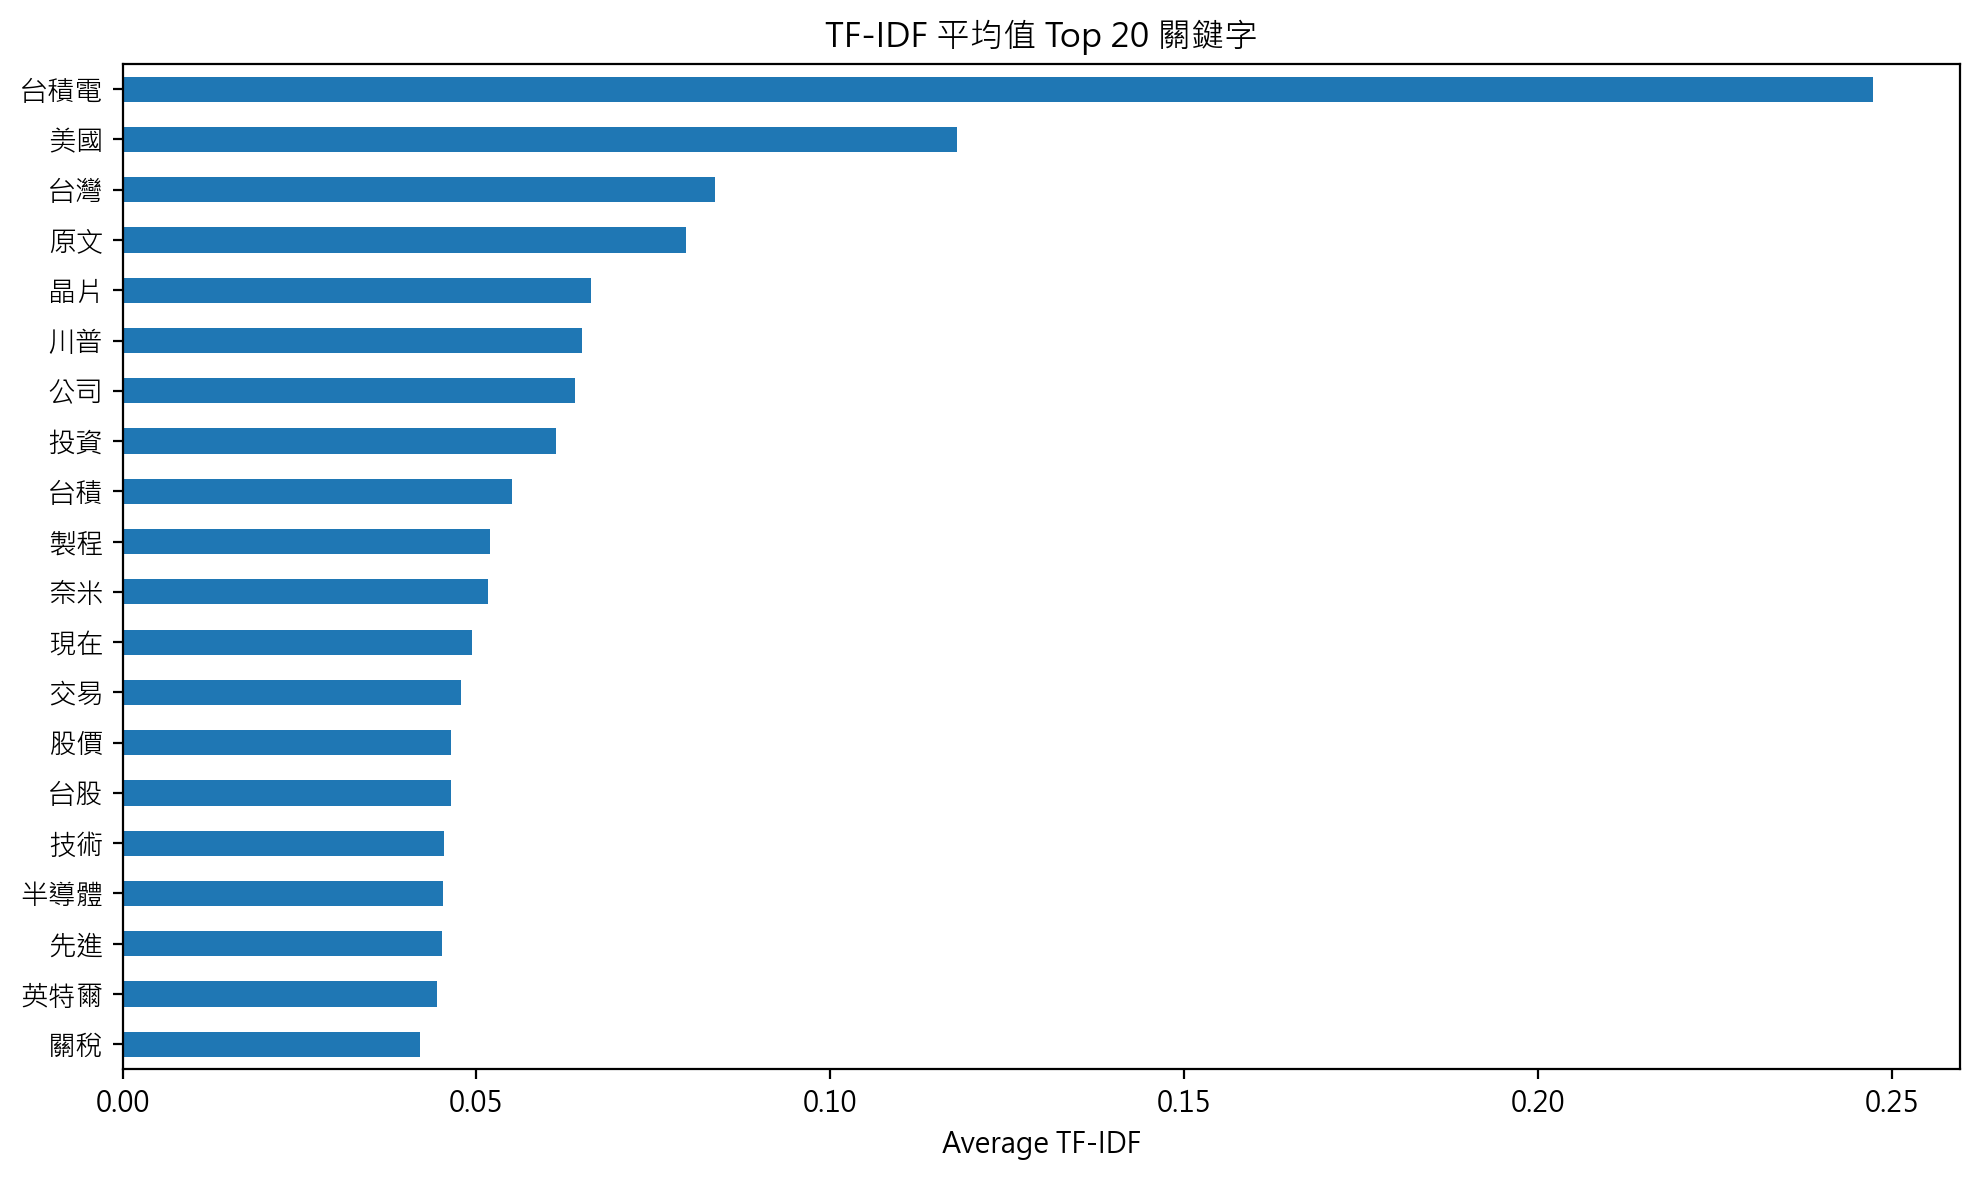

台積電    0.247290
美國     0.117904
台灣     0.083768
原文     0.079610
晶片     0.066246
川普     0.064950
公司     0.063919
投資     0.061271
台積     0.055084
製程     0.051945
奈米     0.051605
現在     0.049360
交易     0.047774
股價     0.046381
台股     0.046349
技術     0.045409
半導體    0.045294
先進     0.045128
英特爾    0.044354
關稅     0.042074
dtype: float64

In [ ]:
# TF-IDF 平均值 Top 詞彙

tfidf_mean = tfidf_df.mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6), dpi=200)
tfidf_mean.sort_values().plot(kind='barh')
plt.title("TF-IDF 平均值 Top 20 關鍵字")
plt.xlabel("Average TF-IDF")
plt.tight_layout()
plt.show()

tfidf_mean

建立 DTM

In [ ]:
# 建立 DTM 文件詞矩陣
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer(
    max_features=100,
    token_pattern=r"(?u)\b\w+\b"
)

X_count = count_vectorizer.fit_transform(article_df['words'])

dtm_words = count_vectorizer.get_feature_names_out()

dtm_df = pd.DataFrame(
    X_count.toarray(),
    columns=dtm_words
)

print("DTM 矩陣大小：", dtm_df.shape)
dtm_df.head()

DTM 矩陣大小： (3166, 100)


,三星,上漲,中國,交易,今天,今年,代工,企業,供應鏈,價格,...,進行,適用,量產,金額,關係,關稅,需求,預期,預計,魏哲家
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,2,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


進行 Bigram 分析

In [ ]:
# Bigram 雙詞分析
from nltk import ngrams
from collections import Counter

all_words = word_df['word'].dropna().astype(str).tolist()

bigram_list = list(ngrams(all_words, 2))

bigram_counter = Counter(bigram_list)

bigram_df = pd.DataFrame(
    bigram_counter.items(),
    columns=['bigram', 'count']
).sort_values('count', ascending=False)

bigram_df['bigram_text'] = bigram_df['bigram'].apply(lambda x: x[0] + '_' + x[1])

bigram_df.head(20)

,bigram,count,bigram_text
19406,"(心得, 評論)",1200,心得_評論
1603,"(先進, 製程)",1069,先進_製程
23492,"(原文, 發布)",847,原文_發布
13310,"(原文, 台積電)",840,原文_台積電
102132,"(交易, 數量)",736,交易_數量
1755,"(奈米, 製程)",733,奈米_製程
23493,"(發布, 記者)",681,發布_記者
102123,"(日期, 適用)",609,日期_適用
5850,"(台積電, 美國)",577,台積電_美國
1752,"(晶圓, 代工)",553,晶圓_代工


Bigram Top 20 視覺化。可以明顯發現”心得評論”、”原文發布”等新聞報導用字不少。同時財經公告的用字同樣不少，推測是因為 stock 版中經常大量討論公司財報或財經相關的訊息導致。

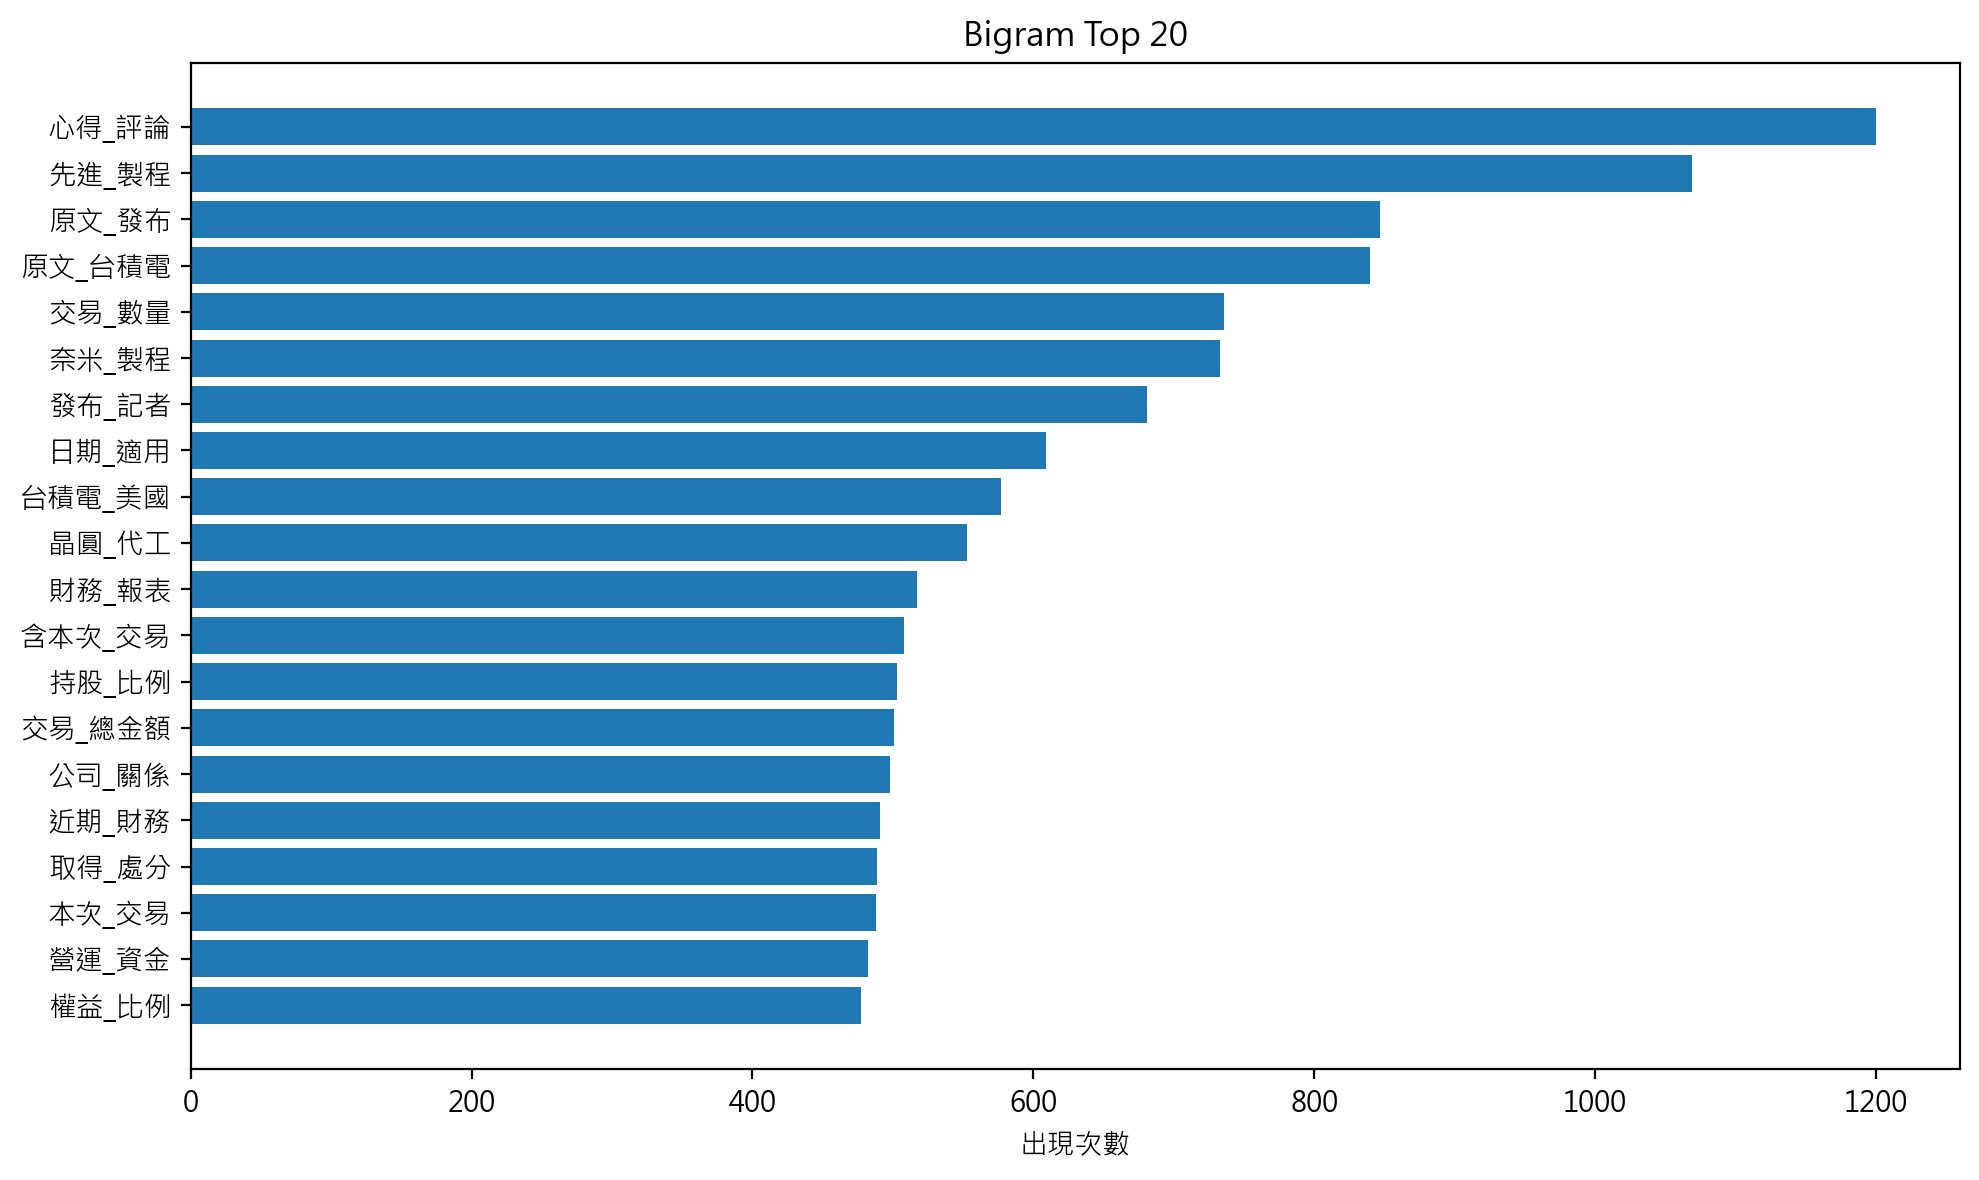

In [ ]:
#Bigram Top 20 視覺化
top_bigram = bigram_df.head(20)

plt.figure(figsize=(10, 6), dpi=200)
plt.barh(top_bigram['bigram_text'][::-1], top_bigram['count'][::-1])
plt.title("Bigram Top 20")
plt.xlabel("出現次數")
plt.tight_layout()
plt.show()

進行 Trigram 分析

In [ ]:
#  Trigram 三詞分析
trigram_list = list(ngrams(all_words, 3))

trigram_counter = Counter(trigram_list)

trigram_df = pd.DataFrame(
    trigram_counter.items(),
    columns=['trigram', 'count']
).sort_values('count', ascending=False)

trigram_df['trigram_text'] = trigram_df['trigram'].apply(
    lambda x: x[0] + '_' + x[1] + '_' + x[2]
)

trigram_df.head(20)

,trigram,count,trigram_text
26760,"(原文, 發布, 記者)",660,原文_發布_記者
128736,"(近期, 財務, 報表)",491,近期_財務_報表
128742,"(業主, 權益, 比例)",468,業主_權益_比例
128741,"(母公司, 業主, 權益)",460,母公司_業主_權益
128712,"(權利, 受限, 情形)",437,權利_受限_情形
128747,"(營運, 資金, 數額)",435,營運_資金_數額
128711,"(比例, 權利, 受限)",435,比例_權利_受限
128710,"(持股, 比例, 權利)",435,持股_比例_權利
128740,"(歸屬於, 母公司, 業主)",423,歸屬於_母公司_業主
128679,"(價格, 交易, 總金額)",423,價格_交易_總金額


Trigram Top 20 視覺化。能發現2元組的趨勢被放大，極大多數都是新聞報導，再來就是財經相關文字。這導致這類詞比較像是在反映資料格式，而非有意義的內容。排除這些文字後，比較有意義的就是跟美國有所關連。可能是因為與台積電赴美投資、關稅、晶片政策有關，導致相關文字出現次數不低。


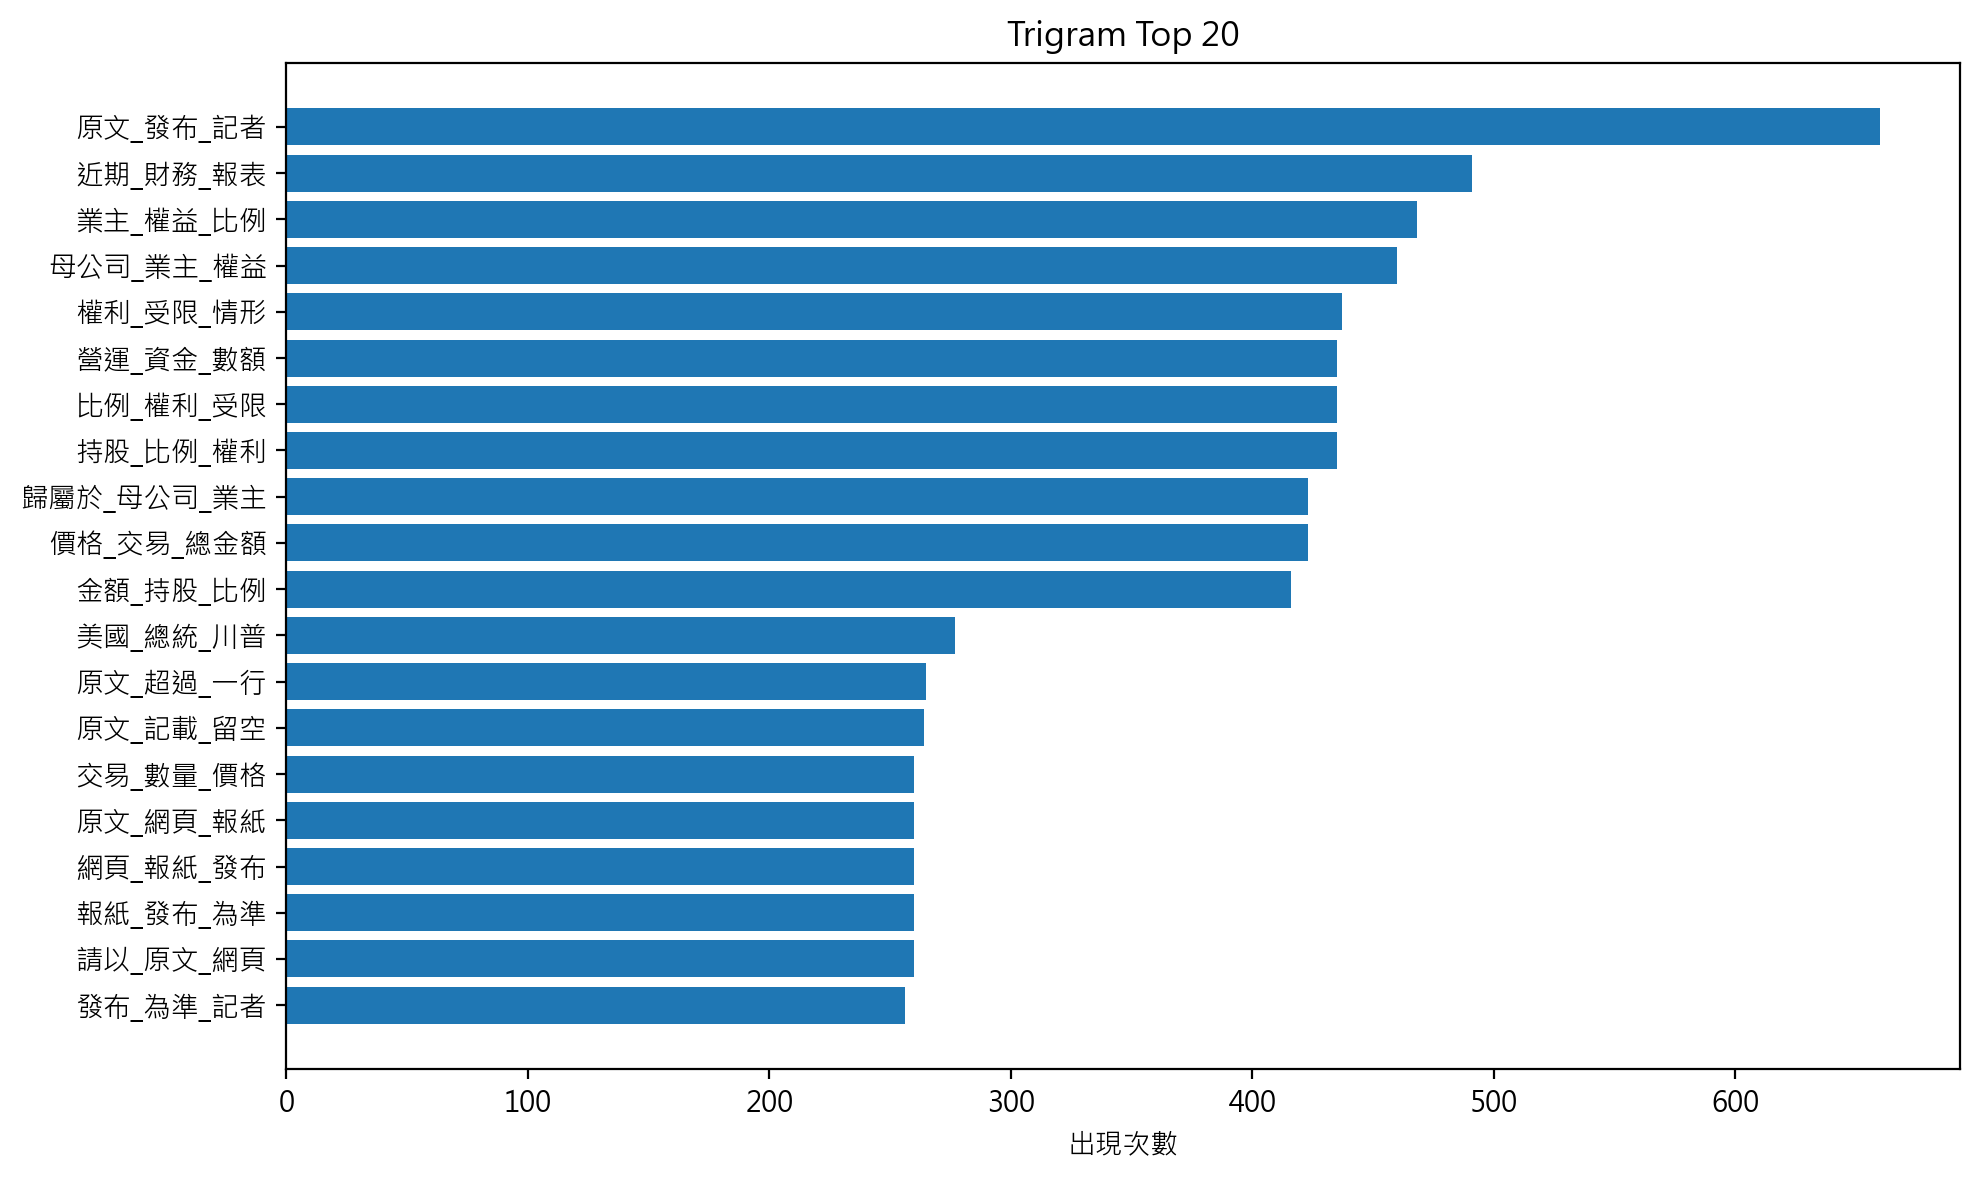

In [ ]:
#  Trigram Top 20 視覺化
top_trigram = trigram_df.head(20)

plt.figure(figsize=(10, 6), dpi=200)
plt.barh(top_trigram['trigram_text'][::-1], top_trigram['count'][::-1])
plt.title("Trigram Top 20")
plt.xlabel("出現次數")
plt.tight_layout()
plt.show()

### 4. 語意相似度分析

#### (1) 詞彙相關性

##### a. DTM

使用 DTM 計算詞與詞之間的相關性，可發現其中包含許多公告/交易格式詞，如「交易、有價證券、情形、比例、適用」。可能的原因可能與前面熱門詞彙所發現的現象一樣，都是因為文章有特定的格式。

In [ ]:
#  Pairwise Correlation 詞彙相關性
import numpy as np

# 使用 DTM 計算詞與詞之間的相關性
word_corr = dtm_df.corr()

# 建立遮罩，排除自己跟自己的相關性
mask = ~np.eye(word_corr.shape[0], dtype=bool)

# 轉成長表格
corr_pairs = (
    word_corr
    .where(mask)
    .stack()
    .reset_index()
)

corr_pairs.columns = ['word1', 'word2', 'correlation']

# 避免 A-B 與 B-A 重複
corr_pairs['pair'] = corr_pairs.apply(
    lambda x: tuple(sorted([x['word1'], x['word2']])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates('pair').drop(columns='pair')

# 篩選相關性高的詞組
high_corr_pairs = corr_pairs[corr_pairs['correlation'] >= 0.3].sort_values(
    'correlation',
    ascending=False
)

high_corr_pairs.head(30)

,word1,word2,correlation
351,交易,有價證券,0.979441
3717,情形,有價證券,0.974419
5501,有價證券,比例,0.969220
333,交易,情形,0.965528
3719,情形,比例,0.964456
387,交易,適用,0.959082
353,交易,比例,0.957999
5535,有價證券,適用,0.954771
346,交易,日期,0.952807
4808,數量,比例,0.944195


畫詞彙相關性網路圖，在相關係數 0.3 以上的詞彙中，可發現詞彙多集中在財務、證券交易與公告揭露相關主題

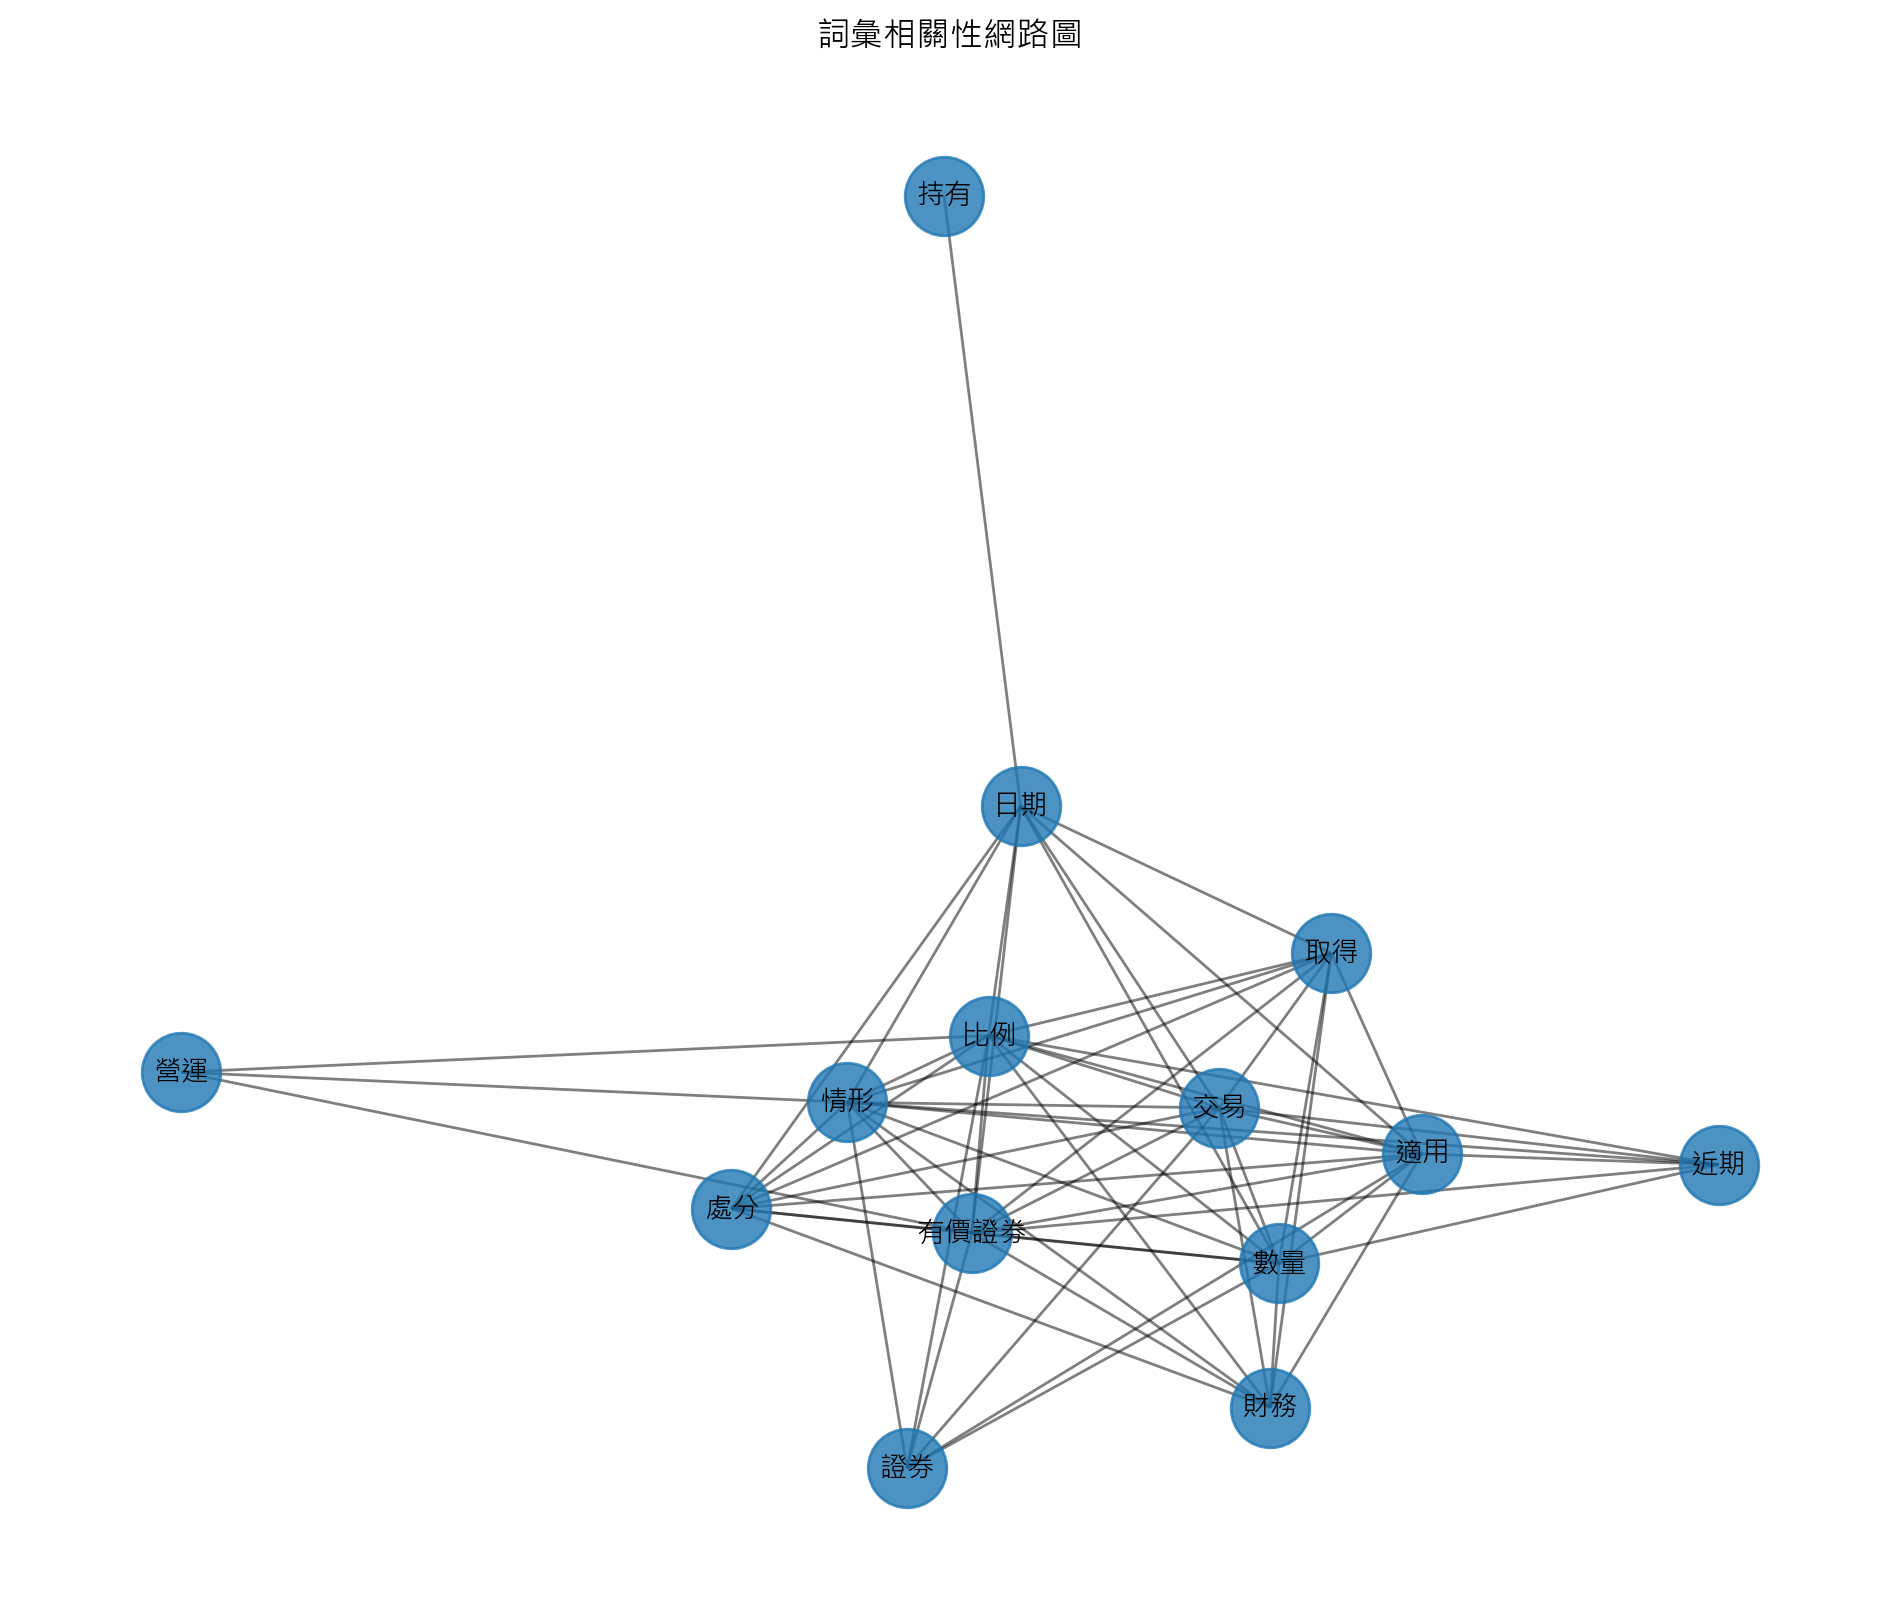

In [ ]:
#  詞彙相關性網路圖
import networkx as nx
corr_threshold = 0.3

edges_df = high_corr_pairs[high_corr_pairs['correlation'] >= corr_threshold].head(60)

G = nx.Graph()

for _, row in edges_df.iterrows():
    G.add_edge(
        row['word1'],
        row['word2'],
        weight=row['correlation']
    )

plt.figure(figsize=(12, 10), dpi=200)

pos = nx.spring_layout(G, k=0.5, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=800,
    alpha=0.8
)

nx.draw_networkx_edges(
    G,
    pos,
    width=1,
    alpha=0.5
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_family='Microsoft JhengHei'
)

plt.title("詞彙相關性網路圖")
plt.axis('off')
plt.show()

##### b. Word2Vec


In [ ]:
# 安裝需要的套件（執行一次即可）
# !pip install -U sentence-transformers
# !pip install gensim==4.3.3
# !pip install ckip_transformers
# !pip install bertopic
# !pip install hdbscan

In [ ]:
import numpy as np
import torch
import multiprocessing
from collections import defaultdict

from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec

from sentence_transformers import SentenceTransformer, util
from transformers import (
    BertTokenizerFast,
    AutoModelForTokenClassification,
    pipeline as hf_pipeline,
)
from ckip_transformers.nlp import CkipNerChunker

from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from bertopic.vectorizers import ClassTfidfTransformer
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import plotly.express as px


用台積電 PTT 語料（`word_df`，前面已斷詞）自行訓練 Word2Vec，
探索「台積電討論圈」的詞彙語意空間。

In [ ]:
# 準備訓練語料：以 doc 為單位，每篇文章的詞彙串成一個 list
# word_df 是前面斷詞後的長表格，欄位有 'doc' 與 'word'
w2v_corpus = word_df.groupby('doc')['word'].apply(list).tolist()

print(f"語料篇數：{len(w2v_corpus)}")
print(f"範例（前5詞）：{w2v_corpus[0][:5]}")

語料篇數：3166
範例（前5詞）：['台灣', '拋棄', '思想', '儒家', '邪教']


In [ ]:
# 建立 bigram
bigram = Phrases(w2v_corpus, min_count=5, threshold=100)
bigram_phraser = Phraser(bigram)
w2v_sents = [bigram_phraser[sent] for sent in w2v_corpus]

# 訓練 Word2Vec
cores = multiprocessing.cpu_count()

w2v_model = Word2Vec(
    w2v_sents,
    min_count=10,      # 出現少於10次的詞忽略
    window=5,          # 左右各5個詞的上下文
    vector_size=128,   # 向量維度
    sg=1,              # Skip-gram
    epochs=30,
    workers=cores - 1,
    seed=42,
)

print(f"詞彙量：{len(w2v_model.wv)}")

INFO:gensim.models.phrases:collecting all words and their counts
INFO:gensim.models.phrases:PROGRESS: at sentence #0, processed 0 words and 0 word types
INFO:gensim.models.phrases:collected 349570 token types (unigram + bigrams) from a corpus of 615852 words and 3166 sentences
INFO:gensim.models.phrases:merged Phrases<349570 vocab, min_count=5, threshold=100, max_vocab_size=40000000>
INFO:gensim.utils:Phrases lifecycle event {'msg': 'built Phrases<349570 vocab, min_count=5, threshold=100, max_vocab_size=40000000> in 0.90s', 'datetime': '2026-06-14T15:53:10.526948', 'gensim': '4.3.3', 'python': '3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.26200-SP0', 'event': 'created'}
INFO:gensim.models.phrases:exporting phrases from Phrases<349570 vocab, min_count=5, threshold=100, max_vocab_size=40000000>
INFO:gensim.utils:FrozenPhrases lifecycle event {'msg': 'exported FrozenPhrases<1957 phrases, min_count=5, threshold=100> from Phrases<349570 voc

詞彙量：6810


查詢幾個語意相近詞。查詢結果中「台積電」的相近詞並不理想，出現太多記者資訊，沒有提供有意義的結果；「薪水」、「工程師」、「股票」、「離職」 的相近詞結果則相對合理，但仍然有語意不明或是斷詞不正確的情況。


In [ ]:
# 探索語意相近詞
test_words = ['台積電', '薪水', '工程師', '股票', '離職']

for w in test_words:
    if w in w2v_model.wv:
        similar = w2v_model.wv.most_similar(w, topn=8)
        print(f"\n【{w}】最相近的詞：")
        for word, score in similar:
            print(f"  {word}  ({score:.4f})")
    else:
        print(f"\n【{w}】不在詞彙表中")


【台積電】最相近的詞：
  呂承哲_綜合  (0.5761)
  陳麗珠_核稿  (0.5597)
  原文  (0.5407)
  美觀  (0.5342)
  呂承哲_台北  (0.5340)
  高佳菁_核稿  (0.5221)
  台積  (0.5210)
  積電  (0.5184)

【薪水】最相近的詞：
  水電工  (0.5560)
  加班  (0.5091)
  日幣  (0.4739)
  年資  (0.4712)
  加薪  (0.4698)
  月薪  (0.4633)
  碩士  (0.4620)
  薪資  (0.4619)

【工程師】最相近的詞：
  戈一平  (0.5557)
  吳秉駿_戈一平  (0.5414)
  調派  (0.5191)
  陳姓_工程師  (0.5150)
  受訓  (0.5088)
  台籍  (0.5033)
  年薪  (0.4997)
  韋傑  (0.4983)

【股票】最相近的詞：
  抵稅  (0.5305)
  理財  (0.5089)
  一股  (0.4973)
  買入  (0.4762)
  股神_巴菲特  (0.4729)
  收盤價  (0.4702)
  +.  (0.4698)
  價位  (0.4690)

【離職】最相近的詞：
  任職  (0.5451)
  唯仁  (0.5404)
  跳槽  (0.5136)
  陳姓_工程師  (0.4994)
  工程師  (0.4826)
  同事  (0.4764)
  將至  (0.4679)
  陳培  (0.4667)


在 t-SNE 視覺化詞向量分布圖中，可觀察到多數詞彙集中於中央區域，顯示詞向量之間的語意分布尚未形成明顯分群，代表模型所學到的語意空間仍存在一定程度的混雜。

In [ ]:
# t-SNE 視覺化詞向量分布
vocab = list(w2v_model.wv.key_to_index.keys())
# 隨機抽 300 個詞
np.random.seed(42)
sample_words = np.random.choice(vocab, min(300, len(vocab)), replace=False).tolist()

# 取得向量
vecs = np.array([w2v_model.wv[w] for w in sample_words])

# t-SNE 降維
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
vecs_2d = tsne.fit_transform(vecs)

import pandas as pd
tsne_df = pd.DataFrame({
    'x': vecs_2d[:, 0],
    'y': vecs_2d[:, 1],
    'word': sample_words
})

fig = px.scatter(
    tsne_df, x='x', y='y', text='word',
    title='Word2Vec 詞向量 t-SNE 分布（台積電 PTT 語料）',
    width=900, height=600
)
fig.update_traces(textposition='top center', marker=dict(size=5, opacity=0.7))
fig.update_layout(font=dict(size=10))
fig.show()

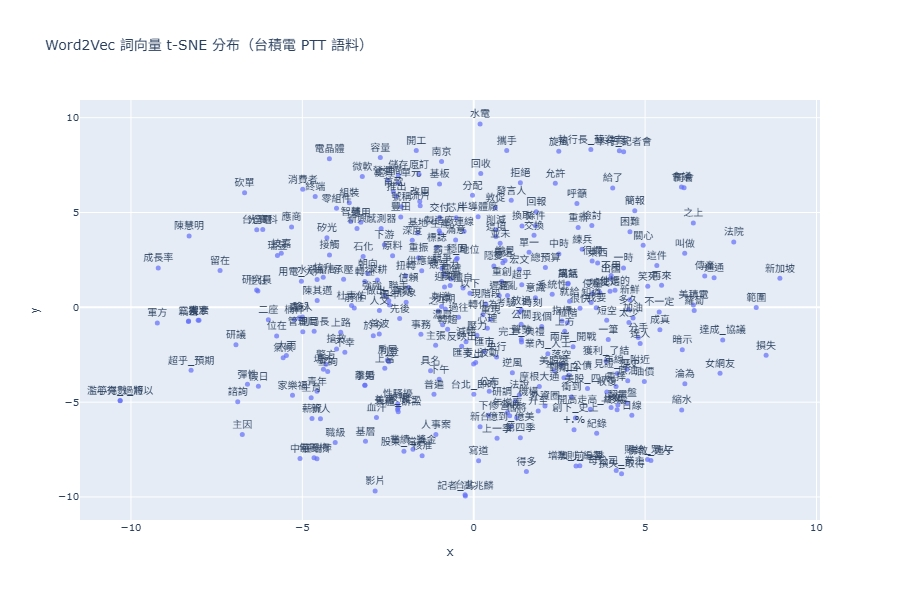

#### (2) 文章相似度

##### a. tfidf

使用 tfidf 計算文章相似度

In [ ]:
# 文章相似度 Cosine Similarity

from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X_tfidf)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=article_df['doc'],
    columns=article_df['doc']
)

print("文章相似度矩陣大小：", similarity_df.shape)
similarity_df.head()

文章相似度矩陣大小： (3166, 3166)


doc,0,1,2,3,4,5,6,7,8,9,...,3156,3157,3158,3159,3160,3161,3162,3163,3164,3165
doc,,,,,,,,,,,,,,,,,,,,,
0,1.000000,0.035267,0.000000,0.372497,0.379591,0.337353,0.282316,0.293398,0.736188,0.087190,...,0.069862,0.049511,0.025277,0.000000,0.074947,0.000000,0.024725,0.000000,0.059572,0.040233
1,0.035267,1.000000,0.226107,0.235200,0.239680,0.235658,0.271237,0.345682,0.121080,0.572352,...,0.307387,0.088500,0.106334,0.104670,0.097085,0.073763,0.082029,0.106279,0.110795,0.071681
2,0.000000,0.226107,1.000000,0.000000,0.000000,0.262308,0.040527,0.027442,0.072404,0.000000,...,0.071879,0.079064,0.172300,0.030193,0.056764,0.088363,0.168536,0.000000,0.203036,0.000000
3,0.372497,0.235200,0.000000,1.000000,0.981310,0.724608,0.430704,0.461877,0.455047,0.077234,...,0.278721,0.100064,0.057594,0.029087,0.123111,0.000000,0.056336,0.165174,0.080425,0.159020
4,0.379591,0.239680,0.000000,0.981310,1.000000,0.635882,0.353107,0.422037,0.426645,0.078705,...,0.262797,0.094446,0.051009,0.029641,0.117863,0.000000,0.049894,0.086153,0.075922,0.162048


列出文章標題並進一步檢視後可以發現，這類文章多由同一位用戶依照固定格式發布，內容主要引用公開資訊觀測站公告，僅更換公司名稱、證券名稱、交易日期、交易數量、金額及處分損益等欄位，因此文章間的相似度極高。並且這種依照一定格式的文章也是前面的分析中，導致不少問題的原因。

In [ ]:
# 找出最相似文章配對
sim_pairs = []

for i in range(len(similarity_matrix)):
    for j in range(i + 1, len(similarity_matrix)):
        sim_pairs.append({
            'doc1': article_df.iloc[i]['doc'],
            'doc2': article_df.iloc[j]['doc'],
            'similarity': similarity_matrix[i, j]
        })

sim_pairs_df = pd.DataFrame(sim_pairs).sort_values(
    'similarity',
    ascending=False
)

sim_pairs_df.head(20)

,doc1,doc2,similarity
2544990,945,1051,1.0
2484763,918,1115,1.0
5003065,3046,3057,1.0
5003061,3046,3053,1.0
2674288,1004,1139,1.0
3823839,1625,1840,1.0
2484711,918,1063,1.0
5001037,3030,3053,1.0
5001041,3030,3057,1.0
3816124,1620,1835,1.0


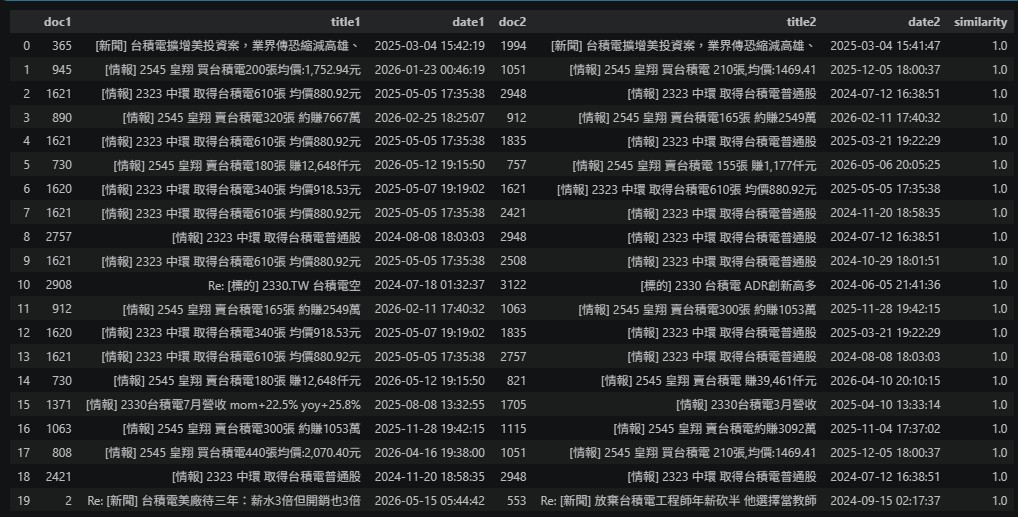

其中一篇文章的實際圖片，內容依照 stock 板規撰寫

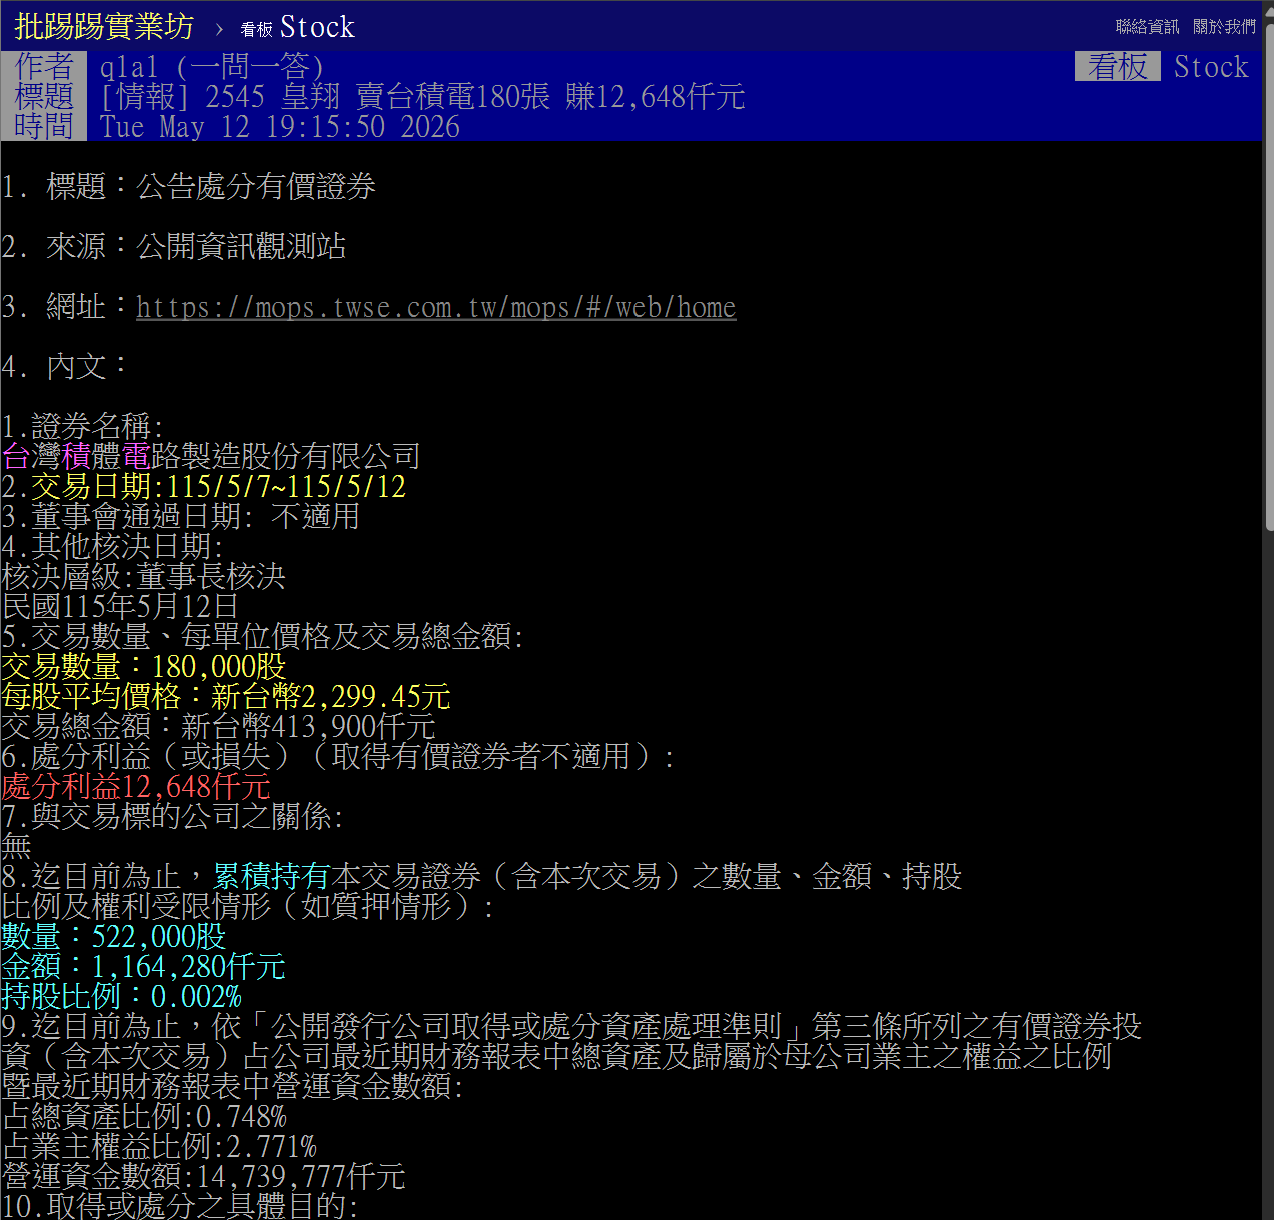

##### b. BERT Embedding



用 `bert-base-chinese` 把每篇文章編碼成向量，
輸入任一篇文章（或自訂查詢句），找出語意最相近的 Top-K 文章。

In [ ]:
# 載入中文 BERT
bert_ch = SentenceTransformer('google-bert/bert-base-chinese')
bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})
print("BERT 模型載入完成")

INFO:sentence_transformers.base.model:No device provided, using cpu
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-chinese/resolve/main/modules.json "HTTP/1.1 404 Not Found"
INFO:sentence_transformers.base.model:No modules.json found for google-bert/bert-base-chinese, initializing a new SentenceTransformer model.
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-chinese/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-chinese/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-chinese/8f23c25b06e129b6c986331a13d8d025a92cf0ea/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-chinese/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-chinese/resolve/main/preproces

BERT 模型載入完成


計算 BERT embeddings

In [ ]:
# 準備文章層級的資料
# clear_df 是前面前處理後保留 artTitle、artContent 的 dataframe
article_corpus = clear_df.copy().reset_index(drop=True)

# 將標題 + 內文合併，截斷到前 512 個字（BERT 限制）
article_corpus['full_text'] = (
    article_corpus['artTitle'].fillna('') + '。' +
    article_corpus['artContent'].fillna('')
).str[:512]

# 計算全部文章的 embeddings
print(f"共 {len(article_corpus)} 篇文章，開始計算 embeddings...")
corpus_embeddings = bert_ch.encode(
    article_corpus['full_text'].tolist(),
    convert_to_tensor=True,
    batch_size=32,
    show_progress_bar=True
)
print("Embeddings 計算完成，shape:", corpus_embeddings.shape)

共 3166 篇文章，開始計算 embeddings...


Batches:   0%|          | 0/99 [00:00<?, ?it/s]

Embeddings 計算完成，shape: torch.Size([3166, 768])


查詢指定文章的最相似的 Top-5 文章，分別為


1. Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1
2. Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍
3. [討論] 台積電成功是無數工程師辛苦輪班換來的嗎

查詢結果中相似度皆高於 0.97，顯示文章間語意非常接近，但也可能是受到共同關鍵詞「台積電」與相似新聞格式影響。此外部分相似文章標題重複出現，可能是因為ptt有回文、轉貼文導致。



In [ ]:
# 以指定文章為查詢，找最相似的 Top-5 文章
def find_similar_articles(query_idx, top_k=5):
    """輸入文章索引，回傳最相近的 top_k 篇"""
    query_embedding = corpus_embeddings[query_idx]
    cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k + 1)  # +1 排除自身

    print(f"\n查詢文章：{article_corpus['artTitle'].iloc[query_idx]}")
    print("─" * 60)
    print("最相似的文章：")
    count = 0
    for score, idx in zip(top_results[0], top_results[1]):
        if idx.item() == query_idx:
            continue  # 跳過自身
        print(f"  [{count+1}] {article_corpus['artTitle'].iloc[idx.item()]}  (相似度: {score:.4f})")
        count += 1
        if count >= top_k:
            break

# 分別以第 0、5、10 篇為例
for q in [0, 5, 10]:
    find_similar_articles(q, top_k=5)


查詢文章：Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1
────────────────────────────────────────────────────────────
最相似的文章：
  [1] Re: [新聞] 半夜被叫去工作！美員工怨台積電「血汗  (相似度: 0.9800)
  [2] Re: [新聞] 半夜被叫去工作！美員工怨台積電「血汗  (相似度: 0.9776)
  [3] Re: [新聞] 美國準商務部長：台積電利用美國 從美手  (相似度: 0.9773)
  [4] Re: [新聞] 台積電2奈米機密外洩案災情慘重 上千張  (相似度: 0.9764)
  [5] Re: [新聞] 半夜被叫去工作！美員工怨台積電「血汗  (相似度: 0.9756)

查詢文章：Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍
────────────────────────────────────────────────────────────
最相似的文章：
  [1] Re: [新聞] 半夜被叫去工作！美員工怨台積電「血汗  (相似度: 0.9743)
  [2] Re: [請益] 富邦MA 台積電 智慧製造offer 選擇  (相似度: 0.9728)
  [3] Re: [請益] 3兆對台積電應該還好吧 大家怎麼那麼悲觀  (相似度: 0.9719)
  [4] Re: [新聞] 不只台積電受重傷？川普「磨刀霍霍」 對  (相似度: 0.9709)
  [5] Re: [請益] 夜盤台積電ADR-7%明天該如何面對  (相似度: 0.9705)

查詢文章：[討論] 台積電成功是無數工程師辛苦輪班換來的嗎
────────────────────────────────────────────────────────────
最相似的文章：
  [1] [請益] 台積電的股價是一堆工程師輪班換來的嗎  (相似度: 0.9872)
  [2] Re: [討論] 在台積電工作是不是真的沒有這麼光鮮  (相似度: 0.9799)
  [3] [請益] 保全對台積電跟科技大廠是超重要的存在嗎  (相似度: 0.9792)
  [4] [討論] 台積電技術外流也很難生產出台積的晶片嗎  (相似度: 0.9785)
  [5] Re

自訂查詢句搜尋相關文章。

1. 台積電薪資待遇福利如何
2. 美國設廠移轉海外
3. 工程師職涯發展晉升

查詢「台積電薪資待遇福利如何」與「美國設廠移轉海外」時，都能找到不錯的結果。不過查詢「工程師職涯發展晉升」時，結果多偏向職缺、徵才與薪酬資訊，較少直接對應升遷或職涯發展，可能代表語料中相關文章較少，或模型將職涯發展與求職招募語境視為相近。




In [ ]:
# 自訂查詢句搜尋相關文章
def search_by_query(query_text, top_k=5):
    """輸入任意查詢句，找最相似的 top_k 篇文章"""
    query_embedding = bert_ch.encode(query_text, convert_to_tensor=True)
    cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
    top_results = torch.topk(cos_scores, k=top_k)

    print(f"\n查詢：{query_text}")
    print("─" * 60)
    for i, (score, idx) in enumerate(zip(top_results[0], top_results[1])):
        print(f"  [{i+1}] {article_corpus['artTitle'].iloc[idx.item()]}  (相似度: {score:.4f})")

# 測試幾個查詢
search_by_query("台積電薪資待遇福利如何")
search_by_query("美國設廠移轉海外")
search_by_query("工程師職涯發展晉升")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


查詢：台積電薪資待遇福利如何
────────────────────────────────────────────────────────────
  [1] [新聞] 【台積電薪資解碼】營收獲利逐季創高！  (相似度: 0.8038)
  [2] [新聞] 台積電1990年徵才廣告曝！他嫌起薪低  (相似度: 0.8034)
  [3] [新聞] 台積電薪資高、壓力大！網疑惑「為何不  (相似度: 0.8021)
  [4] [新聞] 輝達 台積電 聯發科薪資比一比  (相似度: 0.7999)
  [5] [新聞] 台積電熊本廠待遇曝光！3個月送機票 1年  (相似度: 0.7991)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


查詢：美國設廠移轉海外
────────────────────────────────────────────────────────────
  [1] Re: [新聞] 台積電宣布「投資美國1000億美元」 駐美  (相似度: 0.7906)
  [2] Re: [新聞] 台積電又出事？外媒爆川普翻臉不認帳　  (相似度: 0.7889)
  [3] [請益] 台積電外資佔多數為什麼川普認為被偷走？  (相似度: 0.7874)
  [4] [新聞] 美國製造代價高昂，台積電美廠獲利大縮水  (相似度: 0.7863)
  [5] [新聞] 獨家》台積電美國廠派大批工程師來台 培  (相似度: 0.7863)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


查詢：工程師職涯發展晉升
────────────────────────────────────────────────────────────
  [1] [情報] 目前台積電在亞利桑那的職缺資訊  (相似度: 0.7708)
  [2] [新聞] 台積電徵「語文專才」待遇曝光！網一看：  (相似度: 0.7691)
  [3] [新聞] 台積電員工薪酬中位數250萬 離職率3.7%  (相似度: 0.7649)
  [4] [徵才] 2026年德國台積電ESMC-廠務二次配工程師  (相似度: 0.7623)
  [5] [新聞] 台積電2026年預計招8千名員工 碩士工程師  (相似度: 0.7611)


### 5. 監督式文章分類模型

檢查可用於分類的目標欄位，用文章類別

In [ ]:
# 檢查可用於分類的目標欄位
print("df 欄位：")
print(df.columns.tolist())

possible_label_cols = ['artCatagory', 'label', 'sentiment', 'category', 'movieType']

for col in possible_label_cols:
    if col in df.columns:
        print(f"\n可能的分類目標欄位：{col}")
        print(df[col].value_counts())

df 欄位：
['system_id', 'artUrl', 'artTitle', 'artDate', 'artPoster', 'artCatagory', 'artContent', 'artComment', 'insertedDate', 'dataSource']

可能的分類目標欄位：artCatagory
artCatagory
Stock       2455
Tech_Job     711
Name: count, dtype: int64


建立分類資料集，並依照 artCatagory 的分類比例去切資料

In [ ]:
# 建立分類資料集
label_col = 'artCatagory'

if label_col not in df.columns:
    raise ValueError(f"找不到 {label_col} 欄位，請先確認 df.columns")

# 從原始 df 取 doc 與 label
label_df = df.copy()
label_df['doc'] = label_df.index

label_df = label_df[['doc', label_col]].dropna()

classification_df = pd.merge(
    article_df,
    label_df,
    on='doc',
    how='inner'
)

classification_df = classification_df.dropna(subset=['words', label_col])

print("分類資料筆數：", len(classification_df))
print(classification_df[label_col].value_counts())

classification_df.head()
# 訓練集 / 測試集切分

from sklearn.model_selection import train_test_split

X = classification_df['words']
y = classification_df[label_col]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("訓練集：", len(X_train))
print("測試集：", len(X_test))

分類資料筆數： 3166
artCatagory
Stock       2455
Tech_Job     711
Name: count, dtype: int64
訓練集： 2216
測試集： 950


訓練 CountVectorizer + Logistic Regression。  
在Stock類別的precision 0.94、recall 0.90，代表模型很擅長辨識股票類文章。而Tech_Job 則相對較弱，此結果可能是因為資料類別不平衡有關

In [ ]:
# CountVectorizer + Logistic Regression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

count_lr_model = Pipeline([
    ('vectorizer', CountVectorizer(
        max_features=1000,
        token_pattern=r"(?u)\b\w+\b"
    )),
    ('classifier', LogisticRegression(
        max_iter=3000,
        class_weight='balanced'
    ))
])

count_lr_model.fit(X_train, y_train)

y_pred_count_lr = count_lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_count_lr))
print(classification_report(y_test, y_pred_count_lr))

Accuracy: 0.8778947368421053
              precision    recall  f1-score   support

       Stock       0.94      0.90      0.92       737
    Tech_Job       0.70      0.79      0.74       213

    accuracy                           0.88       950
   macro avg       0.82      0.85      0.83       950
weighted avg       0.88      0.88      0.88       950



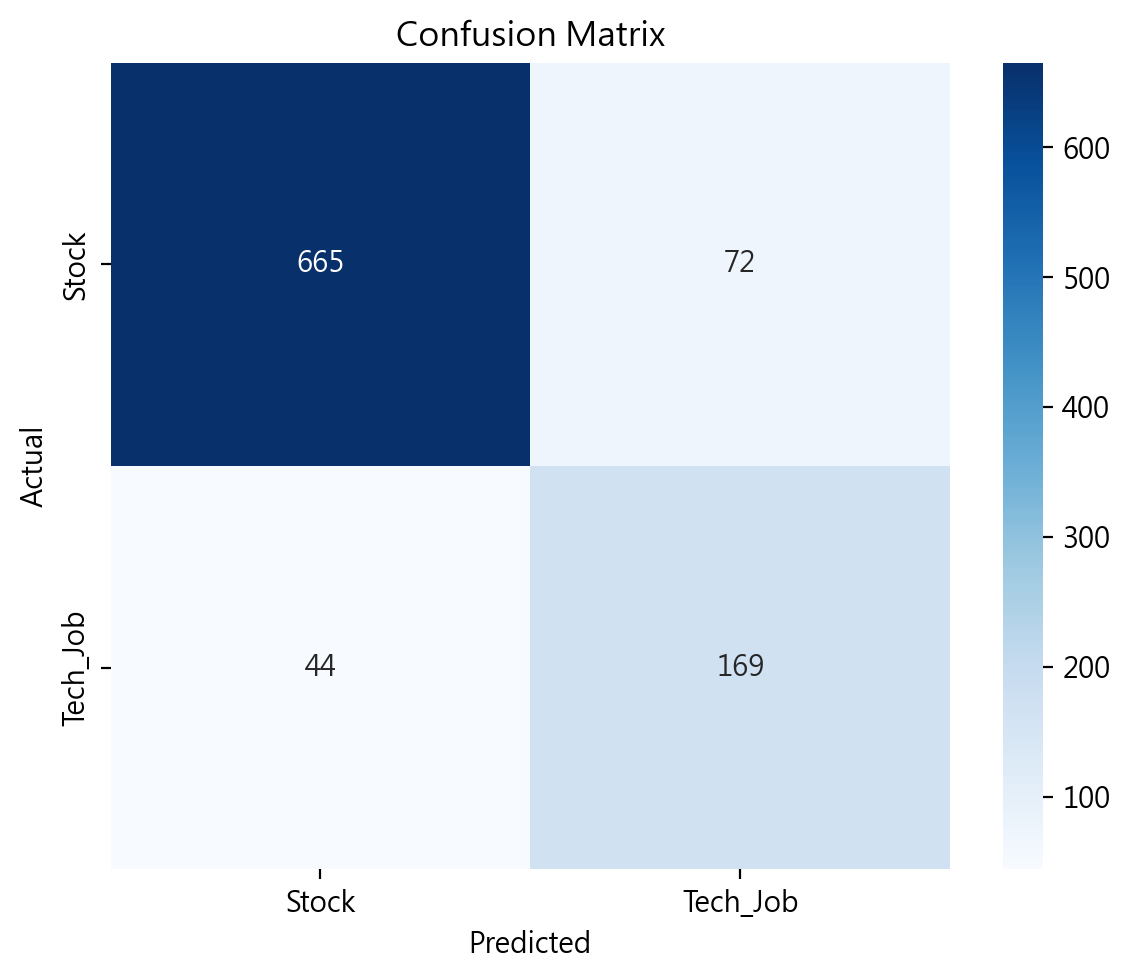

In [ ]:
#混淆矩陣
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_count_lr)

labels = sorted(y.unique())

plt.figure(figsize=(6, 5), dpi=200)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

訓練 TF-IDF + Logistic Regression。  
相比前面的分類模型，此模型更積極的辨識 Tech_Job。但也造成較多 Stock 文章被誤判為 Tech_Job，導致precision很低。

In [ ]:
# TF-IDF + Logistic Regression
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_lr_model = Pipeline([
    ('vectorizer', TfidfVectorizer(
        max_features=1000,
        token_pattern=r"(?u)\b\w+\b"
    )),
    ('classifier', LogisticRegression(
        max_iter=3000,
        class_weight='balanced'
    ))
])

tfidf_lr_model.fit(X_train, y_train)

y_pred_tfidf_lr = tfidf_lr_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_tfidf_lr))
print(classification_report(y_test, y_pred_tfidf_lr))

Accuracy: 0.8747368421052631
              precision    recall  f1-score   support

       Stock       0.97      0.86      0.91       737
    Tech_Job       0.66      0.91      0.77       213

    accuracy                           0.87       950
   macro avg       0.82      0.89      0.84       950
weighted avg       0.90      0.87      0.88       950



對 TF-IDF Logistic Regression 做 5-fold cross validation

In [ ]:
# Cross Validation
# =========================

from sklearn.model_selection import cross_validate

cv_result = cross_validate(
    tfidf_lr_model,
    X,
    y,
    cv=5,
    scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    return_train_score=True
)

cv_df = pd.DataFrame(cv_result)

cv_df

,fit_time,score_time,test_accuracy,train_accuracy,test_precision_macro,train_precision_macro,test_recall_macro,train_recall_macro,test_f1_macro,train_f1_macro
0,0.427321,0.086263,0.869085,0.904818,0.808003,0.850733,0.858481,0.919875,0.827602,0.876345
1,0.490551,0.096942,0.843602,0.916305,0.781411,0.864865,0.854135,0.933545,0.803486,0.890862
2,0.487607,0.122724,0.800948,0.915910,0.729972,0.864222,0.784093,0.935163,0.746671,0.890727
3,0.490898,0.117954,0.867299,0.897355,0.808679,0.841981,0.889432,0.916332,0.833559,0.868221
4,0.469249,0.114440,0.905213,0.898144,0.852917,0.842966,0.901358,0.919338,0.872946,0.869607


數據顯示模型具備還不錯的分類能力，但存在輕微的overfitting。

In [ ]:
# Cross Validation 平均分數
cv_summary = cv_df.mean(numeric_only=True).reset_index()
cv_summary.columns = ['metric', 'score']

cv_summary

,metric,score
0,fit_time,0.473125
1,score_time,0.107664
2,test_accuracy,0.857229
3,train_accuracy,0.906506
4,test_precision_macro,0.796196
5,train_precision_macro,0.852953
6,test_recall_macro,0.857500
7,train_recall_macro,0.924851
8,test_f1_macro,0.816853
9,train_f1_macro,0.879152


比較 Logistic Regression、SVM、Decision Tree、Random Forest    
Decision Tree 是整體表現最差的模型，而 Random Forest 則是整體表現最好的模型。Logistic Regression 與 SVM 在 Tech_Job 類別的 recall 較高，但 precision 較低，代表模型能辨識出多數 Tech_Job 文章，但也較容易將 Stock 文章誤判為 Tech_Job。

Logistic Regression
Accuracy: 0.8747368421052631
              precision    recall  f1-score   support

       Stock       0.97      0.86      0.91       737
    Tech_Job       0.66      0.91      0.77       213

    accuracy                           0.87       950
   macro avg       0.82      0.89      0.84       950
weighted avg       0.90      0.87      0.88       950

SVM
Accuracy: 0.8705263157894737
              precision    recall  f1-score   support

       Stock       0.97      0.86      0.91       737
    Tech_Job       0.65      0.90      0.76       213

    accuracy                           0.87       950
   macro avg       0.81      0.88      0.83       950
weighted avg       0.90      0.87      0.88       950

Decision Tree
Accuracy: 0.8663157894736843
              precision    recall  f1-score   support

       Stock       0.92      0.90      0.91       737
    Tech_Job       0.69      0.74      0.71       213

    accuracy                           0.87       950
   

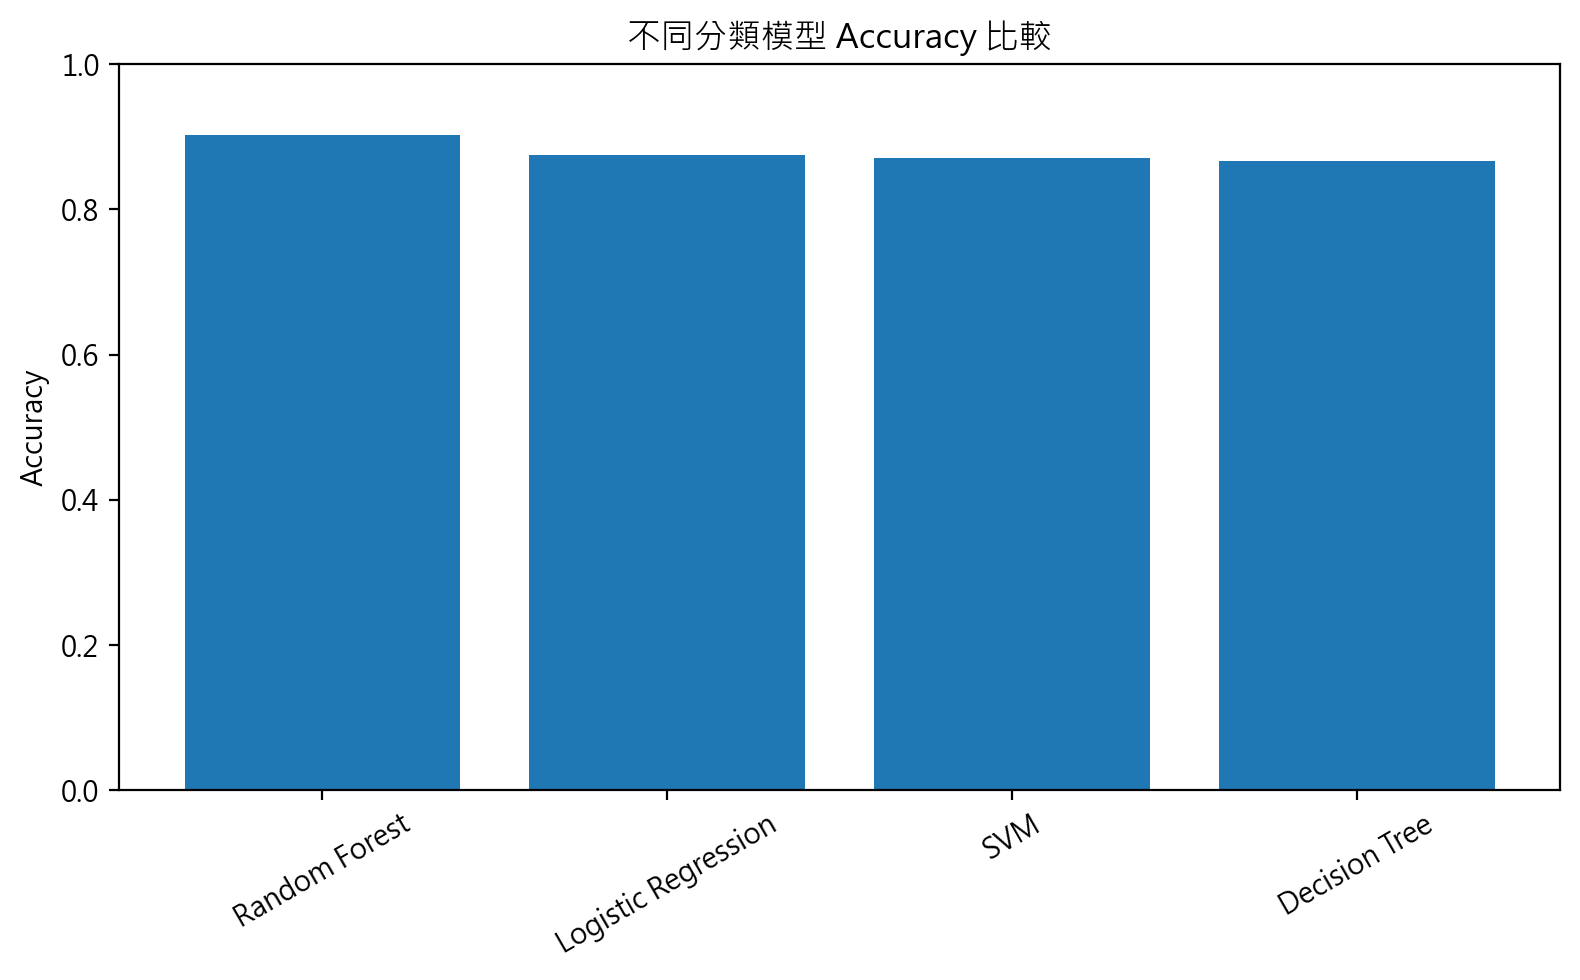

In [ ]:
# 多模型比較
# =========================

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight='balanced'
    ),
    "SVM": SVC(
        kernel='linear',
        class_weight='balanced'
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced'
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight='balanced'
    )
}

model_results = []

for model_name, clf in models.items():

    model_pipeline = Pipeline([
        ('vectorizer', TfidfVectorizer(
            max_features=1000,
            token_pattern=r"(?u)\b\w+\b"
        )),
        ('classifier', clf)
    ])

    model_pipeline.fit(X_train, y_train)

    y_pred = model_pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    model_results.append({
        'Model': model_name,
        'Accuracy': acc
    })

    print("=" * 60)
    print(model_name)
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

model_results_df = pd.DataFrame(model_results).sort_values(
    'Accuracy',
    ascending=False
)

model_results_df
#多模型 Accuracy 比較圖
plt.figure(figsize=(8, 5), dpi=200)

plt.bar(
    model_results_df['Model'],
    model_results_df['Accuracy']
)

plt.title("不同分類模型 Accuracy 比較")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

用 TF-IDF + Logistic Regression 找出最能區分 Stock 與 Tech_Job 的重要詞彙。其中偏向 Tech_Job 的詞明顯與台積電的工作內容、地點有關聯；偏向 Stock 的詞除了與股票投資，有不少屬於新聞模板用語。

In [ ]:
# Logistic Regression 重要特徵
best_vectorizer = TfidfVectorizer(
    max_features=1000,
    token_pattern=r"(?u)\b\w+\b"
)

X_all_tfidf = best_vectorizer.fit_transform(X)

lr = LogisticRegression(
    max_iter=3000,
    class_weight='balanced'
)

lr.fit(X_all_tfidf, y)

feature_names = best_vectorizer.get_feature_names_out()
classes = lr.classes_

# 如果是二分類
if len(classes) == 2:
    coef_df = pd.DataFrame({
        'word': feature_names,
        'coef': lr.coef_[0]
    })

    print("偏向類別：", classes[1])
    display(coef_df.sort_values('coef', ascending=False).head(20))

    print("偏向類別：", classes[0])
    display(coef_df.sort_values('coef', ascending=True).head(20))

# 如果是多分類
else:
    for i, class_name in enumerate(classes):
        coef_df = pd.DataFrame({
            'word': feature_names,
            'coef': lr.coef_[i]
        }).sort_values('coef', ascending=False)

        print("=" * 60)
        print("類別：", class_name)
        display(coef_df.head(20))

偏向類別： Tech_Job


,word,coef
331,工作,2.503144
337,工程師,2.275291
221,員工,2.188894
760,臺灣,2.185731
353,年薪,1.852366
267,大乘,1.800641
992,高雄,1.746428
478,新竹,1.741395
722,綜合,1.673414
498,晶圓,1.545254


偏向類別： Stock


,word,coef
182,原文,-10.075615
378,心得,-4.276014
824,評論,-3.482532
636,發布,-3.398293
613,現在,-2.586045
205,台股,-2.441206
61,交易,-2.049487
745,股價,-1.834644
749,股東,-1.778696
984,馬斯克,-1.737521


檢查分類錯誤的文章

In [ ]:
# 錯誤分類分析
error_df = classification_df.loc[X_test.index].copy()
error_df['true_label'] = y_test
error_df['pred_label'] = y_pred_tfidf_lr

wrong_df = error_df[error_df['true_label'] != error_df['pred_label']]

print("錯誤分類筆數：", len(wrong_df))
wrong_df[['artTitle', 'true_label', 'pred_label', 'words']].head(10)

錯誤分類筆數： 119


,artTitle,true_label,pred_label,words
201,[新聞] 台積電據傳開除多名涉嫌違規取得2奈米製,Tech_Job,Stock,原文 台積電 據傳 開除 多名 涉嫌 違規 取得 奈米 製程 技術 員工 日期 經濟日報 忠...
2110,[新聞] 美晶片戰略「施壓台積電救英特爾」 分析,Stock,Tech_Job,三立 新聞網 財經 晶片 戰略 施壓 台積電 英特爾 分析師 搶劫 財經 中心 楊惟 市場 ...
128,[新聞] 台積電之後是台達電？二代接班打進輝達核,Tech_Job,Stock,勤樸 積電 之後 台達電 二代 接班 打進 輝達 台積電 之後 台達電 二代 接班 打進 輝...
1920,[新聞] 台積電遭美籍員工集體訴訟,Stock,Tech_Job,原文 台積電 美籍 員工 集體 訴訟 原文 發布 記者 中國時報 王嘉源 柳名 原文 台積電...
1856,[新聞] CNN：川普勒索台積電近3.3兆「保護費」,Stock,Tech_Job,川普 勒索 台積電 保護費 嚇壞 台灣 中時 新聞網 美國 總統 川普 上週 突然 白宮 宣...
336,[新聞] 「川普上任後唯一成就搶走台積電」 工程,Tech_Job,Stock,川普 上任 唯一 成就 搶走 台積電 工程師 這國同 逼迫 唯獨 台灣 吭聲 李孟恩 護國神...
745,[新聞] 蘋果轉單免驚！英特爾也排隊搶台積電產,Stock,Tech_Job,自由時報 財經 蘋果 轉單 免驚 英特爾 排隊 台積電 產能 洪友芳 外媒 英特爾 傳出 有...
1261,[新聞] 台積電供應鏈將進駐屏東 屏東縣加快各項,Stock,Tech_Job,原文 台積電 供應鏈 進駐 屏東 屏東縣 加快 各項 建設 原文 發布 記者 葉永騫 原文 ...
1780,Re: [情報] 英特爾(INTC.O)與台積電(TSM.N)初步同意,Stock,Tech_Job,幾個 疑問 合資 企業 未來 台積電 競爭 對手 花多少 資金 合資 每股 認購 金額 股份...
1291,[新聞] 集邦：台積電第2季晶圓代工市占率衝新高7,Stock,Tech_Job,集邦 台積電 第季 晶圓 代工 市占率 新高 中央社 記者 建中 更新 市調 機構 集邦 科...


### 6. 熱門主題分析

#### (1) KMeans 分群

KMeans 做自動主題分群（k=6）

In [ ]:
# 自動主題辨識：每篇文章只屬於一個主題
# KMeans Clustering

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import pandas as pd

# 使用文章斷詞結果作為文字來源
cluster_texts = article_df['words'].fillna('')

# 建立 TF-IDF 特徵
cluster_vectorizer = TfidfVectorizer(
    max_features=1000,
    token_pattern=r"(?u)\b\w+\b"
)

X_cluster = cluster_vectorizer.fit_transform(cluster_texts)

# 設定主題數
num_clusters = 6

kmeans_model = KMeans(
    n_clusters=num_clusters,
    random_state=42,
    n_init=10
)

# 每篇文章只會被分到一個 cluster
article_df['single_topic_cluster'] = kmeans_model.fit_predict(X_cluster)

print("各主題群文章數：")
print(article_df['single_topic_cluster'].value_counts().sort_index())

各主題群文章數：
single_topic_cluster
0    526
1    506
2    962
3    233
4    800
5    139
Name: count, dtype: int64


查看每個 Cluster 的代表關鍵詞，大概可依序分為”半導體產業”、”赴美投資”、”台積電工作職場”、”財報與營運”、”股市”、”交易資訊”


In [ ]:
# 查看每個 Cluster 的代表關鍵詞
terms = cluster_vectorizer.get_feature_names_out()
order_centroids = kmeans_model.cluster_centers_.argsort()[:, ::-1]

for i in range(num_clusters):
    top_words = [terms[ind] for ind in order_centroids[i, :15]]
    print(f"Cluster {i} 代表詞：")
    print("、".join(top_words))
    print("-" * 50)

Cluster 0 代表詞：
台積電、奈米、英特爾、晶片、製程、三星、技術、美國、先進、客戶、原文、生產、量產、代工、輝達
--------------------------------------------------
Cluster 1 代表詞：
美國、川普、台積電、台灣、關稅、投資、晶片、億美、原文、半導體、中國、總統、生產、產業、設廠
--------------------------------------------------
Cluster 2 代表詞：
台積電、員工、台灣、公司、美國、工作、工程師、台積、嘉義、產業、原文、知道、半導體、日本、技術
--------------------------------------------------
Cluster 3 代表詞：
營收、台積電、新台幣、增加、目標價、毛利率、同期、億美、成長、法說、資本、需求、美元、預期、奈米
--------------------------------------------------
Cluster 4 代表詞：
台積電、台股、指數、股價、原文、股票、美股、外資、上漲、機制、現在、下跌、投資、台積、市值
--------------------------------------------------
Cluster 5 代表詞：
交易、適用、比例、日期、有價證券、處分、數量、取得、情形、公司、含本次、報表、總資產、業主、總金額
--------------------------------------------------


查看前20篇文章的主題，能發現近期的文章大多都是歸類到”台積電工作職場”這個主題，可能是因為台積電近期的薪水非常高，因此引起許多討論。

In [ ]:
# 查看文章所屬單一主題
cluster_result_df = article_df[['doc', 'artTitle', 'single_topic_cluster', 'words']].copy()

cluster_result_df.head(20)

,doc,artTitle,single_topic_cluster,words
0,0,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2,台灣 拋棄 思想 儒家 邪教 萬般 下品 惟有 讀書 賺錢 行業 知識 並不 存在 書本 現...
1,1,[新聞] 不是工程師…高職妹「台積電1工作」年收1,2,專業 果粉 工程師 高職 台積電 工作 年收 蘋果 日報 自由時報 參考 版規 下方 核准 ...
2,2,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2,搭版問 今年 初去 一批 外包商 建廠 人員 招八晚 五周 休二日 月入 稅後鎂 知道 現在...
3,3,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2,原文 講到 外食 能存 肯定 台灣 外食 一餐 週末 奢侈 點鎂 一餐 週算 租房 一點 車...
4,4,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2,原文 講到 外食 能存 肯定 台灣 外食 一餐 週末 奢侈 點鎂 一餐 週算 租房 一點 車...
5,5,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2,宅宅 加州 聖荷西 工作 東西 開銷 貴倍 根本 騙人 譬如說 知道 價位 根本 台灣 大潤...
6,6,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2,台積電 美廠 三年 薪水 開銷 台灣 同仁 說件 賺三倍 花三倍 代表 多存 偷著樂 台灣 ...
7,7,[新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2,台積電 美廠 三年 薪水 開銷 台灣 同仁 說件 薪水 帳面 三倍 真正 帶回 一名 自稱 ...
8,8,[新聞] 獨／台積電帶動「台灣嬰兒潮」 鳳凰城,2,台積電 帶動 台灣 嬰兒潮 鳳凰城 市長 誕生 寶寶 記者 貞怡 彭惠 台美 經貿 合作 升...
9,9,[新聞] 國安法首例！台積電洩密案 4內鬼工程師遭,2,國安法 首例 台積電 洩密案 內鬼 工程師 遭判 聯合報 記者 蔣永佑 新北 即時 台積電 ...


#### (2) 主題模型

LDA 主題模型，主題數=6  
其中 "赴美投資" 與 "交易資訊" 這兩個主題即便用LDA也能區分，對應到 topic 5、6。Topic 4 則對應到 "股票資訊" 與 "股市" 兩個分類。Topic 1、3、5 則較為模糊。

In [ ]:
# LDA主題模型
import gensim
from gensim import corpora
from gensim.models import LdaModel

# 轉成 list of list
texts = article_df['words'].apply(lambda x: x.split()).tolist()

# 建立字典
dictionary = corpora.Dictionary(texts)

# 過濾太少或太多的詞
dictionary.filter_extremes(
    no_below=5,
    no_above=0.5
)

# 建立 Bag-of-Words corpus
corpus = [dictionary.doc2bow(text) for text in texts]

# 設定主題數
num_topics = 6

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    iterations=100
)

# 顯示主題
for topic_id, topic_words in lda_model.print_topics(num_words=10):
    print(f"Topic {topic_id + 1}: {topic_words}")

Topic 1: 0.021*"員工" + 0.012*"原文" + 0.010*"公司" + 0.010*"工作" + 0.009*"發文" + 0.009*"工程師" + 0.008*"買回" + 0.006*"記者" + 0.006*"萬元" + 0.005*"台灣"
Topic 2: 0.012*"台灣" + 0.010*"台積" + 0.010*"現在" + 0.008*"投資" + 0.006*"知道" + 0.005*"股票" + 0.005*"未來" + 0.005*"晶片" + 0.005*"半導體" + 0.005*"產業"
Topic 3: 0.021*"先進" + 0.016*"嘉義" + 0.015*"奈米" + 0.015*"封裝" + 0.012*"量產" + 0.011*"高雄" + 0.011*"預計" + 0.010*"產能" + 0.010*"園區" + 0.009*"需求"
Topic 4: 0.016*"原文" + 0.010*"營收" + 0.010*"股價" + 0.009*"市場" + 0.008*"台股" + 0.008*"製程" + 0.008*"奈米" + 0.007*"指數" + 0.007*"記者" + 0.007*"今年"
Topic 5: 0.044*"美國" + 0.020*"台灣" + 0.020*"晶片" + 0.018*"川普" + 0.012*"英特爾" + 0.011*"投資" + 0.010*"原文" + 0.010*"關稅" + 0.009*"半導體" + 0.009*"技術"
Topic 6: 0.077*"交易" + 0.039*"公司" + 0.026*"適用" + 0.025*"比例" + 0.022*"處分" + 0.021*"日期" + 0.020*"取得" + 0.018*"數量" + 0.015*"有價證券" + 0.014*"情形"


列出主題分布數量，列出每個主題的數量後，可以看到不同主題的分布並不平均，代表某些主題在整體資料中被討論得更加頻繁。

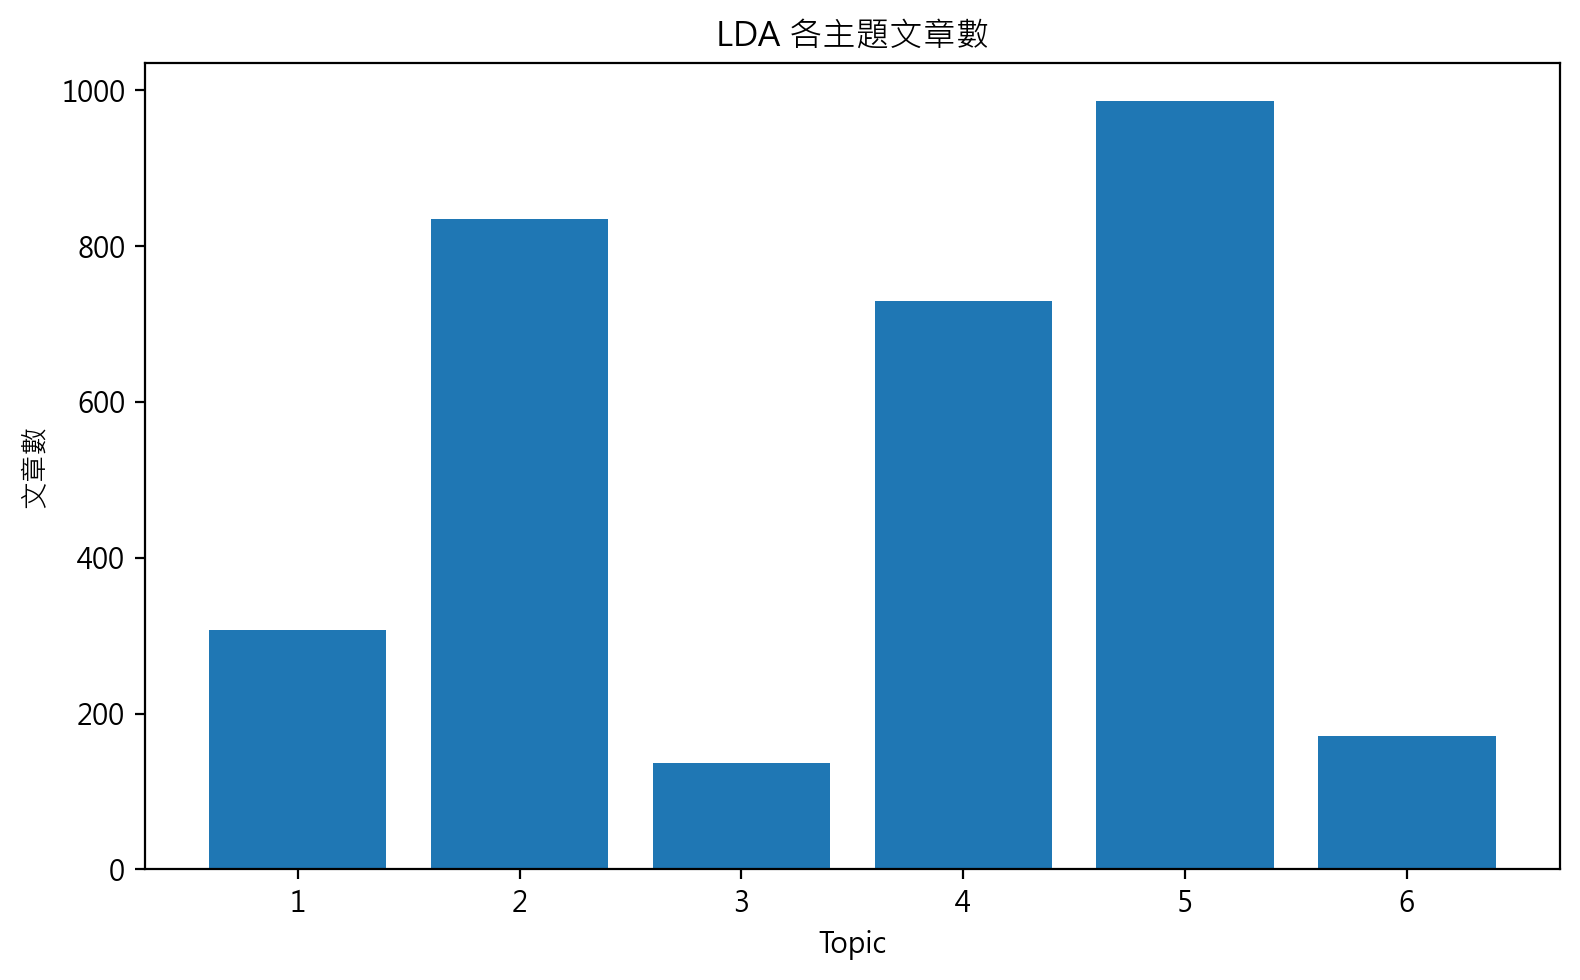

dominant_topic
1    307
2    835
3    137
4    730
5    986
6    171
Name: count, dtype: int64

In [ ]:
# 每篇文章的主題分布
doc_topics = []

for i, bow in enumerate(corpus):
    topic_dist = lda_model.get_document_topics(bow, minimum_probability=0)

    row = {
        'doc': article_df.iloc[i]['doc']
    }

    for topic_id, prob in topic_dist:
        row[f'Topic_{topic_id + 1}'] = prob

    row['dominant_topic'] = max(topic_dist, key=lambda x: x[1])[0] + 1

    doc_topics.append(row)

doc_topic_df = pd.DataFrame(doc_topics)

doc_topic_df.head()
# 主題比例統計
topic_counts = doc_topic_df['dominant_topic'].value_counts().sort_index()

plt.figure(figsize=(8, 5), dpi=200)
plt.bar(topic_counts.index.astype(str), topic_counts.values)
plt.title("LDA 各主題文章數")
plt.xlabel("Topic")
plt.ylabel("文章數")
plt.tight_layout()
plt.show()

topic_counts

用 pyLDAvis 視覺化

In [ ]:
# pyLDAvis 主題模型視覺化
import pyLDAvis
import pyLDAvis.gensim_models

pyLDAvis.enable_notebook()

lda_vis = pyLDAvis.gensim_models.prepare(
    lda_model,
    corpus,
    dictionary,
    n_jobs=1
)

lda_vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.080500 -0.071146       1        1  32.778810
3      0.084642 -0.124831       2        1  23.225415
1      0.095161 -0.134624       3        1  19.113215
0      0.032635  0.144911       4        1  10.116023
5     -0.399470 -0.009077       5        1   8.808371
2      0.106533  0.194767       6        1   5.958166, topic_info=     Term         Freq        Total Category  logprob  loglift
3359   交易  3758.000000  3758.000000  Default  30.0000  30.0000
221    美國  8444.000000  8444.000000  Default  29.0000  29.0000
236    公司  4622.000000  4622.000000  Default  28.0000  28.0000
4402   適用  1236.000000  1236.000000  Default  27.0000  27.0000
698    先進  2602.000000  2602.000000  Default  26.0000  26.0000
...   ...          ...          ...      ...      ...      ...
606    未來   195.569559  1376.764790   Topic6  -5.0970   0.8688
1904   進行   169.490148   753.206758   Topic6  -5.2401   1.3289
412    發展   164.981465   804.735463   Topic6  -5.2671   1.2357
160    記者   164.103017  2126.887686   Topic6  -5.2724   0.2585
921   晶圓廠   150.289448   934.328746   Topic6  -5.3604   0.9931

[470 rows x 6 columns], token_table=      Topic      Freq Term
term                      
60        1  0.069640   一下
60        2  0.031655   一下
60        3  0.823020   一下
60        4  0.072806   一下
60        6  0.003165   一下
...     ...       ...  ...
1382      2  0.389123   鴻海
1382      3  0.573792   鴻海
1382      5  0.028580   鴻海
9375      3  0.982588   黑手
8312      2  0.987258   點或

[1201 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 4, 2, 1, 6, 3])

尋找最佳主題數

In [ ]:
import pandas as pd
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

topic_range = range(2, 11)

lda_results = {}
coherence_scores = []

for k in topic_range:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=10,
        iterations=100
    )

    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    coherence = coherence_model.get_coherence()

    lda_results[k] = {
        'model': lda_model,
        'coherence': coherence
    }

    coherence_scores.append({
        'num_topics': k,
        'coherence': coherence
    })

coherence_df = pd.DataFrame(coherence_scores)

coherence_df

,num_topics,coherence
0,2,0.376952
1,3,0.631279
2,4,0.500893
3,5,0.622330
4,6,0.649803
5,7,0.584001
6,8,0.589749
7,9,0.566364
8,10,0.574299


視覺化 Coherence Score，可以發現目前使用的主題數=6已經是最佳解

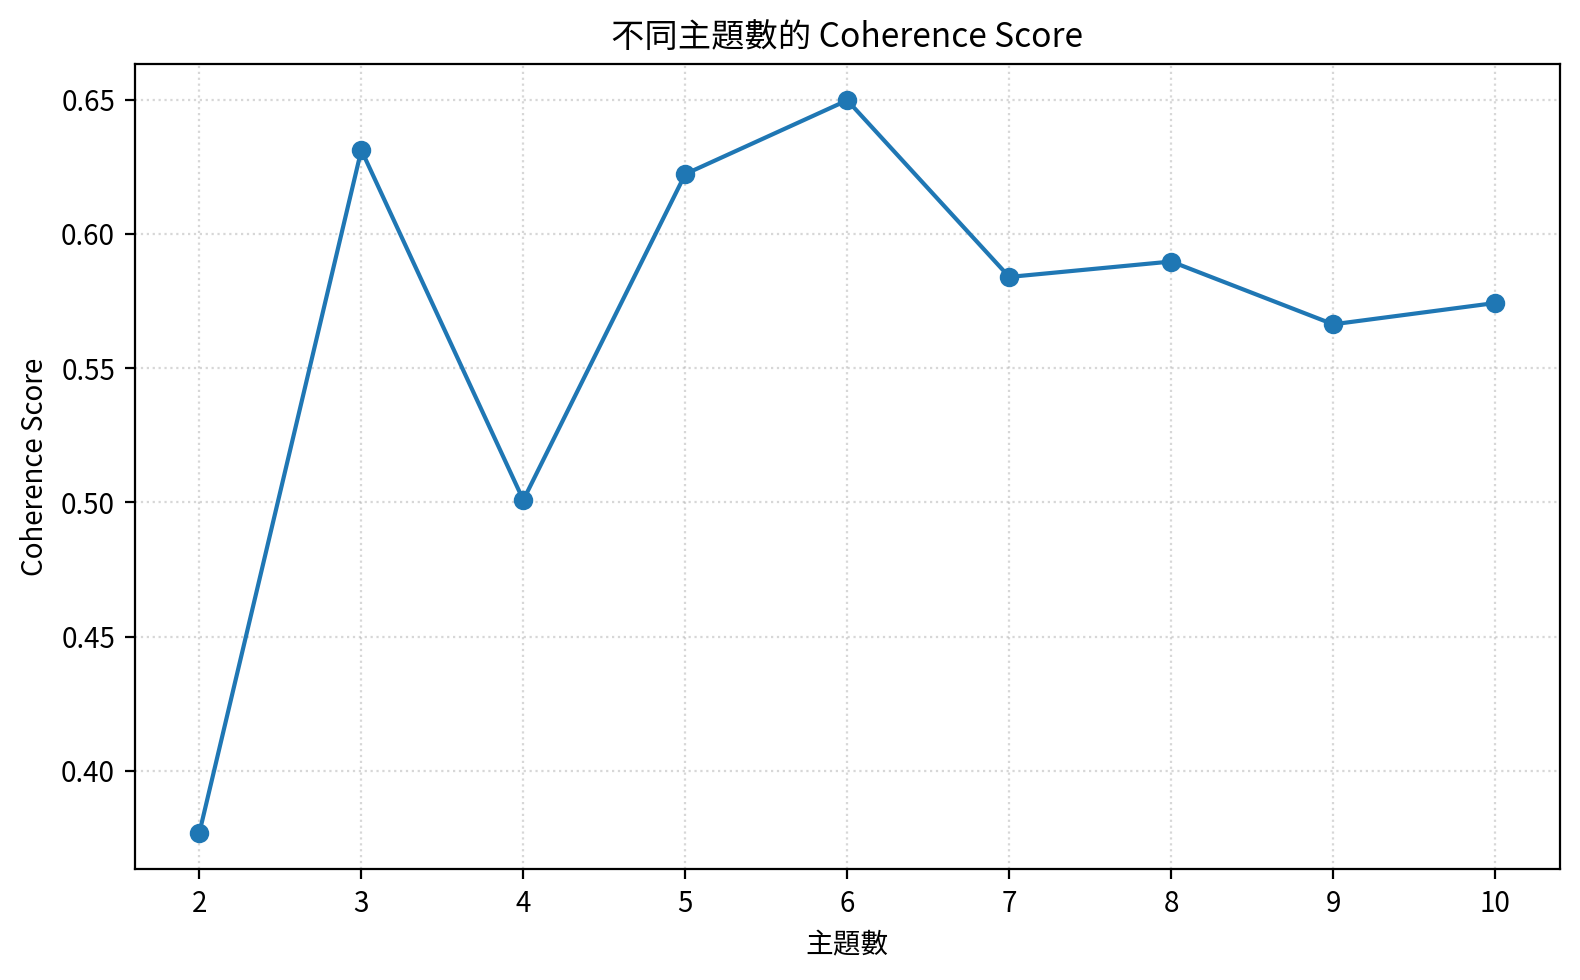

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5), dpi=200)

plt.plot(
    coherence_df['num_topics'],
    coherence_df['coherence'],
    marker='o'
)

plt.title("不同主題數的 Coherence Score")
plt.xlabel("主題數")
plt.ylabel("Coherence Score")
plt.xticks(coherence_df['num_topics'])

plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

根據 coherence score，查看 k=[3,4,6] 的結果


1. k=3  
    可以抓到大方向，包含 「台股市場與營運表現」、「美台半導體與地緣政治」、「公司交易與有價證券處分公告」，但分類太少。
2. k=4  
    新增了員工、工程師、發文、買回等詞，接近「職場/公司內部討論」，但也混入萬元、股份、台幣、製程，主題仍不夠集中。
3. k=6  
    分數最高，且主題分得比較詳細，包含：公司營收、美國政策、台股與股價表現、公司交易與有價證券處分公告、投資評論、先進製程



In [ ]:
selected_topics = [3, 4, 6]

for k in selected_topics:
    result = lda_results[k]
    model = result['model']
    coherence = result['coherence']

    print("=" * 80)
    print(f"主題數：{k}")
    print(f"Coherence Score：{coherence:.4f}")
    print("=" * 80)

    for topic_id, topic_words in model.print_topics(num_words=10):
        print(f"Topic {topic_id + 1}: {topic_words}")

    print()

主題數：3
Coherence Score：0.6313
Topic 1: 0.010*"股價" + 0.007*"台股" + 0.007*"市場" + 0.006*"營收" + 0.006*"製程" + 0.006*"心得" + 0.005*"指數" + 0.005*"外資" + 0.005*"發布" + 0.005*"成長"
Topic 2: 0.028*"美國" + 0.016*"台灣" + 0.014*"晶片" + 0.008*"半導體" + 0.008*"投資" + 0.008*"英特爾" + 0.008*"製程" + 0.008*"公司" + 0.007*"先進" + 0.007*"川普"
Topic 3: 0.083*"交易" + 0.037*"公司" + 0.027*"比例" + 0.024*"處分" + 0.024*"本次" + 0.023*"日期" + 0.020*"數量" + 0.017*"金額" + 0.016*"有價證券" + 0.015*"情形"

主題數：4
Coherence Score：0.5009
Topic 1: 0.010*"晶片" + 0.010*"製程" + 0.008*"股價" + 0.008*"市場" + 0.007*"奈米" + 0.007*"三星" + 0.006*"需求" + 0.006*"客戶" + 0.006*"營收" + 0.006*"產能"
Topic 2: 0.034*"美國" + 0.020*"台灣" + 0.013*"晶片" + 0.010*"川普" + 0.010*"投資" + 0.009*"半導體" + 0.009*"英特爾" + 0.008*"關稅" + 0.007*"先進" + 0.007*"公司"
Topic 3: 0.049*"交易" + 0.020*"公司" + 0.016*"比例" + 0.014*"處分" + 0.014*"台股" + 0.014*"本次" + 0.013*"日期" + 0.013*"指數" + 0.011*"數量" + 0.010*"持有"
Topic 4: 0.015*"公司" + 0.012*"員工" + 0.009*"萬元" + 0.008*"買回" + 0.008*"發文" + 0.007*"工程師" + 0.006*"股份" + 0.006*"台幣" +

進行 Guided LDA

In [ ]:
import pandas as pd

article_df = pd.read_csv(
    "guidedlda_input.csv"
)

article_df.head()

,doc,artTitle,artDate,artContent,words
0,0,Re: [新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-16 14:12:24,我覺得台灣要拋棄一個思想\n\n就是儒家邪教的「萬般皆下品 惟有讀書高」\n\n很多賺錢的行...,台灣 拋棄 思想 儒家 邪教 萬般 下品 惟有 讀書 賺錢 行業 知識 並不 存在 書本 現...
1,1,[新聞] 不是工程師…高職妹「台積電1工作」年收1,2026-05-15 06:38:27,作者: peterlin495 (專業果粉O'_'O) 看板: Gossiping\n標題:...,專業 果粉 工程師 高職 台積電 工作 年收 蘋果 日報 自由時報 參考 版規 下方 核准 ...
2,2,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2026-05-15 05:44:42,搭版問:\n\n今年初去了一批外包商的建廠人員\n\n招八晚五周休二日月入稅後5000鎂的\...,搭版問 今年 初去 一批 外包商 建廠 人員 招八晚 五周 休二日 月入 稅後鎂 知道 現在...
3,3,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2026-05-13 10:33:30,※ 引述《kudsaimoe (62632)》之銘言：\n: 吃原文 其實沒講到點上 就算全...,原文 講到 外食 能存 肯定 台灣 外食 一餐 週末 奢侈 點鎂 一餐 週算 租房 一點 車...
4,4,Re: [新聞] 台積電美廠待三年：薪水3倍但開銷也3倍,2026-05-13 05:48:50,吃原文 其實沒講到點上 就算全部吃外食 都叫uber能存的錢肯定還是比台灣多 外食自己隨\n...,原文 講到 外食 能存 肯定 台灣 外食 一餐 週末 奢侈 點鎂 一餐 週算 租房 一點 車...


根據之前很熱門的討論議題、大眾對台積電員工的印象與職涯發展，設定以下 6 類的種子詞，可以分類為”半導體技術”、”薪資福利”、”海外擴廠”、”科技業職場“、”股市投資“、”職場壓力“。


In [ ]:
#  Guided LDA
import guidedlda
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

if 'words' not in article_df.columns:
    raise ValueError("article_df 裡面找不到 'words' 欄位，請先完成斷詞並建立 words 欄位。")

# words 欄位轉成字串
guided_texts = article_df['words'].apply(
    lambda x: " ".join(x) if isinstance(x, list) else str(x)
)

# 建立 DTM
guided_vectorizer = CountVectorizer(
    max_features=1000,
    token_pattern=r"(?u)\b\w+\b"
)

X_guided = guided_vectorizer.fit_transform(guided_texts)

# Guided LDA 需要 int32
X_guided = X_guided.astype(np.int32)

# 詞彙表
vocab = guided_vectorizer.get_feature_names_out()
word2id = {word: idx for idx, word in enumerate(vocab)}

# 種子詞
seed_topic_list = [
    ['台積電', '晶片', '半導體', '晶圓', '先進製程'],
    ['薪水', '年薪', '分紅', '加班', '工時'],
    ['美國', '日本', '中國', '海外', '設廠'],
    ['工程師', '職缺', '面試', '工作', '科技業'],
    ['股價', '投資', '營收', '財報', '市場'],
    ['壓力', '離職', '爆肝', '生活', '主管']
]

seed_topics = {}

for topic_id, seed_words in enumerate(seed_topic_list):
    for word in seed_words:
        if word in word2id:
            seed_topics[word2id[word]] = topic_id

print("成功放入 Guided LDA 的種子詞數：", len(seed_topics))

if len(seed_topics) == 0:
    print("警告：沒有任何種子詞出現在資料中，Guided LDA 會退化成一般 LDA。")

# 建立 Guided LDA 模型
guided_model = guidedlda.GuidedLDA(
    n_topics=len(seed_topic_list),
    n_iter=100,
    random_state=42,
    refresh=20
)

# 訓練
guided_model.fit(
    X_guided,
    seed_topics=seed_topics,
    seed_confidence=0.15
)

# 顯示主題詞
n_top_words = 10
topic_word = guided_model.topic_word_

print("\nGuided LDA 主題結果：")

for topic_id, topic_dist in enumerate(topic_word):
    top_word_ids = np.argsort(topic_dist)[::-1][:n_top_words]
    top_words = [vocab[i] for i in top_word_ids]

    print(f"\nTopic {topic_id + 1}:")
    print("、".join(top_words))

INFO:guidedlda:n_documents: 3166
INFO:guidedlda:vocab_size: 1000
INFO:guidedlda:n_words: 378321
INFO:guidedlda:n_topics: 6
INFO:guidedlda:n_iter: 100


成功放入 Guided LDA 的種子詞數： 24


INFO:guidedlda:<0> log likelihood: -3157171
INFO:guidedlda:<20> log likelihood: -2346264
INFO:guidedlda:<40> log likelihood: -2323717
INFO:guidedlda:<60> log likelihood: -2317650
INFO:guidedlda:<80> log likelihood: -2313819
INFO:guidedlda:<99> log likelihood: -2312208



Guided LDA 主題結果：

Topic 1:
台積電、晶片、製程、奈米、技術、先進、英特爾、三星、客戶、半導體

Topic 2:
台積電、先進、奈米、製程、嘉義、高雄、原文、營收、預計、增加

Topic 3:
美國、台積電、台灣、川普、投資、晶片、關稅、原文、半導體、中國

Topic 4:
台積電、員工、台灣、公司、工作、工程師、大乘、美國、台積、技術

Topic 5:
台積電、原文、股價、台股、指數、市場、外資、投資、記者、營收

Topic 6:
交易、公司、適用、比例、日期、處分、取得、數量、有價證券、情形


列出 Guided LDA 每個主題的 Top 15。結果可以看到「薪資福利」與「職場壓力」兩組種子詞沒有明顯形成獨立主題。”海外擴廠”被分開為Topic 2、Topic 3這兩個主題，「薪資福利」與「職場壓力」的主題沒有形成。

In [ ]:
# Guided LDA 主題結果
n_top_words = 15

topic_word = guided_model.topic_word_

for topic_id, topic_dist in enumerate(topic_word):
    top_word_ids = np.argsort(topic_dist)[::-1][:n_top_words]
    top_words = [vocab[i] for i in top_word_ids]

    print(f"Topic {topic_id + 1}:")
    print("、".join(top_words))
    print()

Topic 1:
台積電、晶片、製程、奈米、技術、先進、英特爾、三星、客戶、半導體、原文、輝達、晶圓、公司、產能

Topic 2:
台積電、先進、奈米、製程、嘉義、高雄、原文、營收、預計、增加、記者、新台幣、今年、廠區、園區

Topic 3:
美國、台積電、台灣、川普、投資、晶片、關稅、原文、半導體、中國、億美、公司、英特爾、產業、企業

Topic 4:
台積電、員工、台灣、公司、工作、工程師、大乘、美國、台積、技術、菩薩、產業、佛教、半導體、人才

Topic 5:
台積電、原文、股價、台股、指數、市場、外資、投資、記者、營收、現在、美元、心得、上漲、股票

Topic 6:
交易、公司、適用、比例、日期、處分、取得、數量、有價證券、情形、持有、金額、價格、本次、資金



計算每篇文章在 Guided LDA 六個主題上的機率，找出 dominant topic

In [ ]:
# Guided LDA 每篇文章主題
doc_topic = guided_model.transform(X_guided)

guided_topic_df = pd.DataFrame(
    doc_topic,
    columns=[f'Topic_{i+1}' for i in range(doc_topic.shape[1])]
)

guided_topic_df['dominant_topic'] = guided_topic_df.idxmax(axis=1)
guided_topic_df['doc'] = article_df['doc'].values

guided_topic_df.head()

,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,dominant_topic,doc
0,0.000157,0.000144,0.000431,0.998928,0.000267,0.000073,Topic_4,0
1,0.011465,0.036341,0.005210,0.767337,0.179588,0.000058,Topic_4,1
2,0.000857,0.003312,0.000880,0.970446,0.023589,0.000917,Topic_4,2
3,0.000250,0.000253,0.090754,0.842533,0.066189,0.000021,Topic_4,3
4,0.000418,0.000343,0.014617,0.883873,0.100717,0.000031,Topic_4,4


統計每天各主題文章數

In [ ]:
# 每日主題趨勢
topic_trend_df = pd.merge(
    article_df[['doc', 'artDate']],
    guided_topic_df[['doc', 'dominant_topic']],
    on='doc',
    how='inner'
)

topic_trend_df['artDate'] = pd.to_datetime(topic_trend_df['artDate'], errors='coerce')
topic_trend_df['date'] = topic_trend_df['artDate'].dt.date

daily_topic = (
    topic_trend_df
    .groupby(['date', 'dominant_topic'])
    .size()
    .reset_index(name='count')
)

daily_topic_pivot = daily_topic.pivot(
    index='date',
    columns='dominant_topic',
    values='count'
).fillna(0)

daily_topic_pivot.head()

dominant_topic,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6
date,,,,,,
2024-05-20,0.0,0.0,0.0,0.0,1.0,0.0
2024-05-21,1.0,0.0,0.0,2.0,0.0,0.0
2024-05-22,0.0,0.0,0.0,1.0,0.0,0.0
2024-05-23,0.0,1.0,1.0,0.0,1.0,0.0
2024-05-24,0.0,1.0,1.0,0.0,0.0,0.0


#### (3) BERTopic 主題分群



用 `bert-base-chinese` 做 embedding，搭配 jieba 中文分詞的 CountVectorizer，
自動分群出 PTT 台積電討論的潛在主題，並以 KeyBERT 微調主題關鍵詞。

In [ ]:
# 準備文章語料（句子層級效果較好)
# 用 sent_df（前面斷句後的 dataframe），過濾長度過短的句子
bertopic_docs = (
    sent_df['sentence']
    .dropna()
    .str.strip()
    .loc[lambda s: s.str.len() >= 10]  # 至少 10 個字
    .tolist()
)

print(f"BERTopic 語料數：{len(bertopic_docs)} 句")
print("範例：", bertopic_docs[:3])

BERTopic 語料數：92058 句
範例： ['我覺得台灣要拋棄一個思想', '就是儒家邪教的「萬般皆下品 惟有讀書高」', '很多賺錢的行業 或是知識 並不存在於書本上']


計算 BERT embeddings

In [ ]:
# 計算 BERT embeddings（可重複使用 corpus_embeddings 計算過的結果，這裡針對句子層級重新計算)
print("計算句子 embeddings，請稍候...")
bert_sentence_model = SentenceTransformer('google-bert/bert-base-chinese')
bert_sentence_model.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

bertopic_embeddings = bert_sentence_model.encode(
    bertopic_docs,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)
print("Embeddings shape:", bertopic_embeddings.shape)

INFO:sentence_transformers.base.model:No device provided, using cpu


計算句子 embeddings，請稍候...


INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-chinese/resolve/main/modules.json "HTTP/1.1 404 Not Found"
INFO:sentence_transformers.base.model:No modules.json found for google-bert/bert-base-chinese, initializing a new SentenceTransformer model.
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-chinese/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-chinese/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/google-bert/bert-base-chinese/8f23c25b06e129b6c986331a13d8d025a92cf0ea/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-chinese/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: HEAD https://huggingface.co/google-bert/bert-base-chinese/resolve/main/preproces

Batches:   0%|          | 0/1439 [00:00<?, ?it/s]

Embeddings shape: (92058, 768)


訓練 BERTopic 模型

In [ ]:
# 設定中文 jieba 分詞的 CountVectorizer
def tokenize_zh(text):
    words = jieba.lcut(str(text))

    return [
        word
        for word in words
        if word not in stopWords
        and len(word.strip()) > 1
    ]

jieba_vectorizer = CountVectorizer(
    tokenizer=tokenize_zh,

    # 已在 tokenize_zh 中移除停用詞，
    # 這裡可以不必再設定 stop_words
    stop_words=None,
    analyzer="word",

    # 自訂 tokenizer 時關閉預設 token_pattern
    token_pattern=None,
    # 至少出現在 5 篇文件中的詞才保留
    min_df=5
)

# KeyBERT representation 微調
keybert = KeyBERTInspired()
representation_model = {'KeyBERT': keybert}

# 建立 BERTopic 模型
hdbscan_model = HDBSCAN(min_cluster_size=20, min_samples=10, metric='euclidean', core_dist_n_jobs=1, algorithm="prims_kdtree")

topic_model = BERTopic(
    embedding_model=bert_sentence_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=jieba_vectorizer,
    representation_model=representation_model,
    top_n_words=15,
    verbose=True
)

topics, probs = topic_model.fit_transform(bertopic_docs, bertopic_embeddings)
print("\nBERTopic 訓練完成！")

2026-06-14 16:50:13,718 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-14 16:51:14,911 - BERTopic - Dimensionality - Completed ✓
2026-06-14 16:51:14,914 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-14 16:52:26,059 - BERTopic - Cluster - Completed ✓
2026-06-14 16:52:26,095 - BERTopic - Representation - Extracting topics from clusters using representation models.
2026-06-14 16:53:50,870 - BERTopic - Representation - Completed ✓



BERTopic 訓練完成！


查看主題摘要

In [ ]:
# 查看主題摘要
topic_info = topic_model.get_topic_info()
print(f"共發現 {len(topic_info) - 1} 個主題（-1 為離群點）")
topic_info.head(15)

共發現 682 個主題（-1 為離群點）


,Topic,Count,Name,Representation,KeyBERT,Representative_Docs
0,-1,52283,-1_技術_半導體_投資_產能,"[技術, 半導體, 投資, 產能, 未來, 晶片, 市場, 台灣, 台積電, 企業, 需求,...","[台積電, 半導體, 英特爾, 晶圓廠, 投資人, 鴻海, 晶片, 要求, 台積, 計畫]","[台積電作為全球領先的半導體製造企業, 但中國的市場需求是比美國大的（以人口基數而言）, 考..."
1,0,1537,0_一下_知道_推文_有沒有,"[一下, 知道, 推文, 有沒有, 一堆, 看到, 鬼故事, 好像, 東西, 分享, 那你,...","[要不要, 能不能, 有沒有, 沒什麼, 沒辦法, 想問, 請問, 有時候, 看看, 不一定]","[這個脈絡有人知道原因嗎, 你可以搜一下其他公司比比看就知道了, 所以不知道我是不是記錯了來..."
2,1,875,1_台股_大漲_開盤_一度,"[台股, 大漲, 開盤, 一度, 股價, 新高, 大關, 早盤, 盤中, 逾點, 夜盤, 天...","[開高走低, 台積電, 台指期, 收盤價, 創新高, 飆漲, 跌停, 指數, 萬點, 盤中]","[台積電「開盤衝上元」登千金股 台股大漲近點, 台股今（日）早盤一度大漲超過點, 盤中一度衝..."
3,2,681,2_亞利桑那州_亞利桑那_晶圓廠_鳳凰城,"[亞利桑那州, 亞利桑那, 晶圓廠, 鳳凰城, 位於, 第座, 工廠, 興建, 首座, 建造...","[亞利桑那, 亞利桑那州, 鳳凰城, 台積電, 子公司, 那州, 加州, 德州, 晶圓廠, ...","[這人皆居住在亞利桑那州, 亞利桑那州政府本身也在今, 有亞利桑那州的小新聞嗎]"
4,3,605,3_美積電_變成_台積_以前,"[美積電, 變成, 台積, 以前, 美積, 變美, 不可能, 不夠, 斷頭, 台積電, 宏達...","[台積電, 美積電, 宏達電, 更何況, 積電, 沒想到, 鴻海, 搞不好, 台積, 馬斯克]","[很多媒體報導說如果台積電變成「美積電」, 很多媒體報導說如果台積電變成「美積電, 台積電不..."
5,4,470,4_營收_預期_預估_展望,"[營收, 預期, 預估, 展望, 第季, 優於, 複合, 成長, 成長率, 超出, 年增, ...","[毛利率, 挹注, 營益率, 年增率, 看好, 成長率, 上半年, 預期, 下半年, 銷售額]","[預期年以美元計價營收將成長, 台積電預期今年第季美元營收為-億美, 今年營收成長預期至%]"
6,5,399,5_副總經理_資深_副總_共同,"[副總經理, 資深, 副總, 共同, 擔任, 董事長, 組織, 魏哲家, 總裁, 唯仁, 處...","[副總經理, 執行長, 董事長, 創辦人, 台積電, 總經理, 前董事, 發言人, 辦公室,...","[十二日由資深副總經理暨副共同營運長侯永清宣布, 台積電資深副總經理暨副共同營運長張曉強則表..."
7,6,396,6_原文_經長_外媒_郭智輝,"[原文, 經長, 外媒, 郭智輝, 韓媒, 路透, 合資, 曝光, 罰款, 施壓, 對美, ...","[台積電, 半導體業, 半導體廠, 英特爾, 機器人, 投資案, 蘇姿丰, 代工廠, 吳誠文...","[原文標題：台積電奈米防線 因技術洩密告急, 原文標題：傳台積電奈米水漲船高, 原文標題：台..."
8,7,367,7_獎金_薪資_分紅_薪酬,"[獎金, 薪資, 分紅, 薪酬, 萬元, 年薪, 福利, 年度, 平均, 每人, 員工, 薪...","[董事會, 起薪, 年薪, 費用, 薪酬, 億萬元, 月薪, 薪資, 新台幣, 補助]","[還有購股補助、獎金分紅, 台積電董事會核准年度員工業績獎金與酬勞（分紅）, 至於最令人羨煞..."
9,8,353,8_超微_高通_蘋果_博通,"[超微, 高通, 蘋果, 博通, 輝達, 微軟, 聯發科, 包括, 亞馬遜, 格羅方德, 艾...","[英特爾, 特斯拉, 半導體, 聯發科, 芯片, 晶片, 谷歌, 輝達, 華為, 格羅方德]","[輝達、超微、英特爾、高通、聯發科、蘋果及, 為包括蘋果（）、輝達（）、高通（）和超微（, ..."


BERTopic 共產生 682 個主題，不過其中包含大量制式公告、新聞來源、PTT 口語與空白符號主題，顯示目前結果仍受到資料格式與前處理影響。後續應進一步清理停用詞、合併相近詞，並調整 HDBSCAN 參數或降低主題數，以提升主題模型的可解釋性。

In [ ]:
# 列出每個主題的代表關鍵詞
for topic_id in sorted(topic_info['Topic'].tolist()):
    if topic_id == -1:
        continue
    keywords = topic_model.get_topic(topic_id)
    kw_str = '、'.join([w for w, _ in keywords[:8]])
    count = topic_info[topic_info['Topic'] == topic_id]['Count'].values[0]
    print(f"Topic {topic_id:2d} ({count:4d} 句)：{kw_str}")

Topic  0 (1537 句)：一下、知道、推文、有沒有、一堆、看到、鬼故事、好像
Topic  1 ( 875 句)：台股、大漲、開盤、一度、股價、新高、大關、早盤
Topic  2 ( 681 句)：亞利桑那州、亞利桑那、晶圓廠、鳳凰城、位於、第座、工廠、興建
Topic  3 ( 605 句)：美積電、變成、台積、以前、美積、變美、不可能、不夠
Topic  4 ( 470 句)：營收、預期、預估、展望、第季、優於、複合、成長
Topic  5 ( 399 句)：副總經理、資深、副總、共同、擔任、董事長、組織、魏哲家
Topic  6 ( 396 句)：原文、經長、外媒、郭智輝、韓媒、路透、合資、曝光
Topic  7 ( 367 句)：獎金、薪資、分紅、薪酬、萬元、年薪、福利、年度
Topic  8 ( 353 句)：超微、高通、蘋果、博通、輝達、微軟、聯發科、包括
Topic  9 ( 349 句)：直言、留言、紛紛、描述、崩潰、一早、沒錢、認識
Topic 10 ( 348 句)：工安、工人、意外、發生、包商、嘉義廠、停工、作業
Topic 11 ( 345 句)：奈米、製程、以下、切入、節點、三廠、導入、採用
Topic 12 ( 341 句)：美國人、東西、權力、不用、乾脆、這麼多、美國、談判
Topic 13 ( 334 句)：公頃、園區、楠梓、科學園區、南科、屏東、嘉義縣、嘉義
Topic 14 ( 327 句)：總統、大選、川普、白宮、前總統、當選、接受、國會
Topic 15 ( 319 句)：川普、上台、執政、面子、再來、陣營、仔細、選舉
Topic 16 ( 277 句)：以色列、烏克蘭、軍事、國防、攻擊、伊朗、預算、戰爭
Topic 17 ( 270 句)：法院、高等、犯罪、涉案、違反、搜索、商業、調查
Topic 18 ( 254 句)：預計、下半年、量產、年底、裝機、明年、完工、上半年
Topic 19 ( 237 句)：經驗、學歷、外派、技術員、畢業生、招募、簽證、學校
Topic 20 ( 197 句)：目標價、摩根士丹利、證券、大摩、花旗、券商、調高、調升
Topic 21 ( 195 句)：課徵、關稅、對等、總統、川普、徵收、揚言、進口
Topic 22 ( 183 句)：英特爾、訊號、代工廠、困境、調降、部門、代工、現

對前 8 個 BERTopic 主題畫 Top 關鍵詞長條圖。根據圖片可看到Topic 0 雖然句數最多，但關鍵詞偏口語化，不具實際主題意義。若排出Topic 0 後，可發現台積電 PTT 語料的前幾大主題主要集中在股市行情、海外設廠、台積電美國化、財報營收、高層人事、政策新聞與薪資福利。

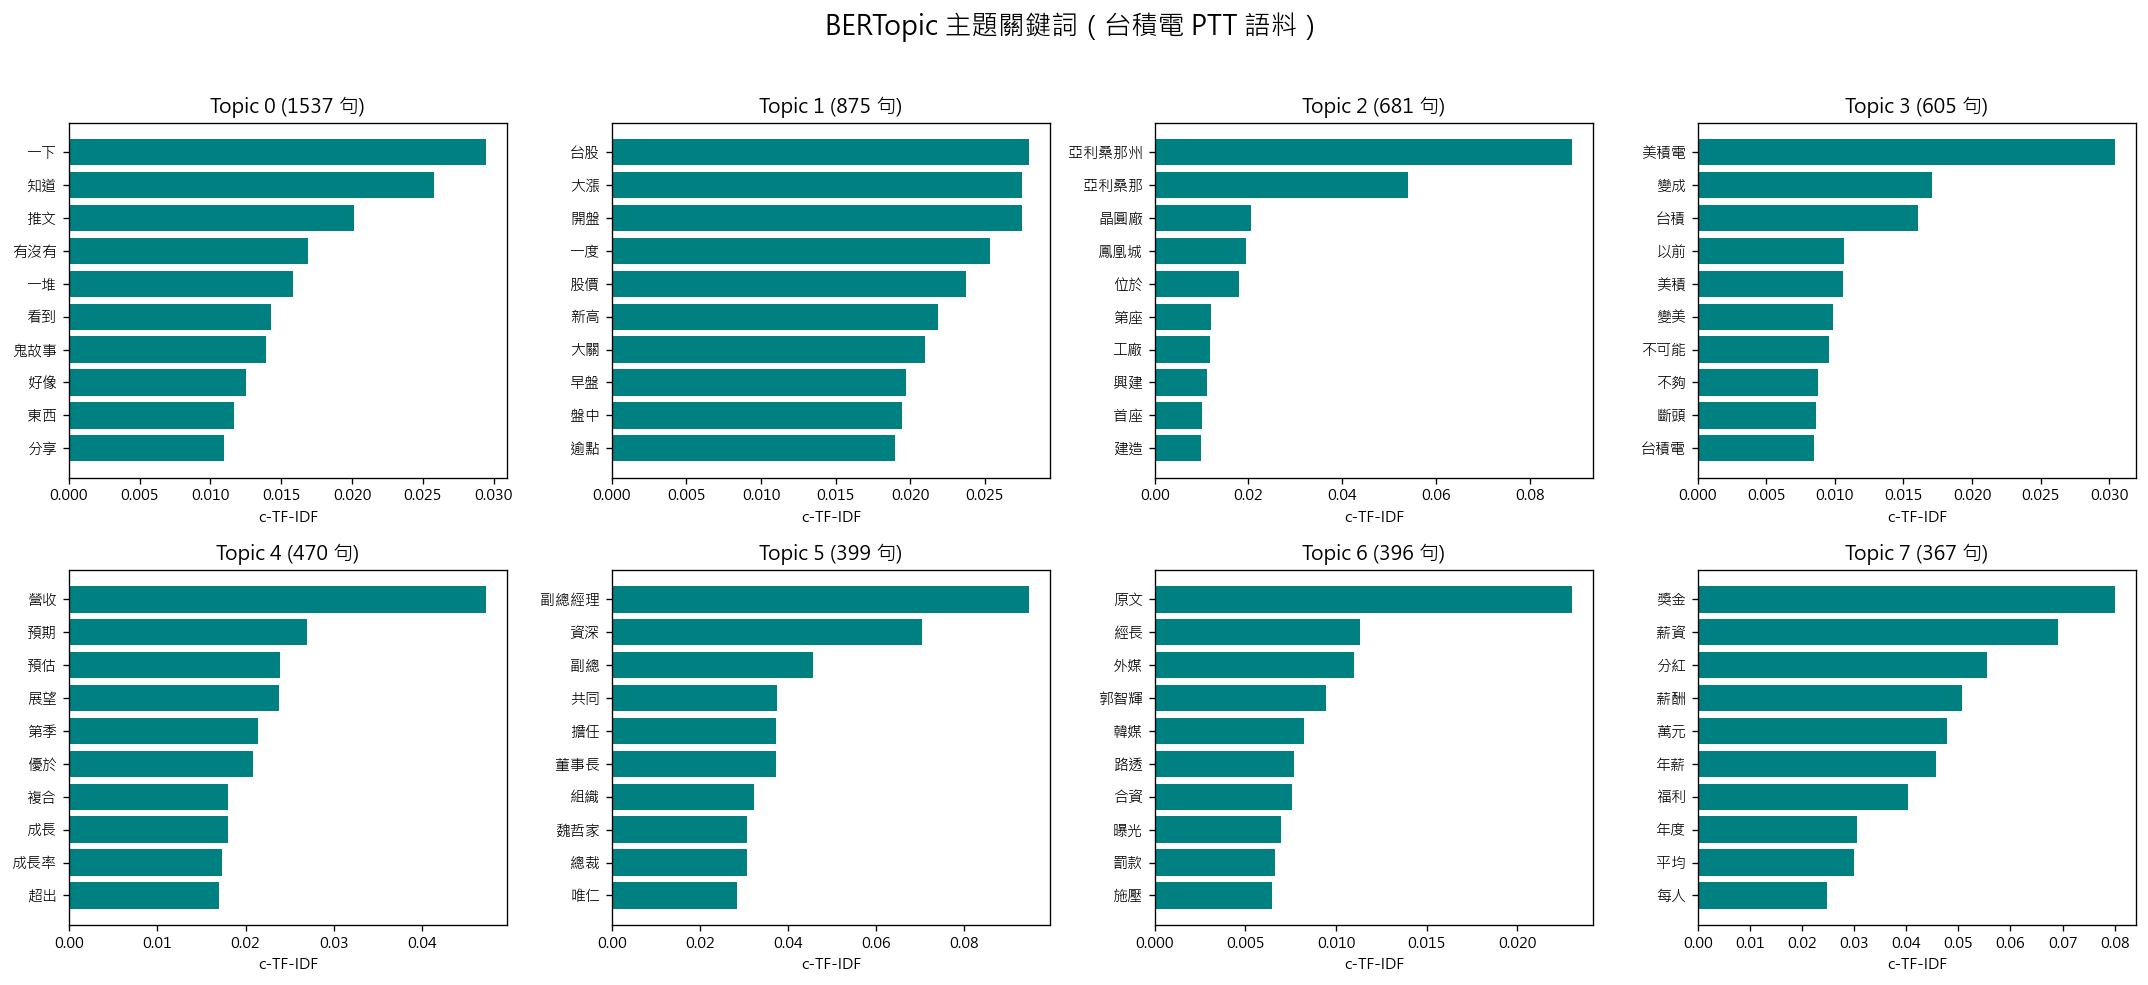

In [ ]:
# 各主題 Top 關鍵詞長條圖
n_show = min(8, len(topic_info) - 1)  # 最多顯示 8 個主題

fig, axes = plt.subplots(2, 4, figsize=(18, 8), dpi=120)
axes = axes.flatten()

plot_topics = [t for t in sorted(topic_info['Topic'].tolist()) if t != -1][:n_show]

for ax, topic_id in zip(axes, plot_topics):
    data = topic_model.get_topic(topic_id)
    words = [w for w, _ in data[:10]]
    scores = [s for _, s in data[:10]]
    count = topic_info[topic_info['Topic'] == topic_id]['Count'].values[0]
    ax.barh(words[::-1], scores[::-1], color='teal')
    ax.set_title(f'Topic {topic_id} ({count} 句)', fontsize=12)
    ax.set_xlabel('c-TF-IDF', fontsize=9)
    ax.tick_params(labelsize=9)

# 隱藏多餘的 subplot
for ax in axes[n_show:]:
    ax.set_visible(False)

plt.suptitle('BERTopic 主題關鍵詞（台積電 PTT 語料）', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

畫出「主題 × 時間趨勢」折線圖，可以發現2024-07與2025-03是兩個討路高峰，2024-07發生台積電股價第一次破千，因此能發現台股主題(T1)與營收主題(T4)有顯著上升，而2025-03則是台積電宣布擴大赴美投資，導致亞利桑那州(T2)與美積電(T3)有明顯上升。

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

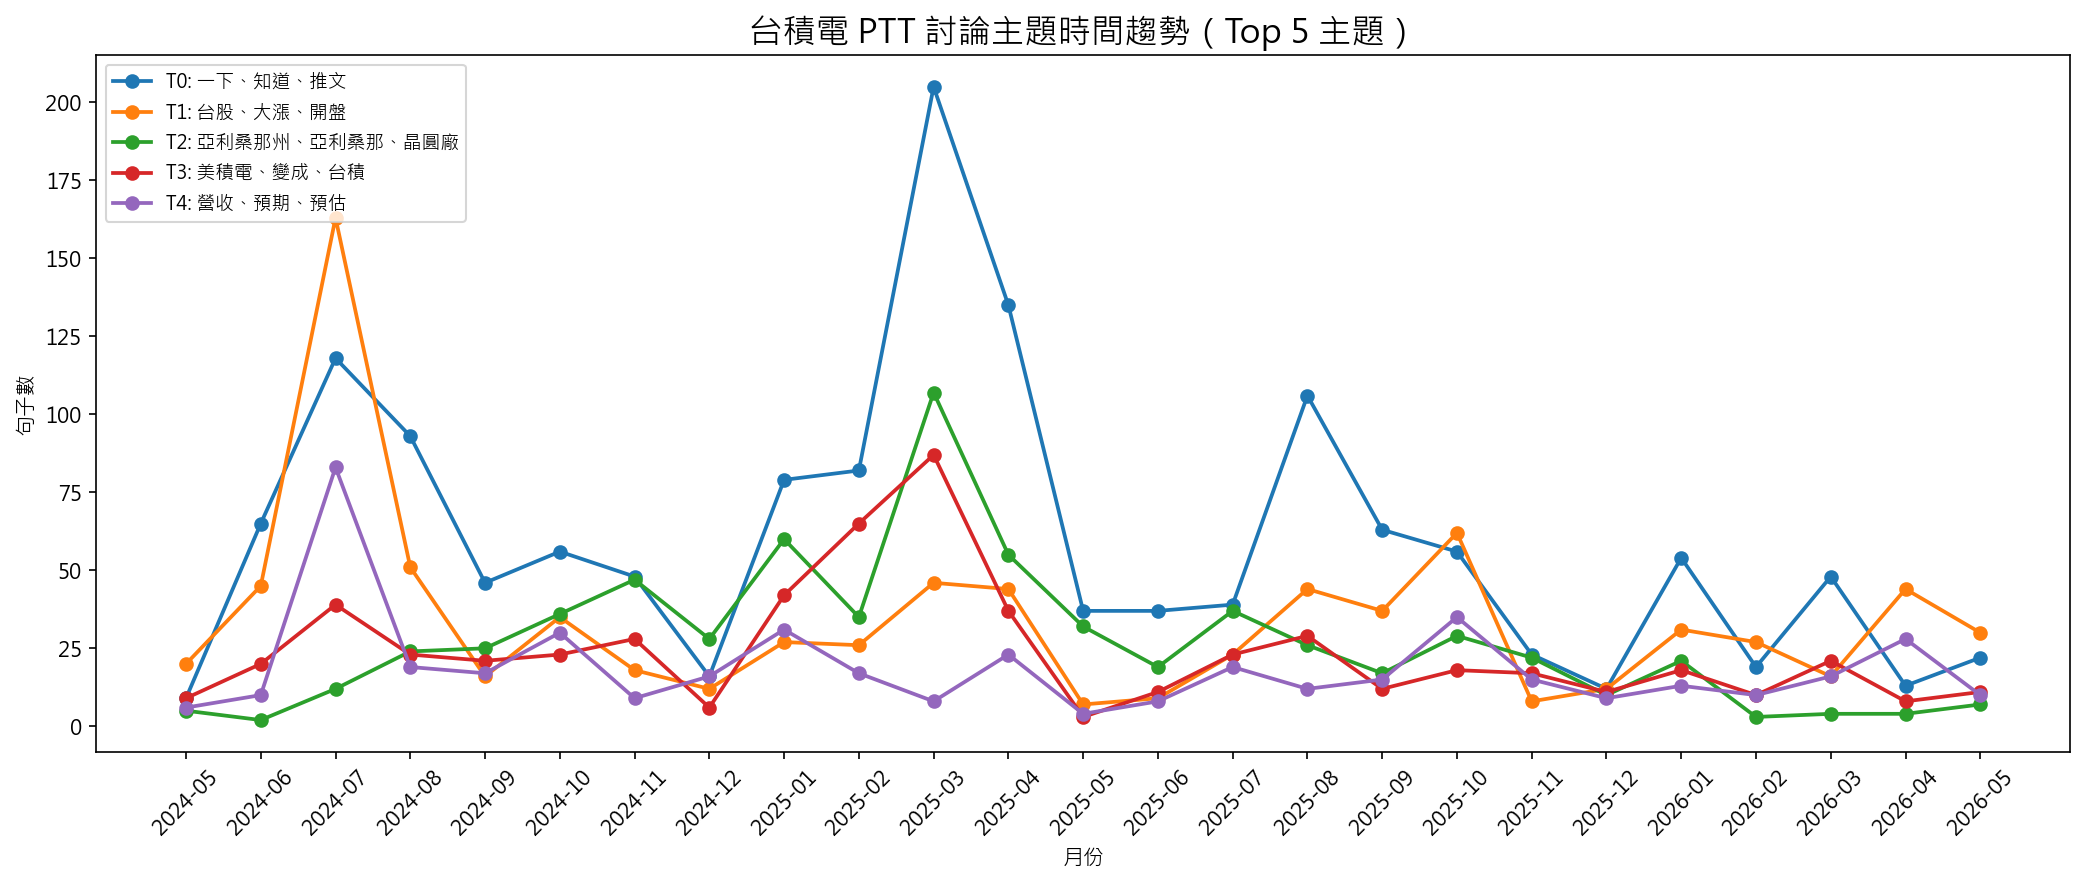

In [ ]:
# 主題 × 時間趨勢
# 將主題結果對應回 sent_df 的日期
bertopic_result_df = pd.DataFrame({
    'sentence': bertopic_docs,
    'topic': topics
})

# 合併日期（以 sentence 為 key join 回 sent_df）
bertopic_merged = pd.merge(
    bertopic_result_df,
    sent_df[['sentence', 'artDate']].drop_duplicates(subset='sentence'),
    on='sentence', how='left'
)
bertopic_merged['artDate'] = pd.to_datetime(bertopic_merged['artDate'], errors='coerce')
bertopic_merged['month'] = bertopic_merged['artDate'].dt.to_period('M')

# 每月各主題句子數
topic_time = (
    bertopic_merged[bertopic_merged['topic'] != -1]
    .groupby(['month', 'topic'])
    .size()
    .reset_index(name='count')
)
topic_time['month_str'] = topic_time['month'].astype(str)

# 只取前 5 大主題
top5_topics = topic_info[topic_info['Topic'] != -1].nlargest(5, 'Count')['Topic'].tolist()
topic_time_top5 = topic_time[topic_time['topic'].isin(top5_topics)]

plt.figure(figsize=(14, 6), dpi=150)
for tid in top5_topics:
    sub = topic_time_top5[topic_time_top5['topic'] == tid].sort_values('month_str')
    kws = '、'.join([w for w, _ in topic_model.get_topic(tid)[:3]])
    plt.plot(sub['month_str'], sub['count'], marker='o', linewidth=1.8, label=f'T{tid}: {kws}')

plt.title('台積電 PTT 討論主題時間趨勢（Top 5 主題）', fontsize=16)
plt.xlabel('月份')
plt.ylabel('句子數')
plt.xticks(rotation=45)
plt.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

##結論

**結論**

整體而言，本研究透過 PTT Stock 與 Tech_Job 看板中 3166 篇台積電相關文章，觀察出大眾對台積電的討論已不只限於公司本身，而是延伸到股市投資、半導體產業、赴美設廠、國際政治、財報營運與科技業職場等面向。文字前處理與簡單詞頻分析顯示，美國、晶片、半導體、製程等詞彙頻繁出現，反映台積電議題常與國際局勢及產業競爭連結；聲量分析則發現 2025/03/04 因赴美投資消息出現明顯高峰。後續可再加強新聞模板、公告格式與無意義詞的清理，以提升分析準確度。

情緒分析方面，LIWC 與中文情感模型多數結果皆偏正向，但部分案例顯示模型容易受到反諷語氣、新聞引述、文章截斷與領域不符影響，因此情緒分數不宜直接等同真實輿論。未來可加入人工標註資料或使用更適合 PTT 與財經語境的模型。熱門詞彙、NER 與 TF-IDF 分析則顯示討論焦點集中在半導體產業、國際關係與財經資訊，但 Bigram、Trigram 也暴露出資料格式干擾問題，需進一步排除制式詞。

語意相似度分析發現，相似文章常來自公告、轉貼或新聞格式，Word2Vec 與 BERT 雖能找出部分相關語意，但仍受斷詞與共同關鍵字影響。分類模型則顯示 Stock 與 Tech_Job 內容高度重疊，單靠詞彙特徵仍會誤判，未來可加入文章來源、語氣、句型或主題特徵改善。主題模型方面，KMeans、LDA 與 BERTopic 大致辨識出股市、赴美投資、營運、職場與政策等主題，但 BERTopic 產生過多雜訊主題，後續應調整參數並合併相近主題。總結來說，本研究已掌握台積電在社群中的主要討論脈絡，也顯示前處理、模型適配與資料品質是未來最需要改進的方向。
